## IMPORT REQUIRED LIBRARIES 

In [1]:
# -----------------------------
# Step 1: Importing Libraries
# -----------------------------

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure aesthetics
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 8)

# Machine Learning utilities (used later)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

print("Libraries successfully imported!")

Libraries successfully imported!


## LOADING THE DATASET

In [2]:
# -----------------------------
# Step 2: Load Dataset
# -----------------------------

df_obesity = pd.read_csv("/Users/dranzer/Documents/MBA/Year-II/Term-5/Python/Project_Python/Obesity/ObesityDataSet_raw_and_data_sinthetic.csv")

# Display shape and first rows
print("Dataset shape:", df_obesity.shape)
df_obesity.head()

Dataset shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
# -----------------------------
# Step 3: Inspect the Dataset
# -----------------------------

df_obesity.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [4]:
## Dynamic Extraction of Numerical and Categorical Columns


# -----------------------------
# Dynamically Identify Column Types
# -----------------------------

# Numerical columns = float64
numerical_columns = df_obesity.select_dtypes(include=['float64']).columns.tolist()

# Categorical columns = object
categorical_columns = df_obesity.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_columns)

print("The are totally "+ str(len(numerical_columns))+" numerical columns")

print("\nCategorical Columns:", categorical_columns)

print("The are totally "+ str(len(categorical_columns))+" categorical columns")


Numerical Columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
The are totally 8 numerical columns

Categorical Columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
The are totally 9 categorical columns


In [5]:
## Lets find the NULL values
df_obesity.isnull().sum()


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [6]:

## Lets find the summary statistics

df_obesity.describe(include="all")


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


#### INSIGHTS FROM THE DATASET BASED ON .INFO() AND .DESCRIBE() METHODS

***1. Dataset Dimensions***

The dataset contains 2111 rows and 17 columns.

This matches the expected structure described in the dataset documentation.

Each row represents one individual from Mexico, Peru, or Colombia.

***2. Absence of Missing Values***

The .info() output shows 2111 non-null entries for every column.

This confirms that:

There are no missing values.

No imputation or data cleaning is required at this stage.

The dataset is complete and ready for analysis.



***3. Variable Types Overview***

From the .info() output:

Numeric Variables (8 columns)

These columns have dtype float64:

Age

Height

Weight

FCVC

NCP

CH2O

FAF

TUE

Interpretation / Insight:

These features represent continuous or ordinal numerical information.

All numeric variables are properly typed, with no incorrect string or object values.

These variables will need scaling before being used in algorithms such as KNN, Logistic Regression, or SVM.


Categorical Variables (9 columns)

These columns have dtype object:

Gender

family_history_with_overweight

FAVC

CAEC

SMOKE

SCC

CALC

MTRANS

NObeyesdad (Target variable)

Interpretation / Insight:

These variables represent gender, habits, lifestyle choices, or obesity categories.

Because they are stored as objects (strings), they will require encoding (OneHotEncoding) before modeling.

This includes the target variable NObeyesdad, which is a 7-class categorical variable.

**4. Insights From Summary Statistics (describe(include='all'))**

The .describe() output provides useful descriptive statistics for each feature.

***4.1 Categorical Variable Insights***

From the unique, top, and freq rows:

**Gender**

Two categories: Male / Female.

Most common: Male (1068).

The gender distribution is fairly balanced.

**family_history_with_overweight**

Two categories: yes / no.

Strongly skewed: 1726 individuals said "yes".

Indicates most participants have a family history of overweight.

**FAVC (Frequent consumption of high-calorie food)**

Binary: yes / no.

Very skewed: 1866 said "yes".

Shows a strong tendency toward high-calorie food consumption.

**CAEC (Eating between meals)**

Four categories.

Most common category: Sometimes (1765).

Suggests occasional snacking is dominant.

**SMOKE**

Two categories: yes / no.

Extremely imbalanced: 2067 said "no".

Very few smokers in the dataset.

**SCC (Monitoring calorie intake)**

Two categories.

Strongly skewed: 2015 said "no".

Very few individuals monitor their calorie consumption.

**CALC (Alcohol consumption)**

Four categories.

Most common: Sometimes (1401).

**MTRANS (Transportation method)**

Five categories.

Dominant: Public Transportation (1580).

Indicates most individuals do not walk or bike as their primary transport.

**NObeyesdad (Target variable)**

Seven obesity categories.

Most common: Obesity_Type_I (351 cases).

**General Interpretation:**

Many categorical features are highly imbalanced, meaning one category dominates.

These features may contribute less predictive power due to low variability.

Imbalance may reflect real lifestyle patterns or the population characteristics.

***4.2 Numeric Variable Insights***

Based on mean, std, min, max, and percentiles:

**Age**

Mean = 24.31 years, Std = 6.34.

Range = 14 to 61 years.

The dataset heavily represents younger adults and teenagers.

Important when interpreting generalizability.

**Height**

Mean = 1.70 m, Std = 0.093 m.

Range = 1.45 to 1.98 m.

Realistic and clean height distribution.

**Weight**

Mean = 86.58 kg, Std = 26.19.

Range = 39 to 173 kg.

Very wide variation → expected to be a strong predictor of obesity levels.

**FCVC (Vegetable consumption frequency)**

Scale 1–3.

Mean = 2.42.

Indicates moderate-to-high vegetable consumption.

**NCP (Number of main meals per day)**

Range 1–4.

Mean ≈ 2.69 meals/day.

Centered around usual eating patterns.

**CH2O (Water intake)**

Range 1–3.

Mean = 2.00 liters.

Suggests moderately healthy hydration.

**FAF (Physical activity frequency)**

Range 0–3.

Mean = 1.01.

Indicates generally low physical activity.

Likely linked to higher obesity levels.

**TUE (Technology usage time)**

Range 0–2.

Mean = 0.66.

Suggests low-to-moderate daily tech exposure.

#### **5. Multiclass Nature of the Target Variable**

The target variable ***NObeyesdad*** has 7 distinct obesity categories.

#### **This confirms that the problem at hand is about Multiclass Classification, not binary classification.**

Some classes may be more frequent than others and we will require evaluation metrics like macro F1-score in addition to accuracy.

#### Before moving into EDA, let's delete the Column "NObeyesdad" from the list of Categorical Variables and assign it as Target Variable separately to target_variable.

In [7]:
# Store the target variable name
target_variable = "NObeyesdad"

# Remove target from categorical columns list (if present)
if target_variable in categorical_columns:
    categorical_columns.remove(target_variable)

print("Updated Categorical Columns:", categorical_columns)

print("Target Variable:", target_variable)


Updated Categorical Columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Target Variable: NObeyesdad


In [8]:
print(numerical_columns)

['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


In [9]:
print(categorical_columns)

['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


In [10]:
print(target_variable)

NObeyesdad


### FUNCTIONS FOR EXPLORATORY DATA ANALYSIS

#### 1. FUNCTION A — Plot a Single Numerical Column

In [11]:
## ================================================================
## AUTOMATED NUMERICAL EDA FUNCTION
## ================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numeric_feature(df, column, palette="viridis"):
    """
    Automated EDA for a numerical column.
    Generates: Histogram + KDE + Boxplot + Summary Stats
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    fig.suptitle(f"Numerical EDA for: {column}", fontsize=16)

    # Histogram + KDE
    sns.histplot(df[column], kde=True, color=sns.color_palette(palette)[2], ax=axes[0])
    axes[0].set_title(f"Histogram & Density — {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Count")

    # Boxplot
    sns.boxplot(x=df[column], color=sns.color_palette(palette)[3], ax=axes[1])
    axes[1].set_title(f"Boxplot — {column}")
    axes[1].set_xlabel(column)

    plt.tight_layout()
    plt.show()

    # Summary Stats
    print("\nSummary statistics for:", column)
    print(df[column].describe())

#### FUNCTION B — Loop Through All Numerical Columns

In [12]:
def plot_all_numerical(df, numeric_cols):
    """
    Loops through all numerical features and plots each using plot_numeric_feature().
    """
    for col in numeric_cols:
        print(f"\n\n Analyzing Numerical Column: {col}")
        plot_numeric_feature(df, col)
        
        

#### FUNCTION C — Plot a Single Categorical Column

In [13]:
def plot_categorical_feature(df, column, palette="viridis"):
    """
    Plots a categorical column using a countplot and prints counts and percentages.
    """
    plt.figure(figsize=(10,8))
    
    # Countplot
    ax = sns.countplot(data=df, x=column, palette=palette)
    
    plt.title(f'{column} Distribution', fontsize=14)
    plt.xticks(rotation=45)
    plt.xlabel(column)
    plt.ylabel("Count")
    
    # Add count and percentage labels on bars
    total = len(df)
    
    for p in ax.patches:
        height = p.get_height()
        percent = f'{100 * height / total:.1f}%'
        
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height + 2, 
            f'{height}\n({percent})',
            ha='center', 
            fontsize=10
        )
    
    plt.tight_layout()
    plt.show()
    
    # Print tabular output
    counts = df[column].value_counts()
    perc = (df[column].value_counts(normalize=True) * 100).round(2)
    
    print("Counts:\n", counts)
    print("\nPercentages (%):\n", perc)

#### FUNCTION D — Loop Through All Categorical Columns

In [14]:
def plot_all_categorical(df, categorical_cols):
    """
    Loops through all categorical features and plots each using plot_categorical_feature().
    """
    for col in categorical_cols:
        print(f"\n\n Analyzing Categorical Column: {col}")
        plot_categorical_feature(df, col)
        

## EXPLORATORY DATA ANALYSIS 

#### Let's start with the analysis of the Target Variable - NObeyesdad

#### Step 1: View Unique Classes

In [15]:
## Lets calculate the Unique Classes

df_obesity[target_variable].unique()


array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

#### Step 2: Count & Percentage Distribution (Counts + Percentages)

In [16]:


# Count of each category
target_counts = df_obesity[target_variable].value_counts()

# Percentage distribution
target_percent = (df_obesity[target_variable].value_counts(normalize=True) * 100).round(2)

print("COUNT DISTRIBUTION:")
print(target_counts)

print("\nPERCENTAGE DISTRIBUTION (%):")
print(target_percent)



COUNT DISTRIBUTION:
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: NObeyesdad, dtype: int64

PERCENTAGE DISTRIBUTION (%):
Obesity_Type_I         16.63
Obesity_Type_III       15.35
Obesity_Type_II        14.07
Overweight_Level_I     13.74
Overweight_Level_II    13.74
Normal_Weight          13.60
Insufficient_Weight    12.88
Name: NObeyesdad, dtype: float64


#### Step 3: Countplot (Visual Distribution)

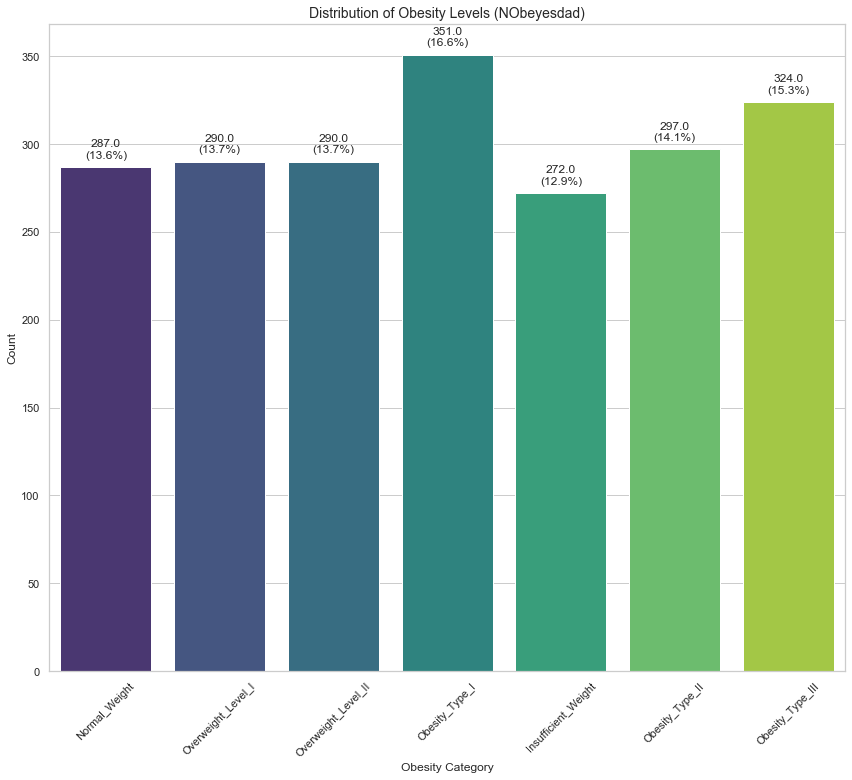

In [17]:
plt.figure(figsize=(12,11))
ax = sns.countplot(data=df_obesity, x=target_variable, palette="viridis")

plt.title("Distribution of Obesity Levels (NObeyesdad)", fontsize=14)
plt.xticks(rotation=45)
plt.xlabel("Obesity Category", fontsize=12)
plt.ylabel("Count",fontsize=12)

# Total rows for percentage calculation
total = len(df_obesity)

# Add count + percent labels on each bar
for p in ax.patches:
    height = p.get_height()
    percent = f'{100 * height / total:.1f}%'
    
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height + 5,
        f'{height}\n({percent})',
        ha='center', fontsize=12
    )

plt.tight_layout()
plt.show()

#### Step 4: Pie Chart

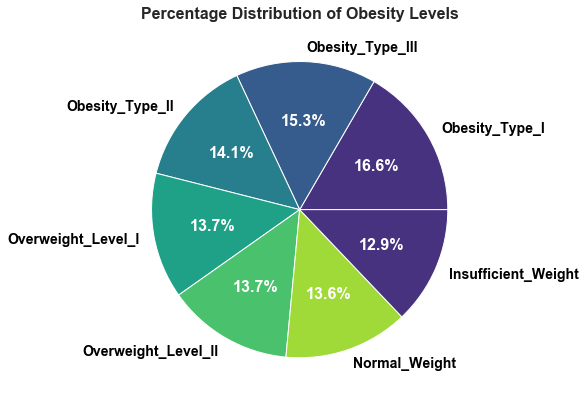

In [18]:
plt.figure(figsize=(8,8))

# Create the pie chart
patches, texts, autotexts = plt.pie(
    target_counts,
    labels=target_counts.index,      # outside labels
    autopct='%1.1f%%',               # inside percentage
    colors=sns.color_palette("viridis"),
    textprops={'weight': 'bold', 'fontsize': 14}  # default for OUTER labels
)

# Set OUTER label color to BLACK
for text in texts:
    text.set_color("black")
    text.set_weight("bold")
    text.set_fontsize(14)

# Set INNER percentage label color to WHITE
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_weight("bold")
    autotext.set_fontsize(16)

plt.title("Percentage Distribution of Obesity Levels", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### INSIGHTS FROM THE ANALYSIS OF THE TARGET VARIABLE



*The target variable NObeyesdad is evenly distributed across all seven obesity categories. Each class represents between 12.88% and 16.63% of the data, indicating no significant class imbalance. This balanced distribution ensures that machine learning models can be trained effectively without requiring resampling or class-weight adjustments. The dataset provides comprehensive coverage of all obesity severity levels, enabling robust multi-class classification analysis.*




### EDA PART-1 : EDA of INDIVIDUAL NUMERICAL COLUMNS

In [19]:
print(numerical_columns)

['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']




 Analyzing Numerical Column: Age


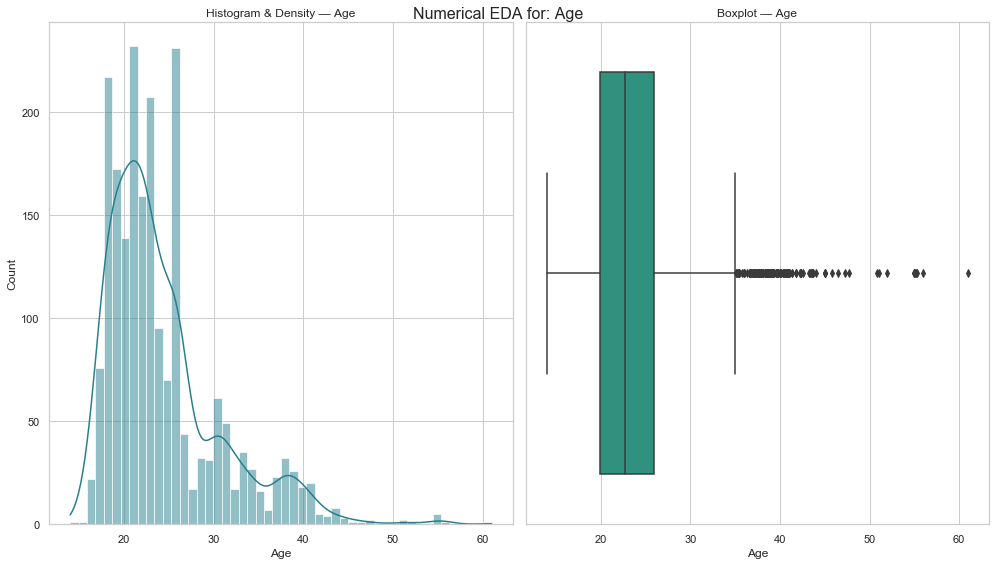


Summary statistics for: Age
count    2111.000000
mean       24.312600
std         6.345968
min        14.000000
25%        19.947192
50%        22.777890
75%        26.000000
max        61.000000
Name: Age, dtype: float64


 Analyzing Numerical Column: Height


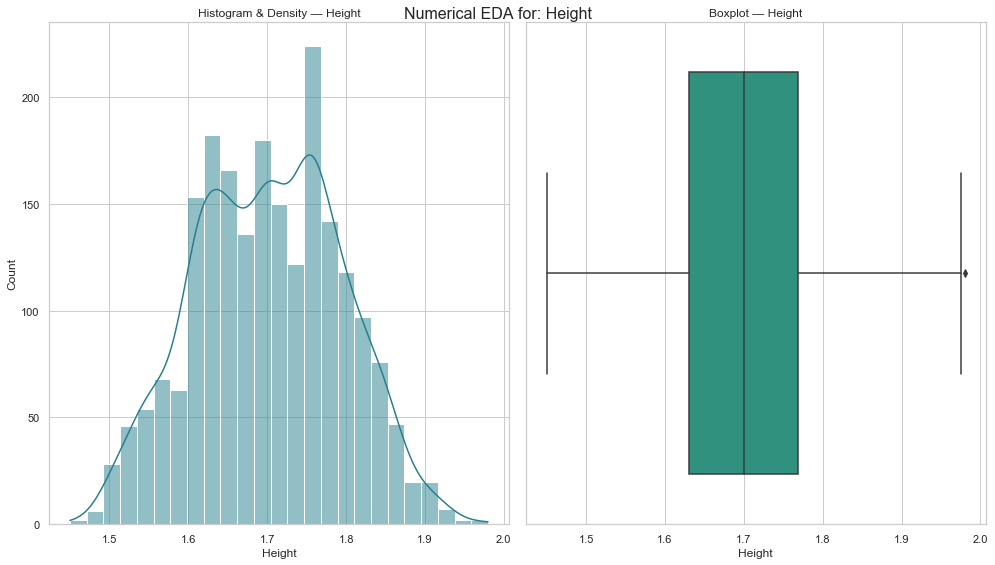


Summary statistics for: Height
count    2111.000000
mean        1.701677
std         0.093305
min         1.450000
25%         1.630000
50%         1.700499
75%         1.768464
max         1.980000
Name: Height, dtype: float64


 Analyzing Numerical Column: Weight


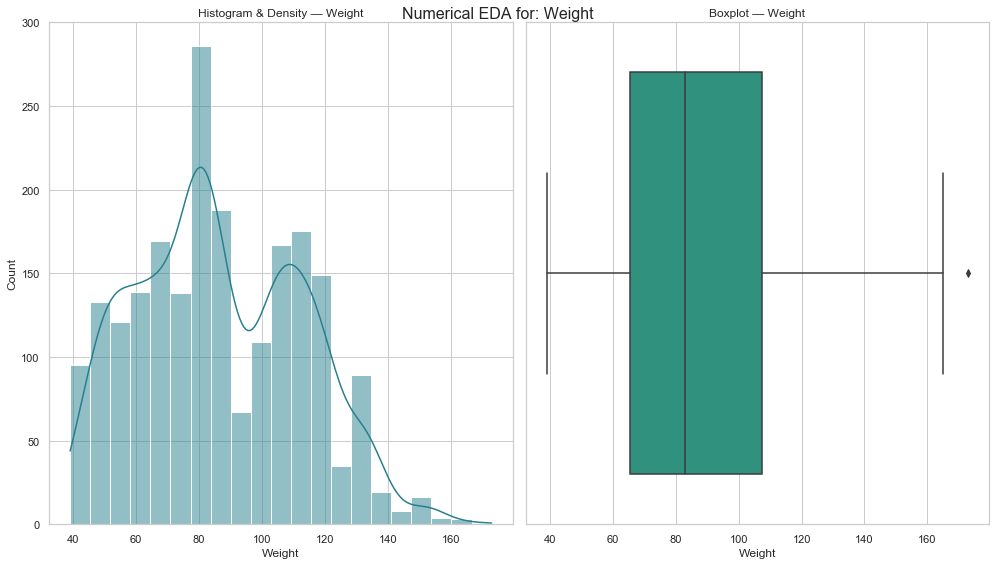


Summary statistics for: Weight
count    2111.000000
mean       86.586058
std        26.191172
min        39.000000
25%        65.473343
50%        83.000000
75%       107.430682
max       173.000000
Name: Weight, dtype: float64


 Analyzing Numerical Column: FCVC


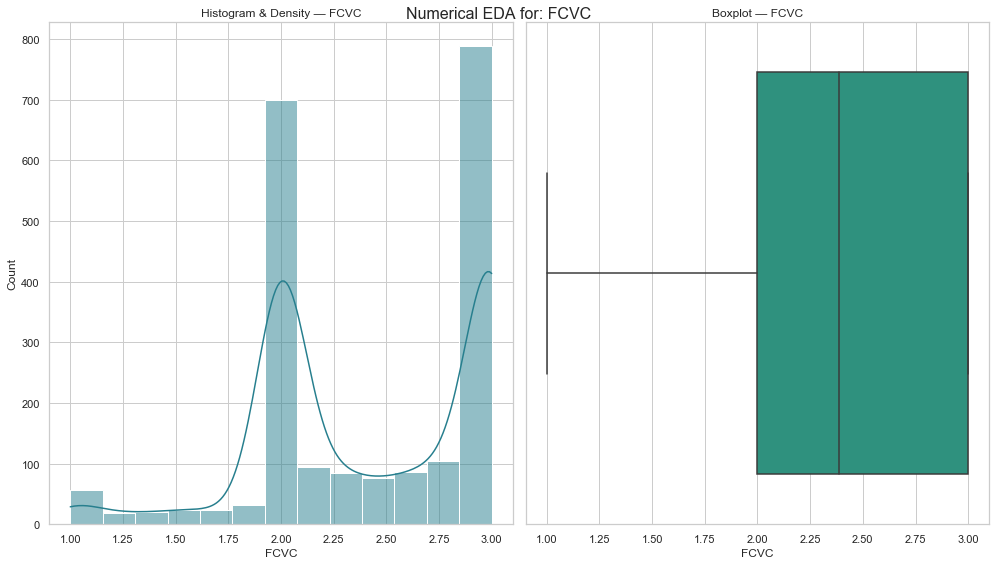


Summary statistics for: FCVC
count    2111.000000
mean        2.419043
std         0.533927
min         1.000000
25%         2.000000
50%         2.385502
75%         3.000000
max         3.000000
Name: FCVC, dtype: float64


 Analyzing Numerical Column: NCP


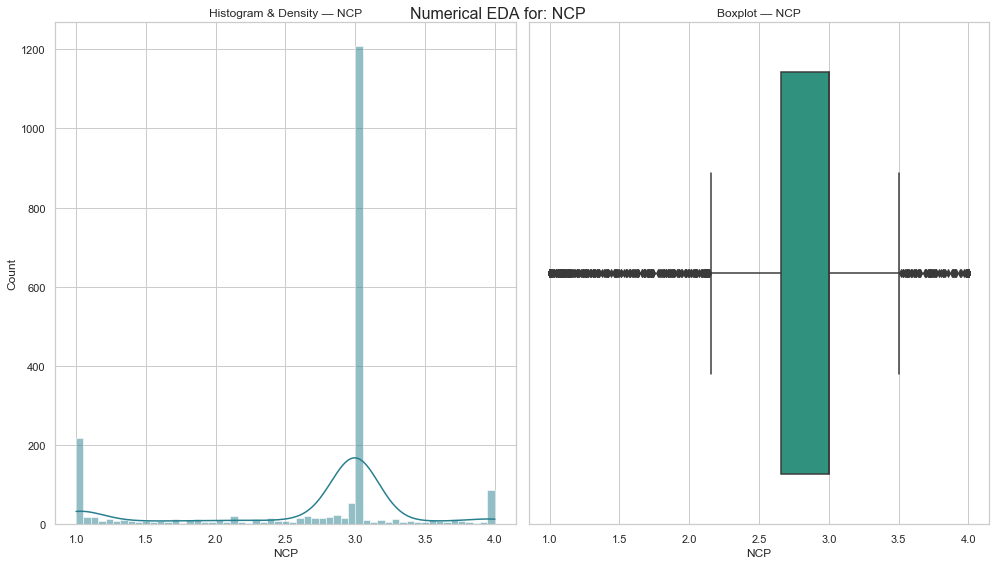


Summary statistics for: NCP
count    2111.000000
mean        2.685628
std         0.778039
min         1.000000
25%         2.658738
50%         3.000000
75%         3.000000
max         4.000000
Name: NCP, dtype: float64


 Analyzing Numerical Column: CH2O


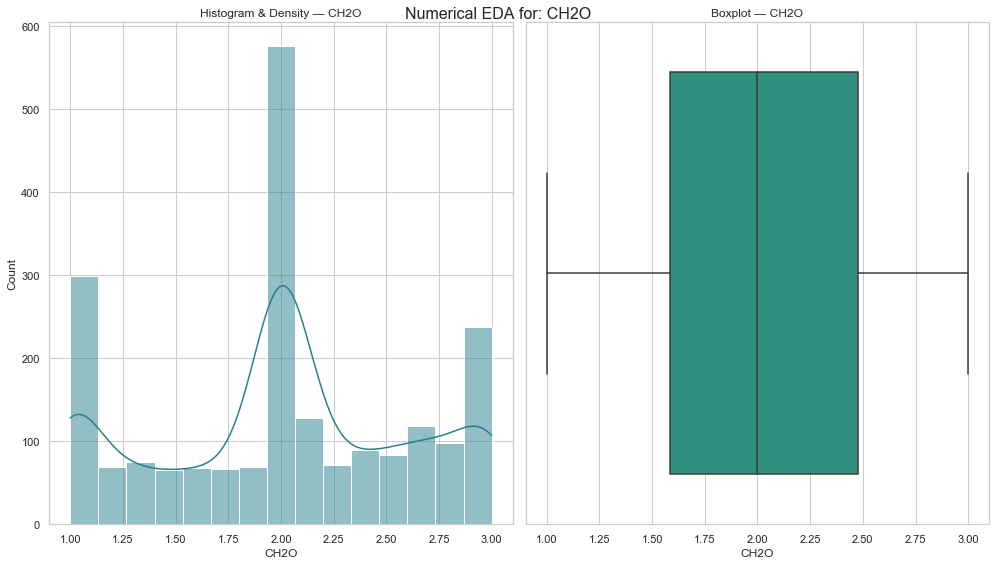


Summary statistics for: CH2O
count    2111.000000
mean        2.008011
std         0.612953
min         1.000000
25%         1.584812
50%         2.000000
75%         2.477420
max         3.000000
Name: CH2O, dtype: float64


 Analyzing Numerical Column: FAF


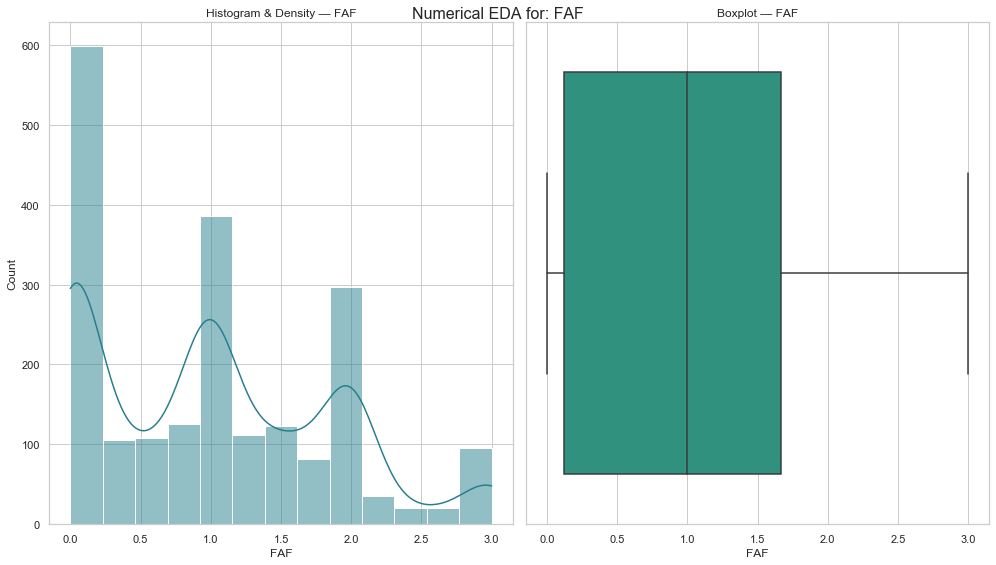


Summary statistics for: FAF
count    2111.000000
mean        1.010298
std         0.850592
min         0.000000
25%         0.124505
50%         1.000000
75%         1.666678
max         3.000000
Name: FAF, dtype: float64


 Analyzing Numerical Column: TUE


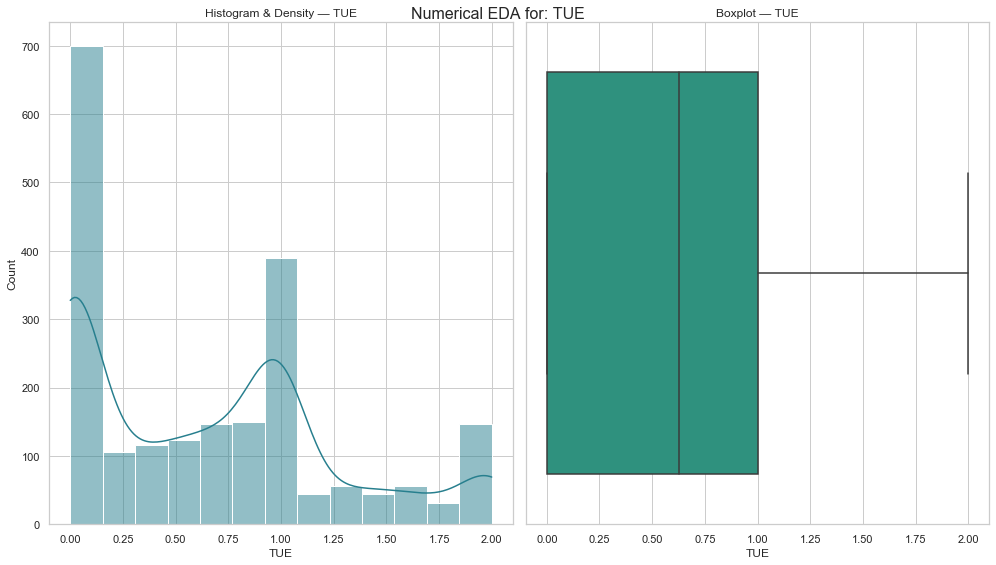


Summary statistics for: TUE
count    2111.000000
mean        0.657866
std         0.608927
min         0.000000
25%         0.000000
50%         0.625350
75%         1.000000
max         2.000000
Name: TUE, dtype: float64


In [20]:
plot_all_numerical(df_obesity,numerical_columns)

### EDA PART-2 : EDA of ONE NUMERICAL COLUMN vs OTHER NUMERICAL COLUMNS

In [21]:
print(numerical_columns)

['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


#### Lets Automate the process by plotting scatter plots against all the columns.

Automating all pairwise scatter plots for the 8 numerical columns will give you all 28 combinations (8C2) without manually specifying each pair.



#### Scatter Plot Function (Viridis + Regression Line)

In [22]:
def plot_scatter(df, x_col, y_col, palette="magma"):
    """
    Scatter plot for two numerical columns with regression line.
    """
    # choose a mid viridis color
    color = sns.color_palette(palette, 8)[5]

    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df, x=x_col, y=y_col, color=color, alpha=0.7, s=40)

    # regression line
    sns.regplot(data=df, x=x_col, y=y_col, scatter=False, color="black", line_kws={"linewidth":1})

    plt.title(f"{x_col} vs {y_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

#### Generate All 8C2 Numerical Combinations Automatically

In [23]:
from itertools import combinations

num_pairs = list(combinations(numerical_columns, 2))
len(num_pairs), num_pairs


(28,
 [('Age', 'Height'),
  ('Age', 'Weight'),
  ('Age', 'FCVC'),
  ('Age', 'NCP'),
  ('Age', 'CH2O'),
  ('Age', 'FAF'),
  ('Age', 'TUE'),
  ('Height', 'Weight'),
  ('Height', 'FCVC'),
  ('Height', 'NCP'),
  ('Height', 'CH2O'),
  ('Height', 'FAF'),
  ('Height', 'TUE'),
  ('Weight', 'FCVC'),
  ('Weight', 'NCP'),
  ('Weight', 'CH2O'),
  ('Weight', 'FAF'),
  ('Weight', 'TUE'),
  ('FCVC', 'NCP'),
  ('FCVC', 'CH2O'),
  ('FCVC', 'FAF'),
  ('FCVC', 'TUE'),
  ('NCP', 'CH2O'),
  ('NCP', 'FAF'),
  ('NCP', 'TUE'),
  ('CH2O', 'FAF'),
  ('CH2O', 'TUE'),
  ('FAF', 'TUE')])

#### Plot All Scatter Plots in a Loop

In [24]:
def plot_all_scatter(df, numerical_cols, palette="ocean"):
    pairs = list(combinations(numerical_cols, 2))
    
    for x_col, y_col in pairs:
        print(f"\n=== Scatter Plot: {x_col} vs {y_col} ===")
        plot_scatter(df, x_col, y_col, palette=palette)

#### Run the full automated scatterplot EDA


=== Scatter Plot: Age vs Height ===


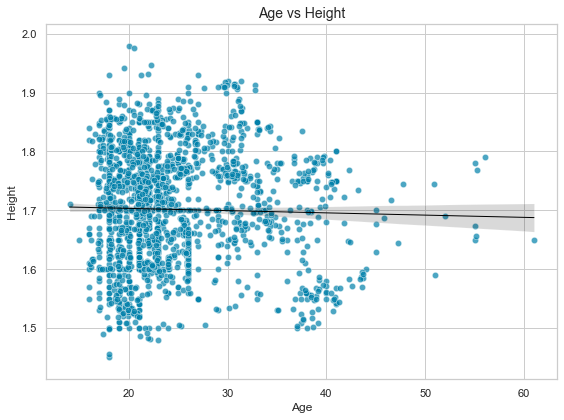


=== Scatter Plot: Age vs Weight ===


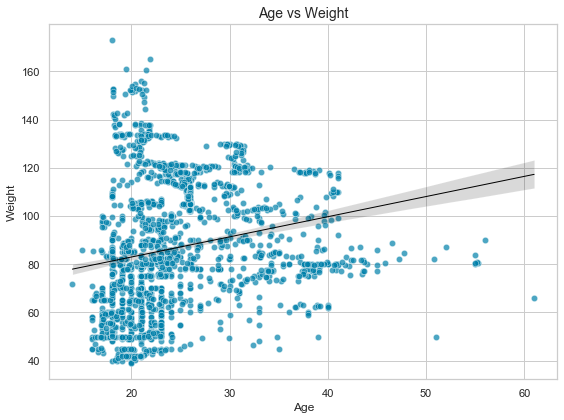


=== Scatter Plot: Age vs FCVC ===


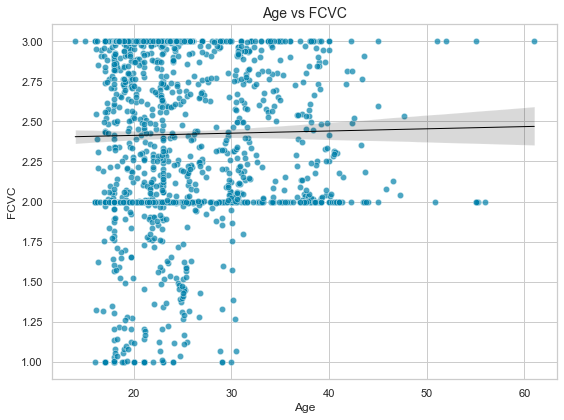


=== Scatter Plot: Age vs NCP ===


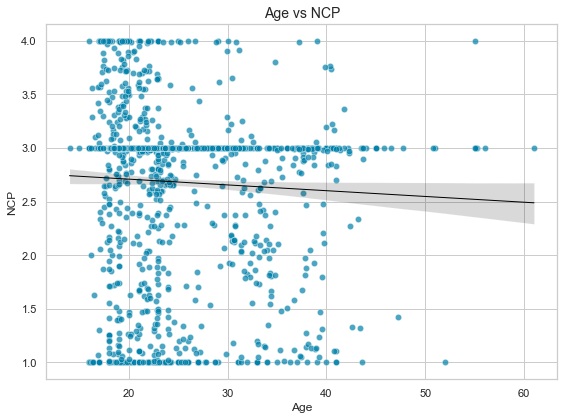


=== Scatter Plot: Age vs CH2O ===


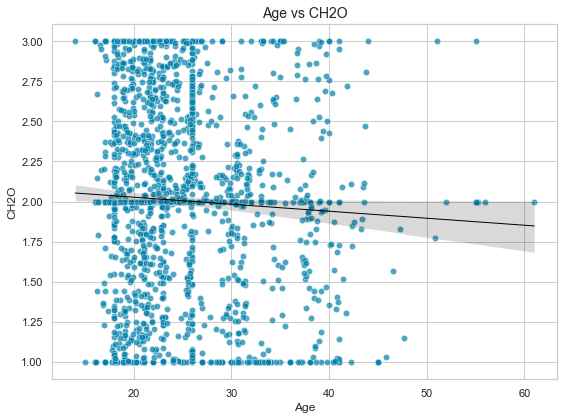


=== Scatter Plot: Age vs FAF ===


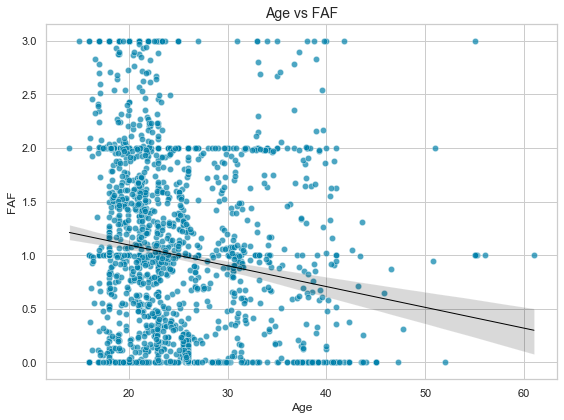


=== Scatter Plot: Age vs TUE ===


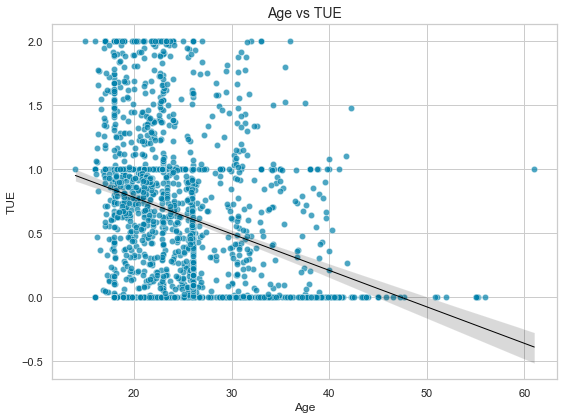


=== Scatter Plot: Height vs Weight ===


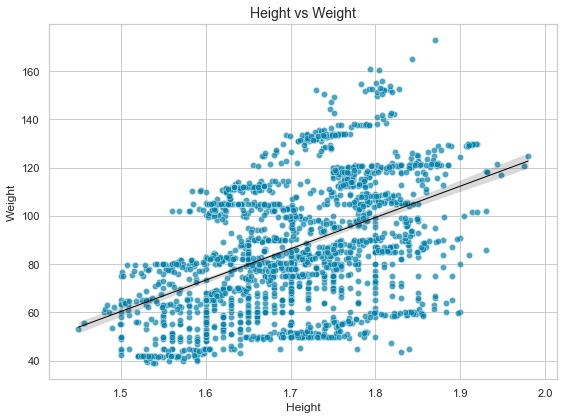


=== Scatter Plot: Height vs FCVC ===


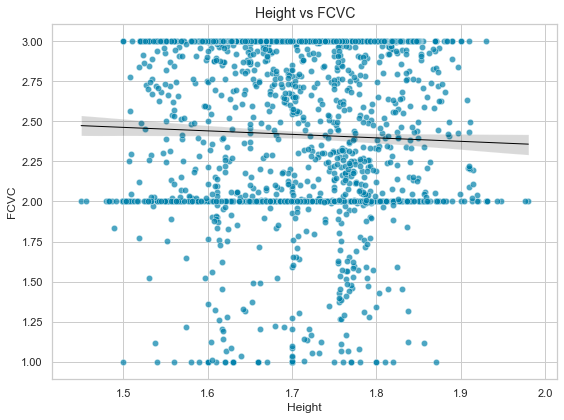


=== Scatter Plot: Height vs NCP ===


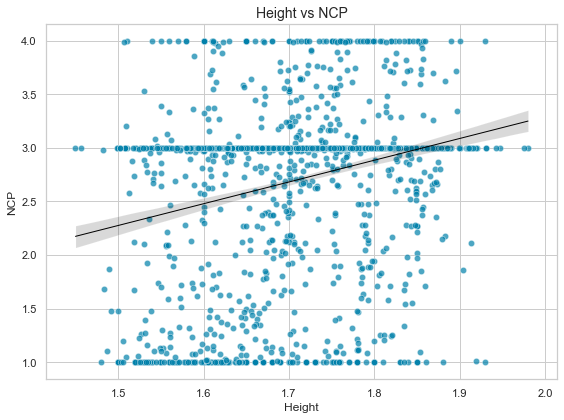


=== Scatter Plot: Height vs CH2O ===


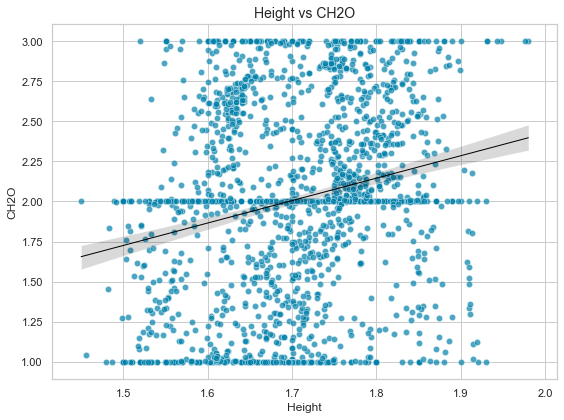


=== Scatter Plot: Height vs FAF ===


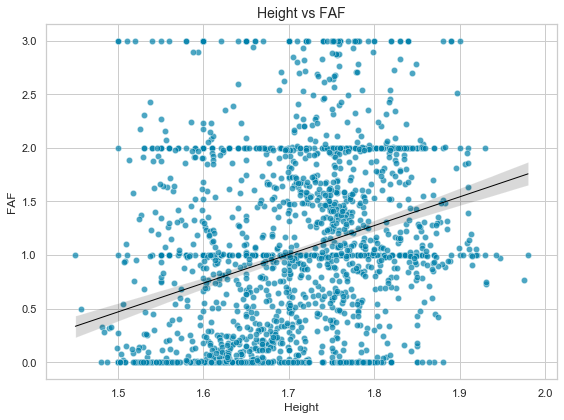


=== Scatter Plot: Height vs TUE ===


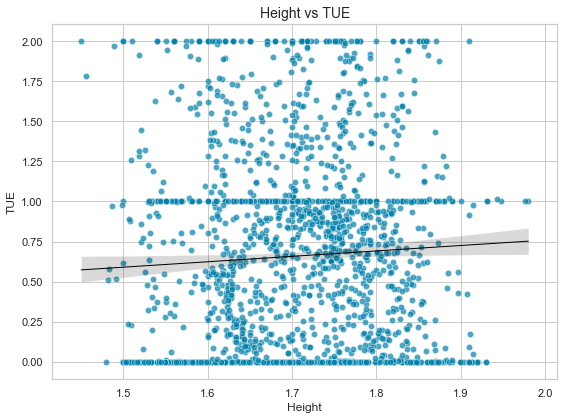


=== Scatter Plot: Weight vs FCVC ===


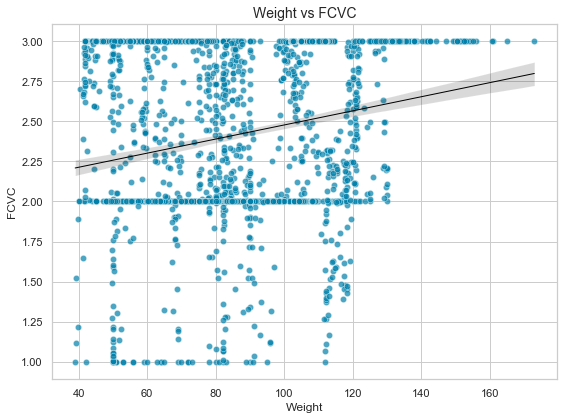


=== Scatter Plot: Weight vs NCP ===


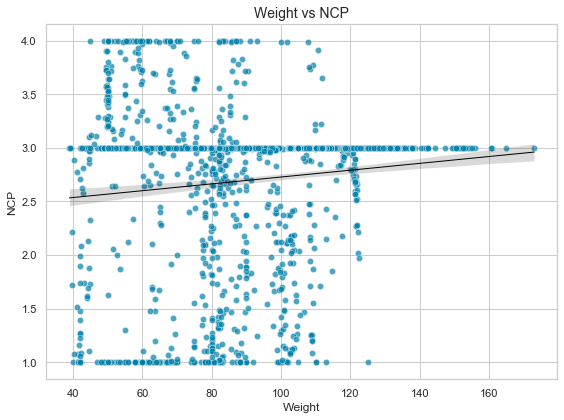


=== Scatter Plot: Weight vs CH2O ===


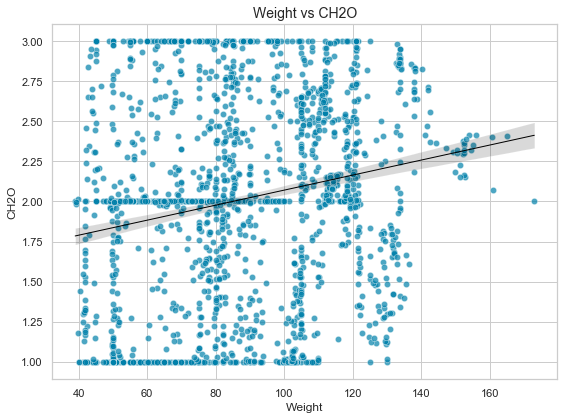


=== Scatter Plot: Weight vs FAF ===


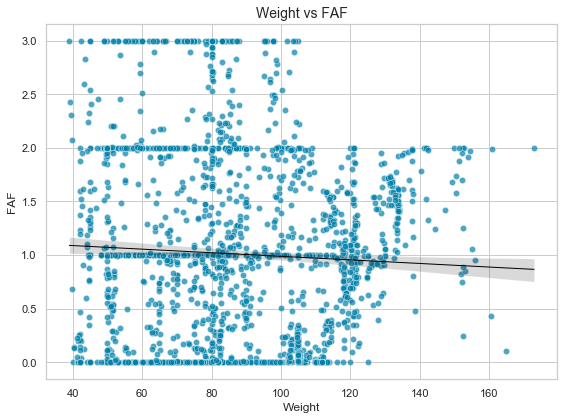


=== Scatter Plot: Weight vs TUE ===


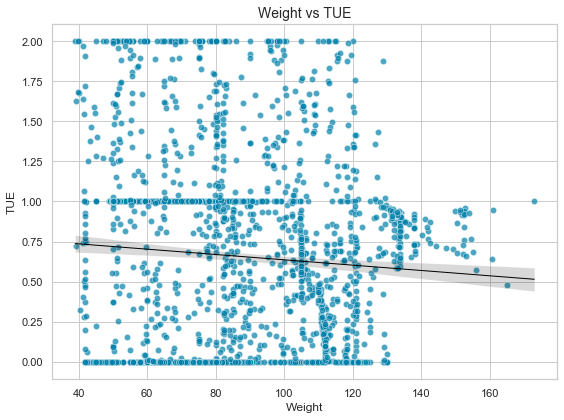


=== Scatter Plot: FCVC vs NCP ===


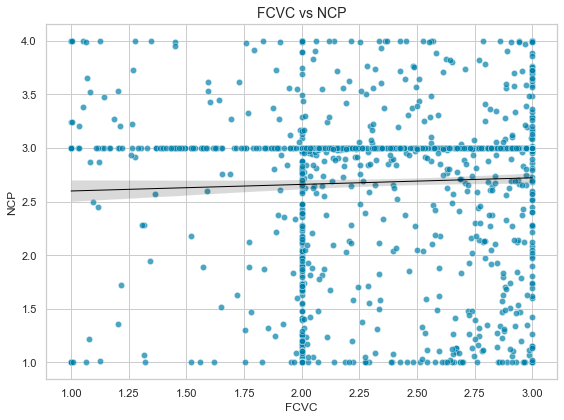


=== Scatter Plot: FCVC vs CH2O ===


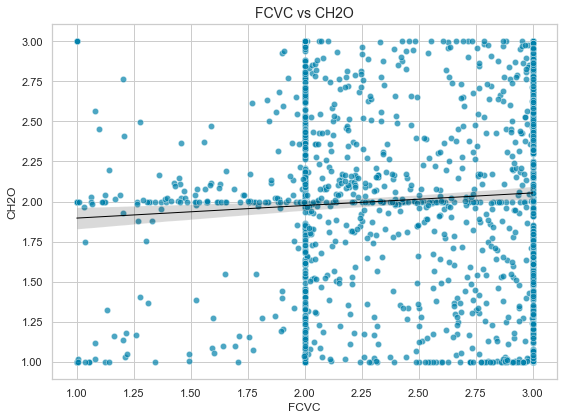


=== Scatter Plot: FCVC vs FAF ===


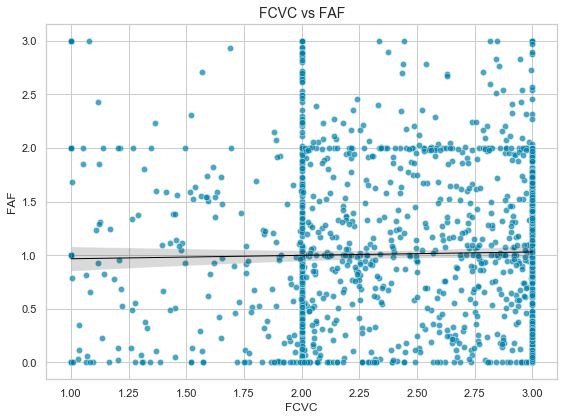


=== Scatter Plot: FCVC vs TUE ===


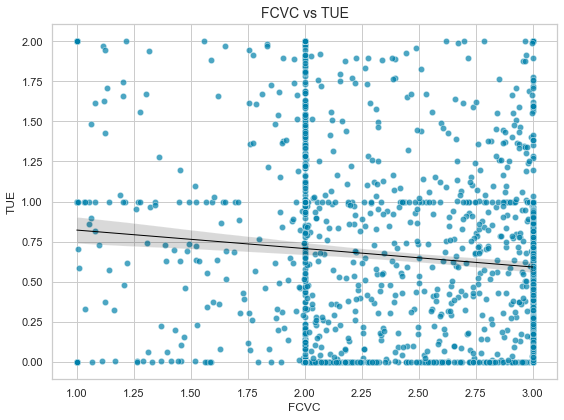


=== Scatter Plot: NCP vs CH2O ===


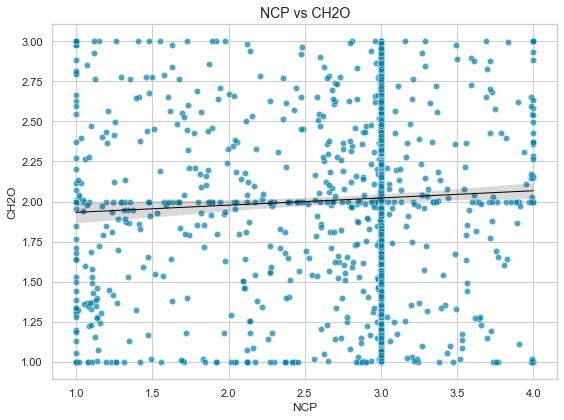


=== Scatter Plot: NCP vs FAF ===


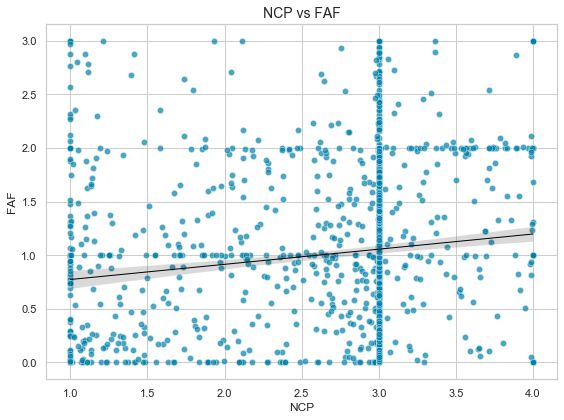


=== Scatter Plot: NCP vs TUE ===


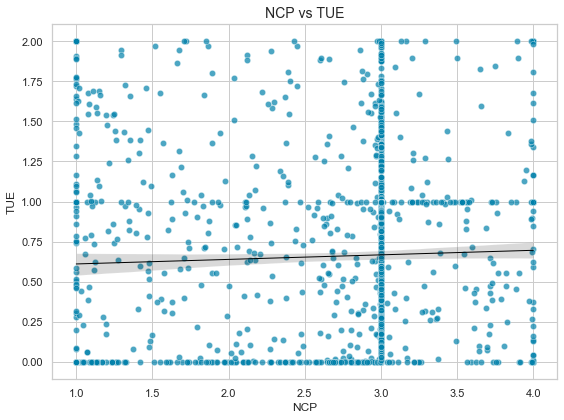


=== Scatter Plot: CH2O vs FAF ===


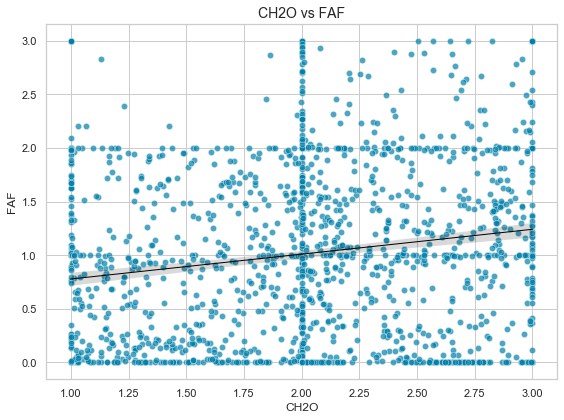


=== Scatter Plot: CH2O vs TUE ===


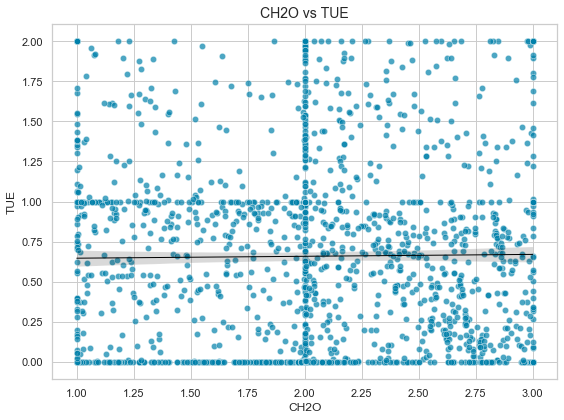


=== Scatter Plot: FAF vs TUE ===


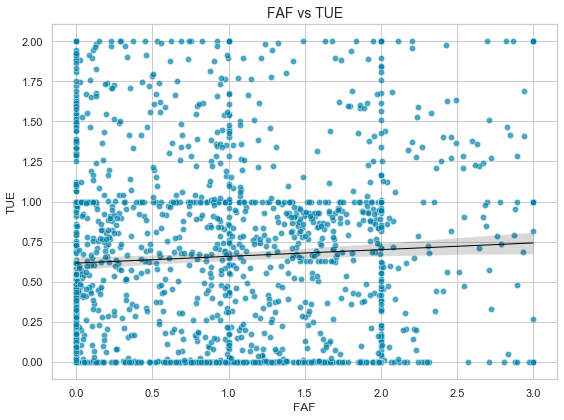

In [25]:
plot_all_scatter(df_obesity, numerical_columns)

#### Lets also Create a HEAT MAP

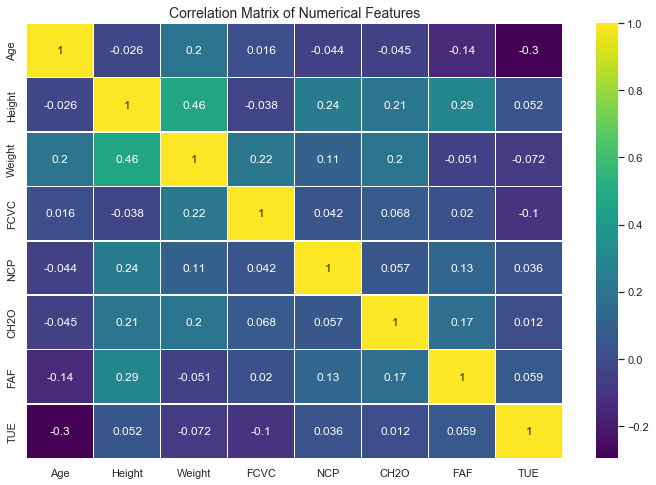

In [26]:
plt.figure(figsize=(12,8))
corr_matrix = df_obesity[numerical_columns].corr()

sns.heatmap(corr_matrix, annot=True, cmap="viridis", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.show()

Interpretation of the Correlation Matrix for Numerical Features

The correlation matrix shows the strength and direction of linear relationships between the numerical variables: Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE.

1. Relationship between Height and Weight

Height and Weight have the strongest positive correlation in the matrix: 0.46.

This means that as height increases, weight tends to increase as well, which is biologically expected.

Since 0.46 is a moderate rather than very high correlation, it indicates that height explains some, but not all, of the variation in weight. Other factors (diet, activity, lifestyle) also play an important role.

2. Age and its relationships with other variables

Age has a weak positive correlation with Weight: 0.20.

Age and Height have essentially no linear relationship: –0.03 (approximately zero).

Age is weakly negatively correlated with physical activity (FAF): –0.14.

Age has a more noticeable negative correlation with time using electronic devices (TUE): –0.30.

Overall, these values show that Age is only weakly related to the other numerical variables. This is likely because the dataset is dominated by younger individuals, which reduces variation in Age and makes strong correlations less likely.

3. Physical activity (FAF) and its relationships

FAF and Height: 0.29 (weak positive correlation).

FAF and CH2O (water intake): 0.17 (weak positive correlation).

FAF and Weight: –0.05 (very weak negative correlation).

These values indicate that more physically active individuals tend to be slightly taller and drink a bit more water, but physical activity does not have a strong direct linear relationship with weight in this dataset.

4. Dietary behavior and weight

Weight and FCVC (vegetable consumption): 0.22 (weak positive correlation).

Weight and CH2O (water intake): 0.20 (weak positive correlation).

Weight and NCP (number of main meals): 0.11 (very weak positive correlation).

These weak correlations suggest that, taken individually, these dietary behaviors do not have a strong linear association with weight. Weight differences are likely driven by a combination of multiple behaviors and factors rather than a single numeric habit.

5. Time using electronic devices (TUE)

TUE and Age: –0.30 (moderate negative correlation).

TUE and Weight: –0.07 (very weak negative correlation).

TUE and FAF: 0.06 (very weak positive correlation).

The main pattern here is that younger participants tend to spend more time using electronic devices, as shown by the –0.30 correlation with Age. TUE has little direct linear relationship with other numeric variables.

6. Independence among most numerical features

Many other pairwise correlations are close to zero. For example:

Age with CH2O: –0.05

Age with NCP: –0.04

FCVC with NCP: 0.04

FCVC with FAF: 0.02

NCP with CH2O: 0.06

NCP with FAF: 0.13

These values indicate that most numerical features vary largely independently of one another and do not have strong linear relationships.

7. No multicollinearity concerns

None of the correlations between different features (excluding the diagonal of 1.00) are close to 0.80 or higher.

The highest is Height with Weight at 0.46, which is moderate.

This means there is no serious multicollinearity among the numerical predictors. All numerical features can be used together in linear models (like logistic regression) and tree-based models without causing instability due to redundant information.

Summary

The numerical features in this dataset are mostly weakly correlated with each other, with the main notable relationship being a moderate positive correlation between Height and Weight (0.46). Age has generally weak relationships with most variables, except for a moderate negative correlation with time using electronic devices (TUE: –0.30). Lifestyle-related variables such as physical activity, number of meals, vegetable consumption, and water intake show only weak linear correlations with weight and with each other. Overall, this suggests that each numerical feature brings relatively distinct information to the modeling process, and there are no multicollinearity issues among them.

#### Lets also create a PAIR PLOT for all the numerical columns

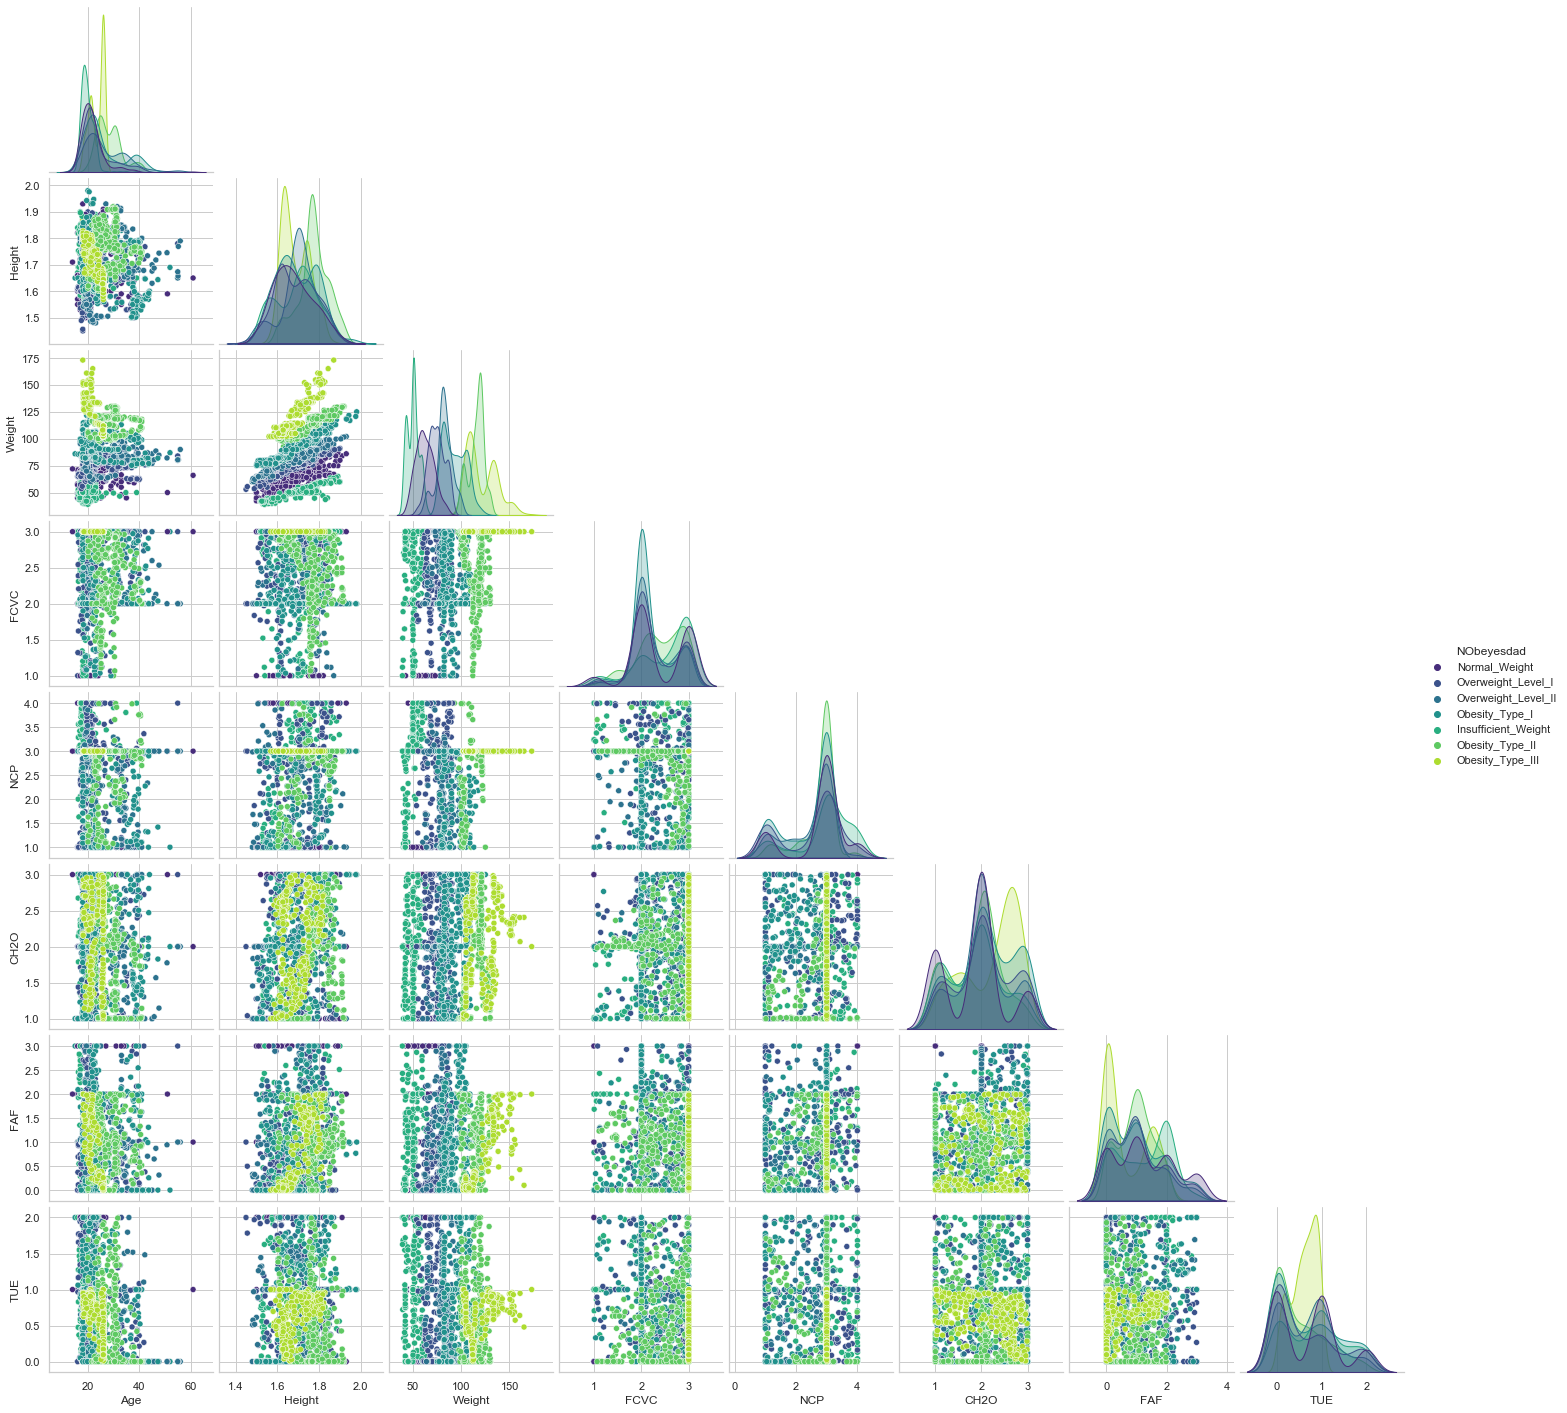

In [27]:
sns.pairplot( df_obesity, vars=numerical_columns, hue=target_variable, corner=True, diag_kind="kde",palette="viridis")
plt.show()

### EDA PART-2 : EDA of INDIVIDUAL CATEGORICAL COLUMNS

In [28]:
print(categorical_columns)

['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']




 Analyzing Categorical Column: Gender


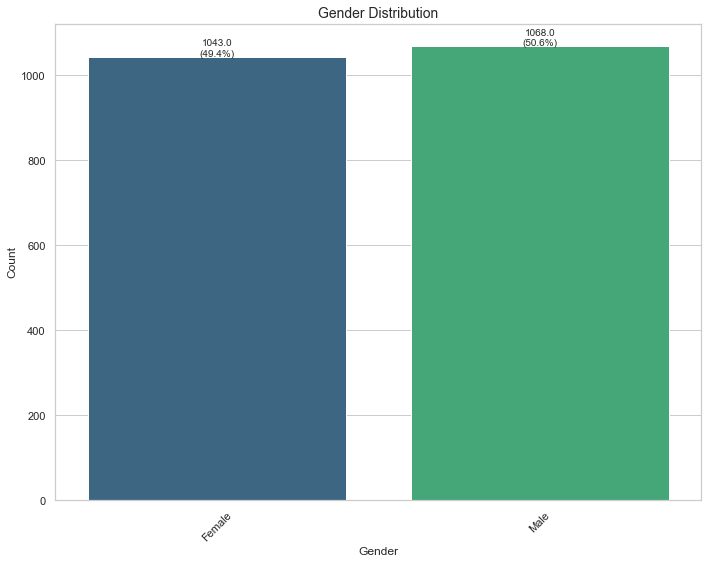

Counts:
 Male      1068
Female    1043
Name: Gender, dtype: int64

Percentages (%):
 Male      50.59
Female    49.41
Name: Gender, dtype: float64


 Analyzing Categorical Column: family_history_with_overweight


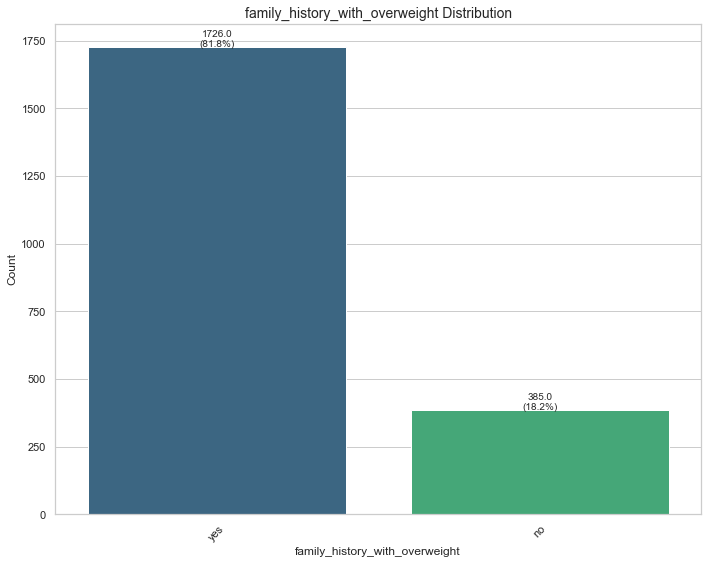

Counts:
 yes    1726
no      385
Name: family_history_with_overweight, dtype: int64

Percentages (%):
 yes    81.76
no     18.24
Name: family_history_with_overweight, dtype: float64


 Analyzing Categorical Column: FAVC


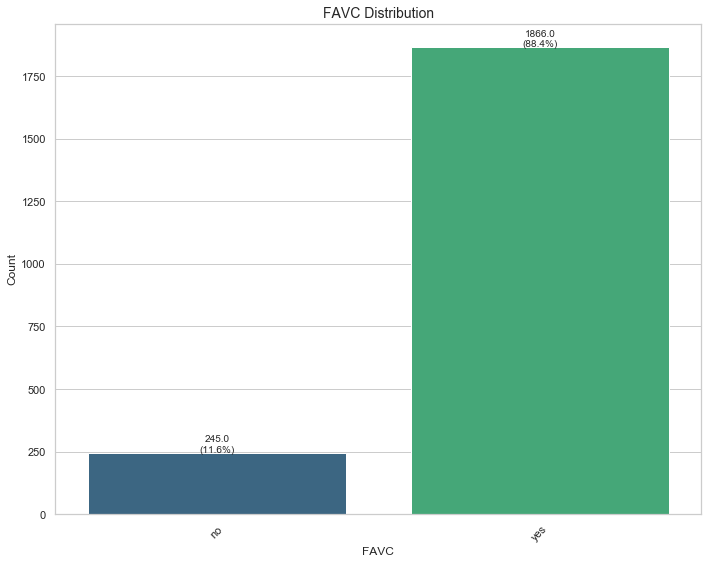

Counts:
 yes    1866
no      245
Name: FAVC, dtype: int64

Percentages (%):
 yes    88.39
no     11.61
Name: FAVC, dtype: float64


 Analyzing Categorical Column: CAEC


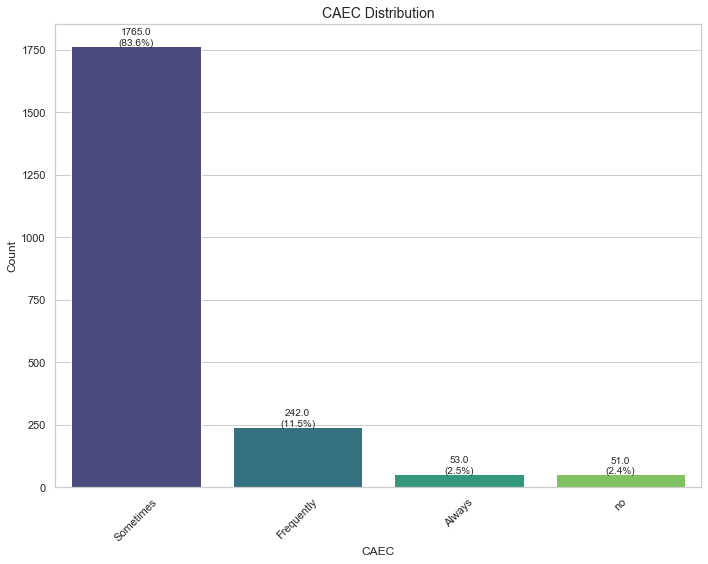

Counts:
 Sometimes     1765
Frequently     242
Always          53
no              51
Name: CAEC, dtype: int64

Percentages (%):
 Sometimes     83.61
Frequently    11.46
Always         2.51
no             2.42
Name: CAEC, dtype: float64


 Analyzing Categorical Column: SMOKE


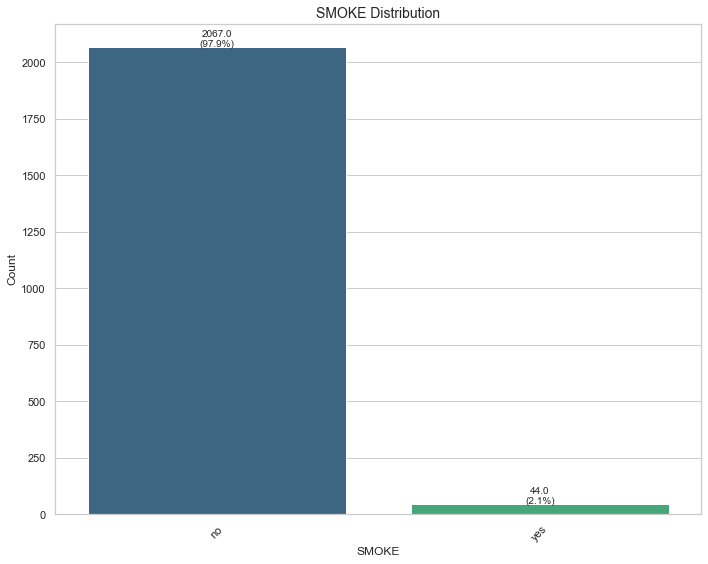

Counts:
 no     2067
yes      44
Name: SMOKE, dtype: int64

Percentages (%):
 no     97.92
yes     2.08
Name: SMOKE, dtype: float64


 Analyzing Categorical Column: SCC


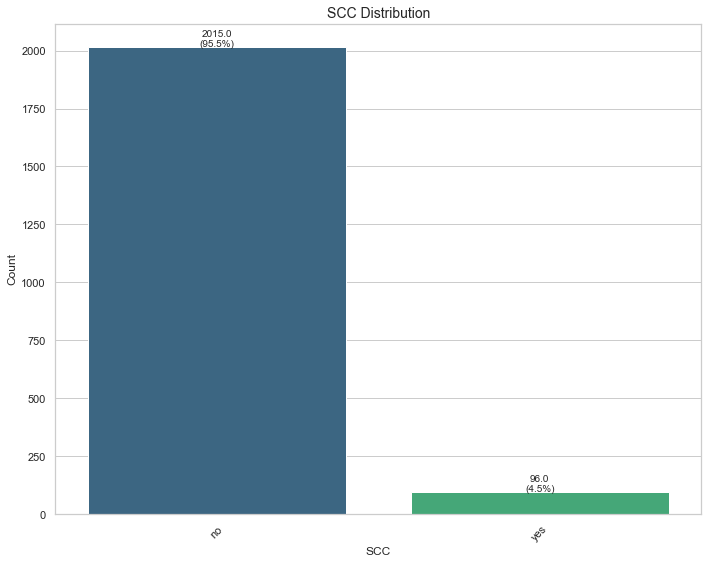

Counts:
 no     2015
yes      96
Name: SCC, dtype: int64

Percentages (%):
 no     95.45
yes     4.55
Name: SCC, dtype: float64


 Analyzing Categorical Column: CALC


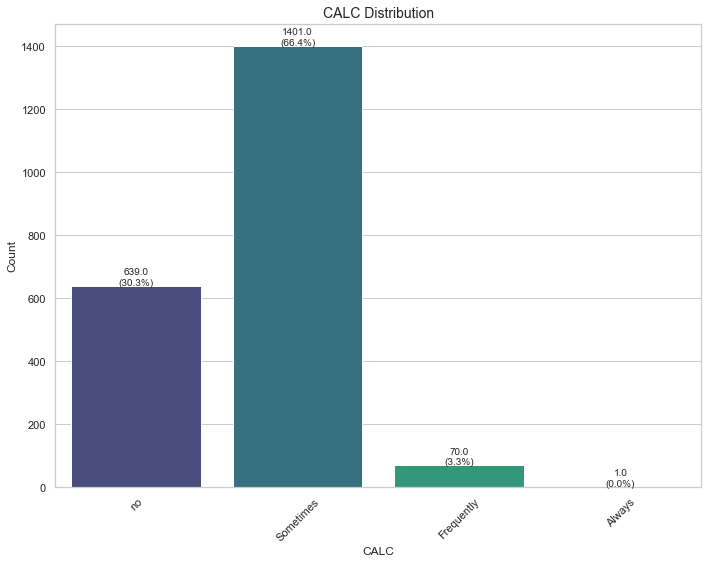

Counts:
 Sometimes     1401
no             639
Frequently      70
Always           1
Name: CALC, dtype: int64

Percentages (%):
 Sometimes     66.37
no            30.27
Frequently     3.32
Always         0.05
Name: CALC, dtype: float64


 Analyzing Categorical Column: MTRANS


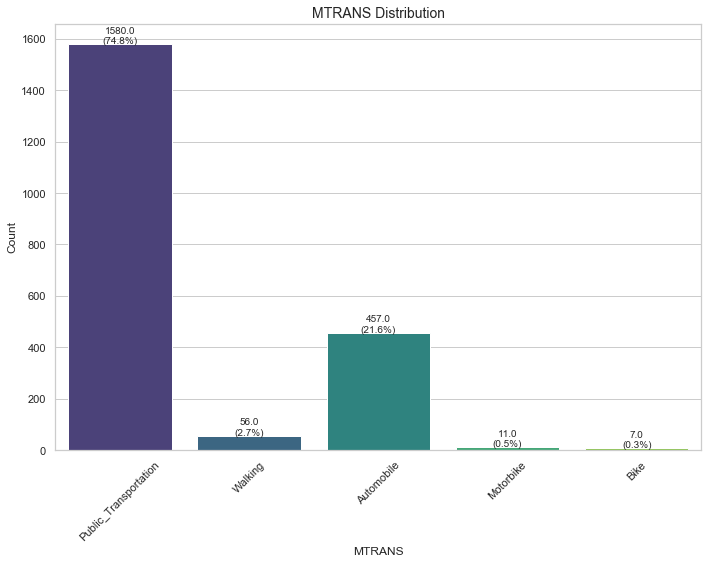

Counts:
 Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: MTRANS, dtype: int64

Percentages (%):
 Public_Transportation    74.85
Automobile               21.65
Walking                   2.65
Motorbike                 0.52
Bike                      0.33
Name: MTRANS, dtype: float64


In [29]:
plot_all_categorical(df_obesity,categorical_columns)

#### Reusable Function for Numerical vs Categorical Variables


In [30]:
def boxplot_num_vs_cat(df, num_col, cat_col, palette="viridis"):
    """
    Creates a boxplot comparing a numerical column across categories of a categorical column.
    """
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df, x=cat_col, y=num_col, palette=palette)
    plt.xticks(rotation=45)
    plt.title(f"{num_col} vs {cat_col}", fontsize=14)
    plt.tight_layout()
    plt.show()

#### Reusable Function to Automate All Comparisons

In [31]:
## This function loops through every categorical column and generates boxplots for all numerical columns.


def boxplot_all_num_vs_cat(df, numerical_cols, categorical_cols, palette="viridis"):
    for cat in categorical_cols:
        print(f"\n\n====== {cat}: Numerical Comparison ======\n")
        for num in numerical_cols:
            boxplot_num_vs_cat(df, num, cat, palette=palette)
            
            



====== Gender: Numerical Comparison ======



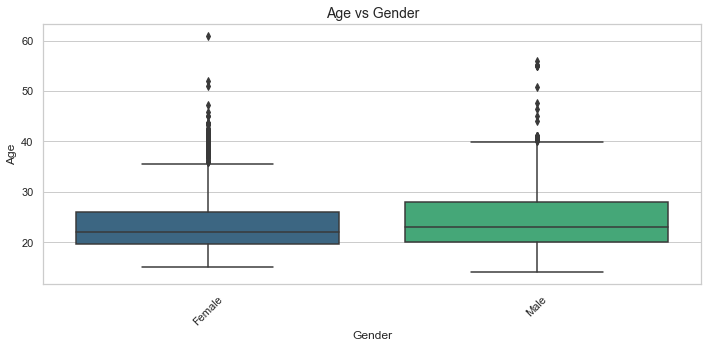

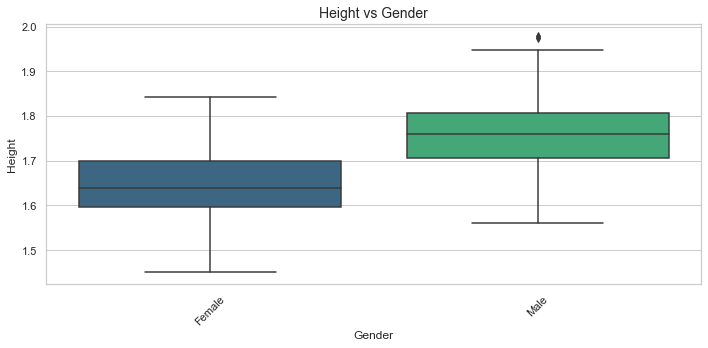

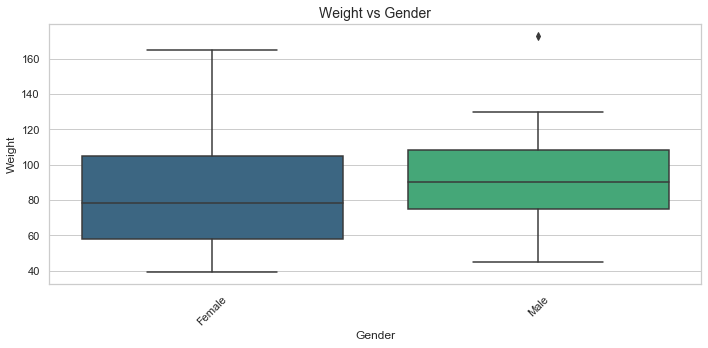

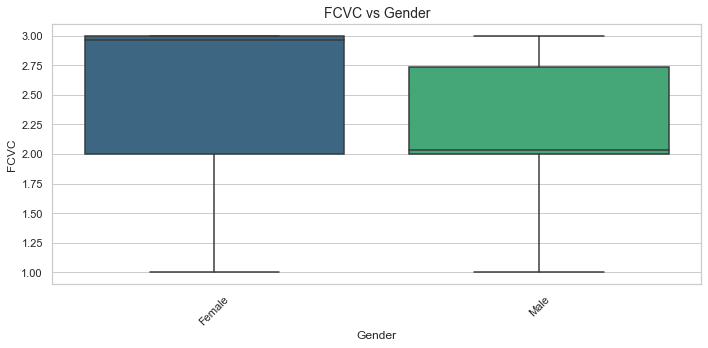

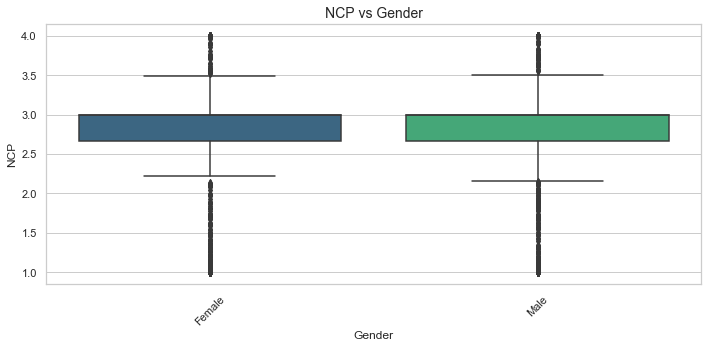

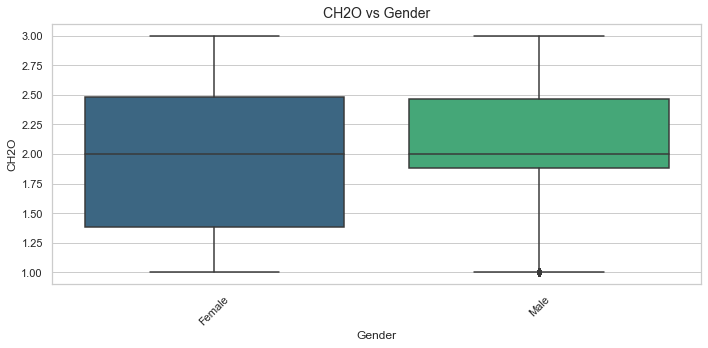

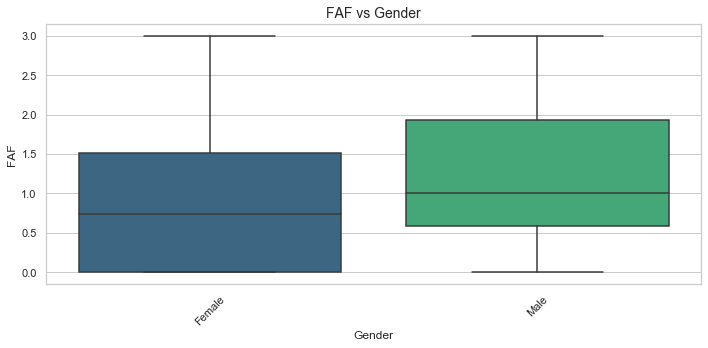

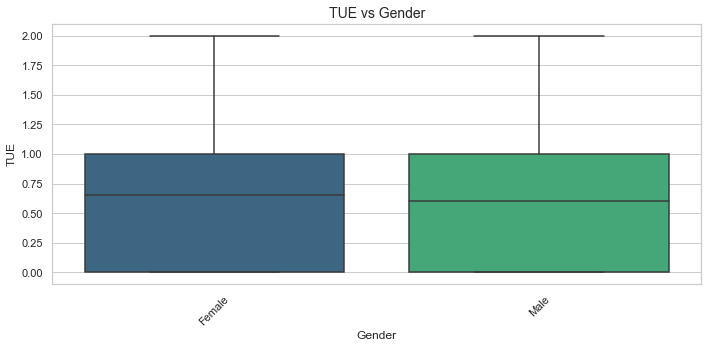



====== family_history_with_overweight: Numerical Comparison ======



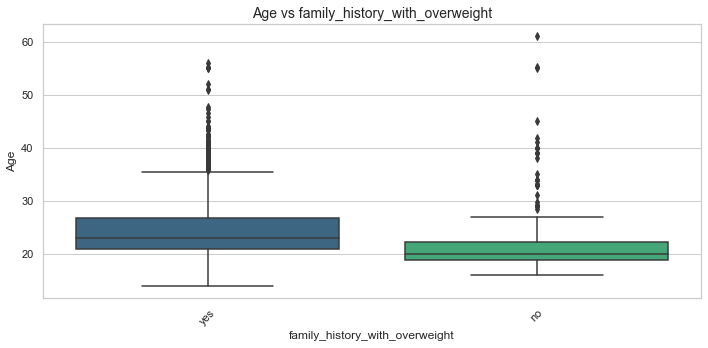

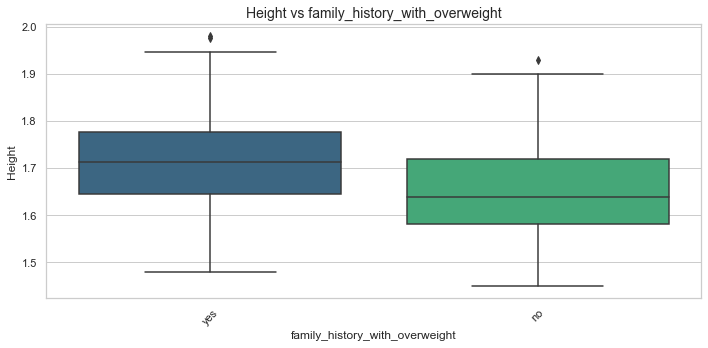

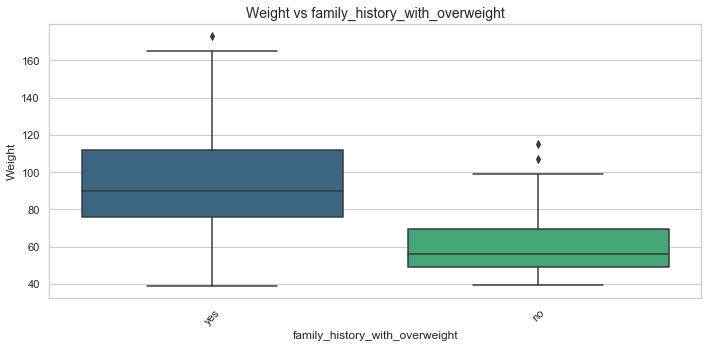

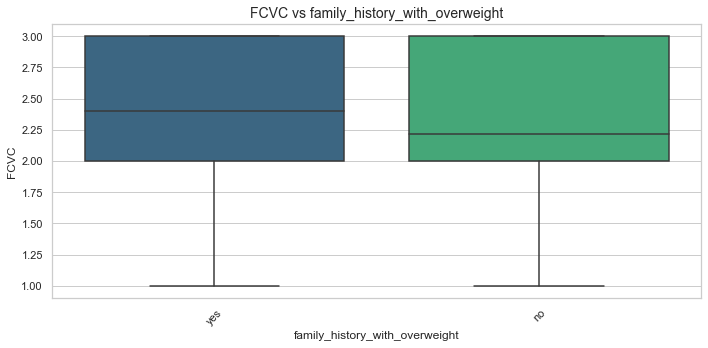

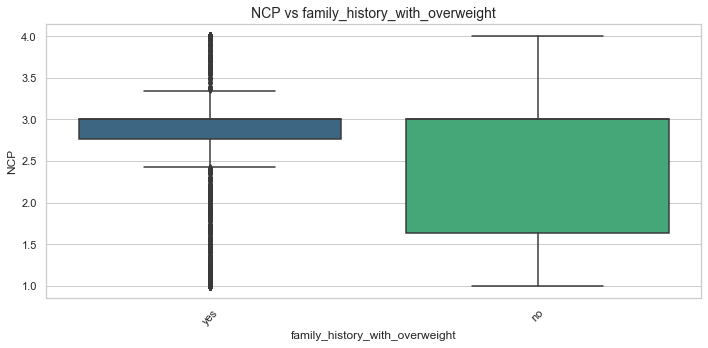

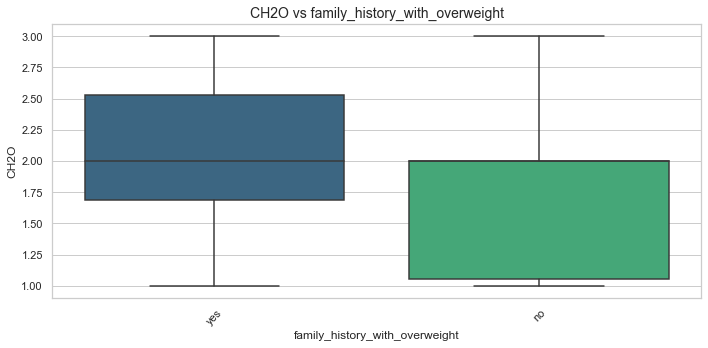

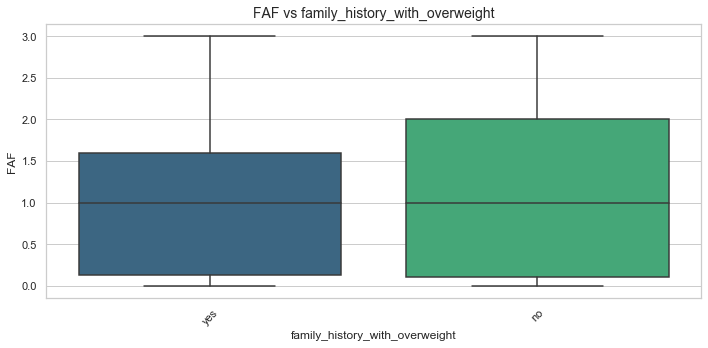

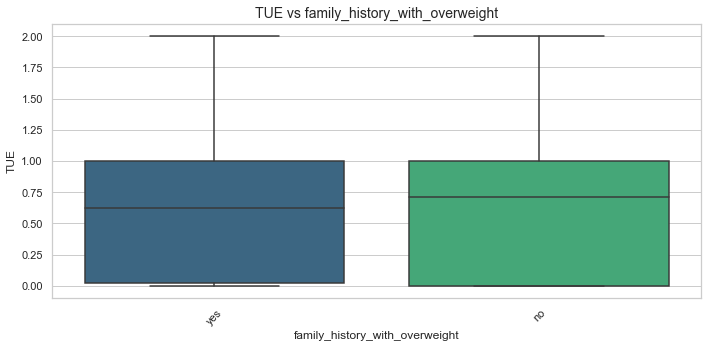



====== FAVC: Numerical Comparison ======



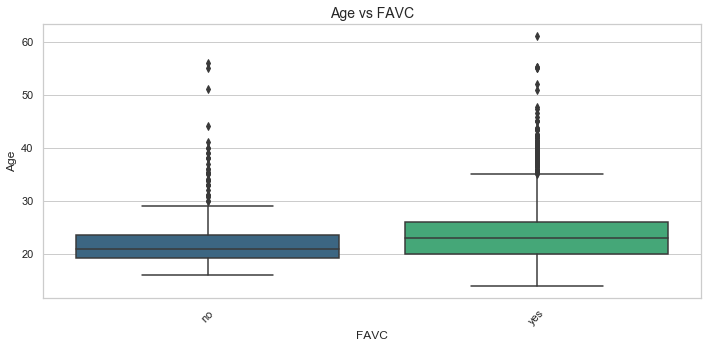

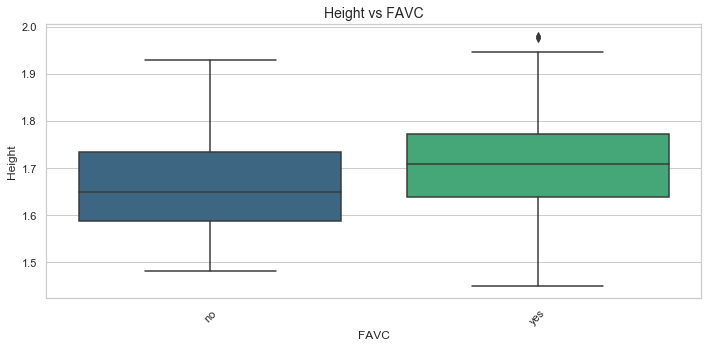

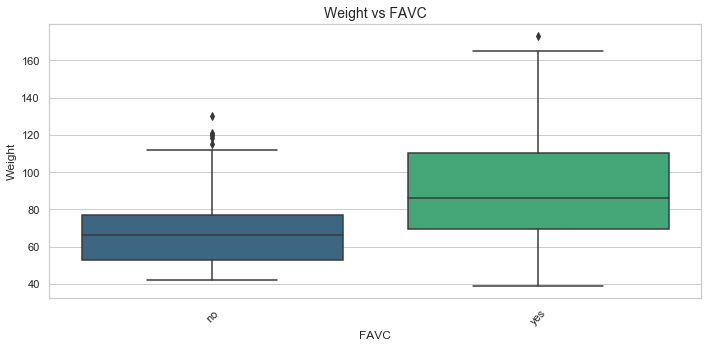

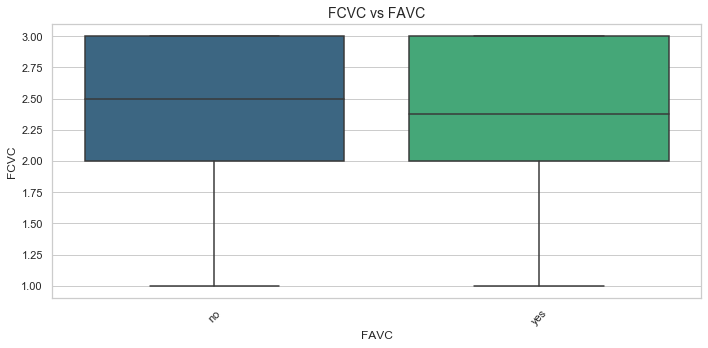

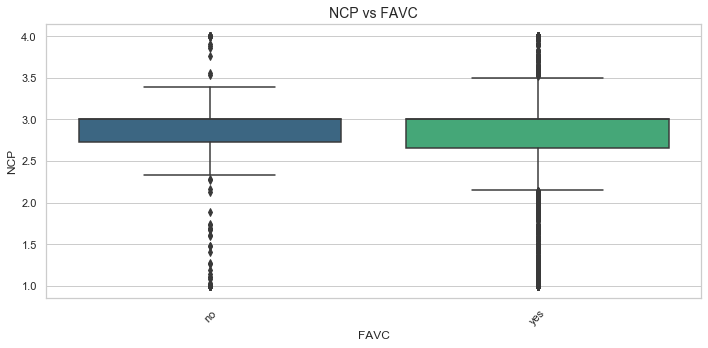

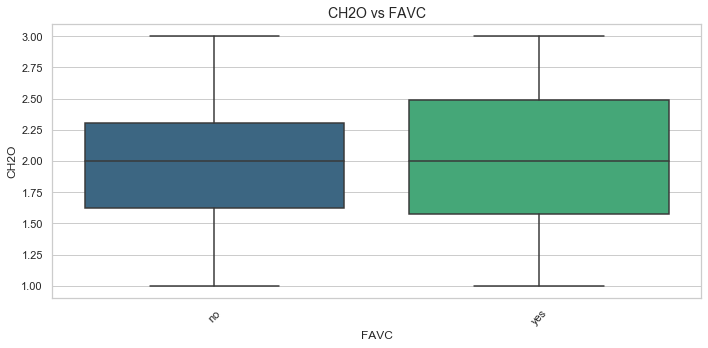

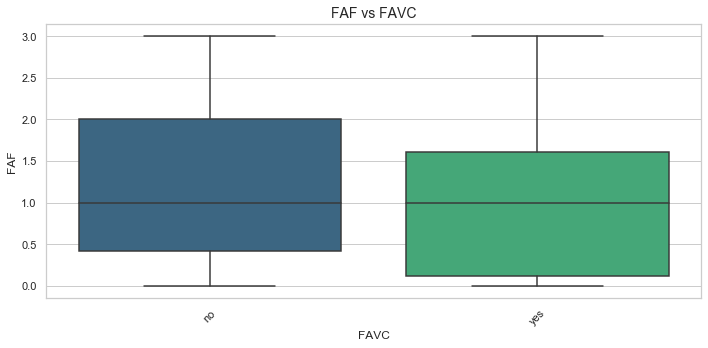

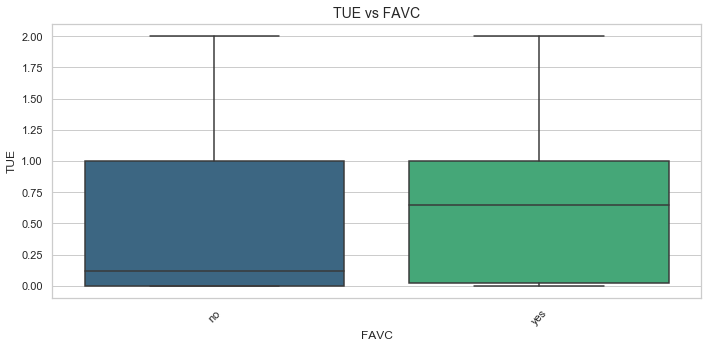



====== CAEC: Numerical Comparison ======



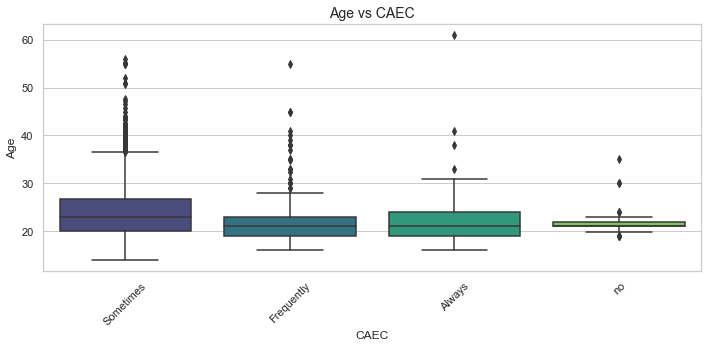

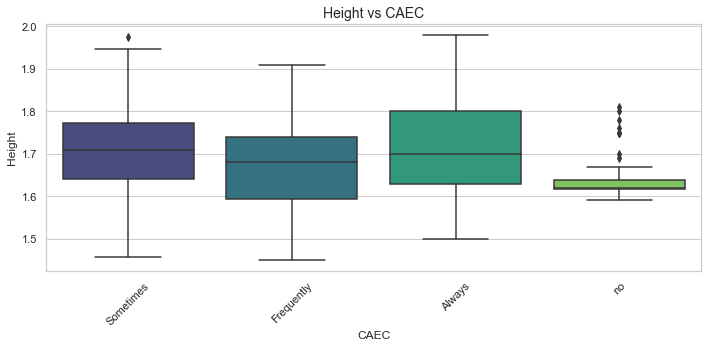

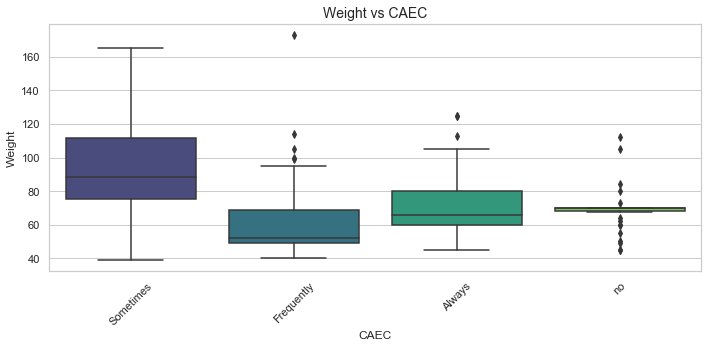

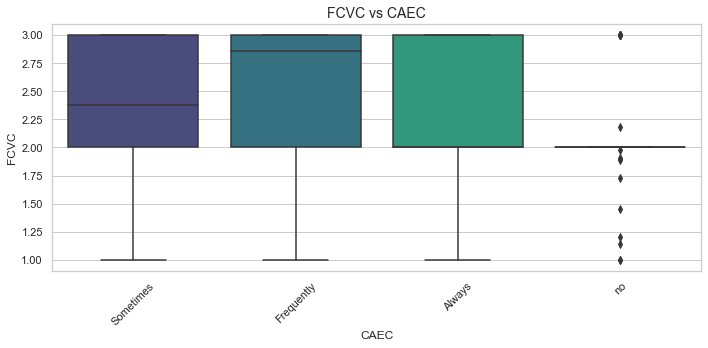

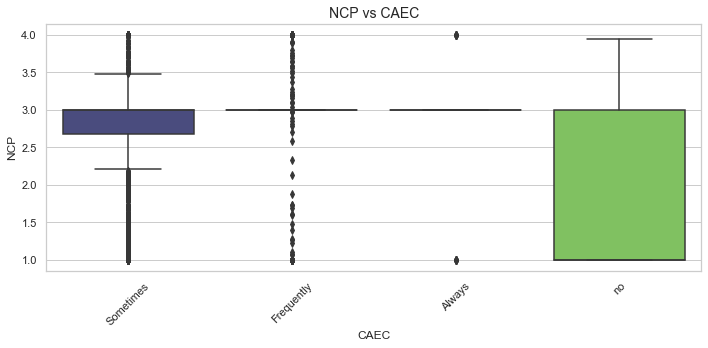

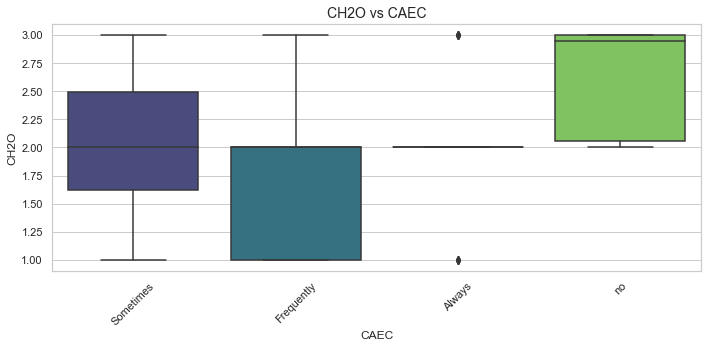

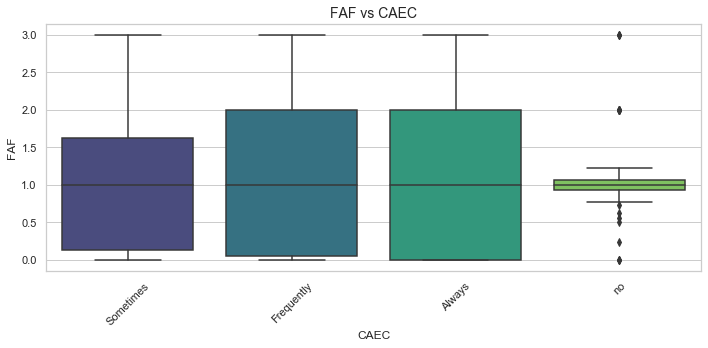

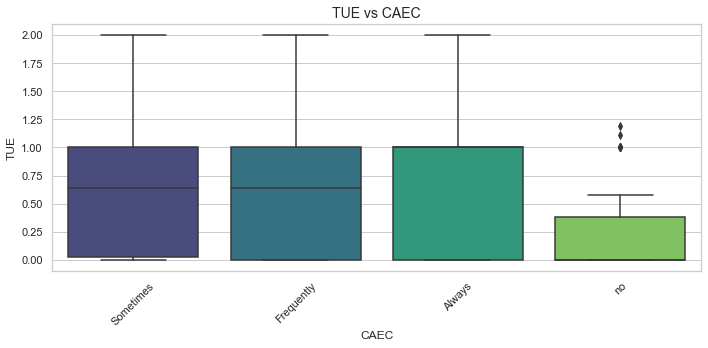



====== SMOKE: Numerical Comparison ======



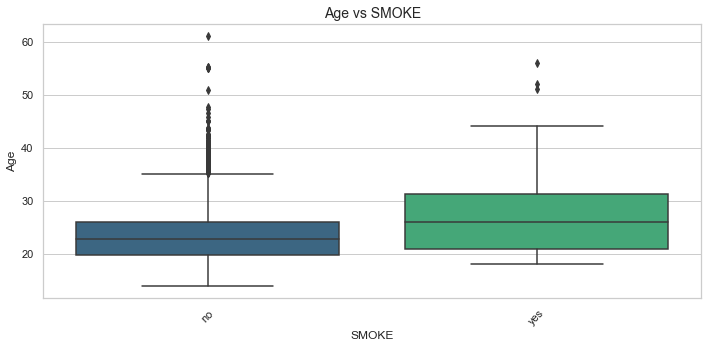

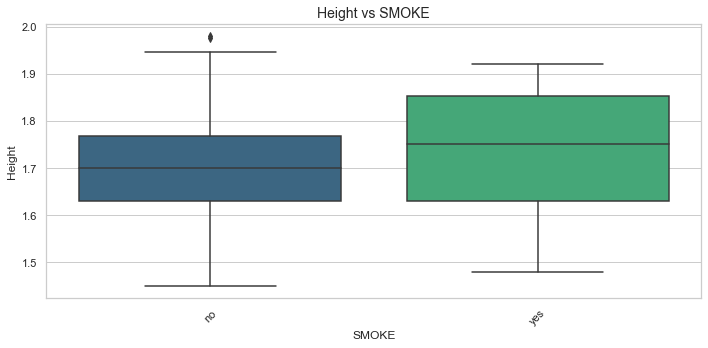

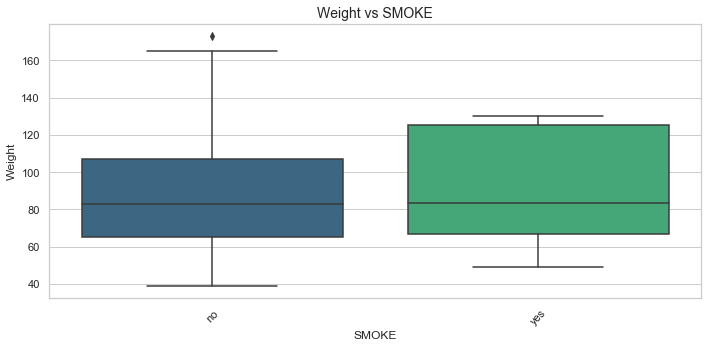

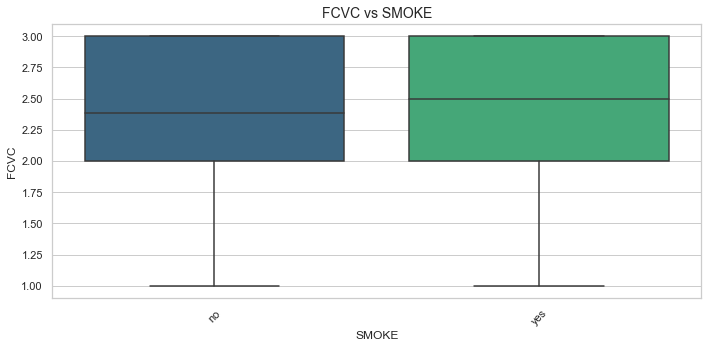

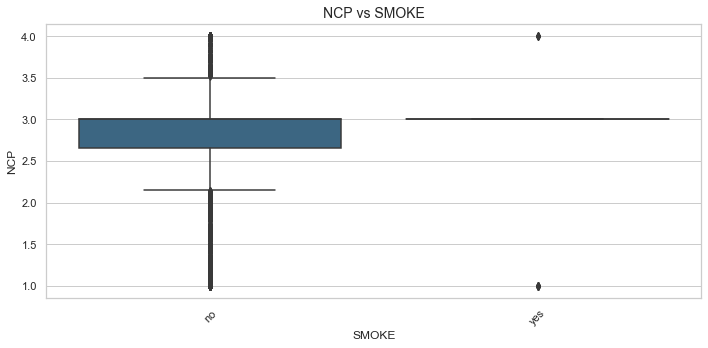

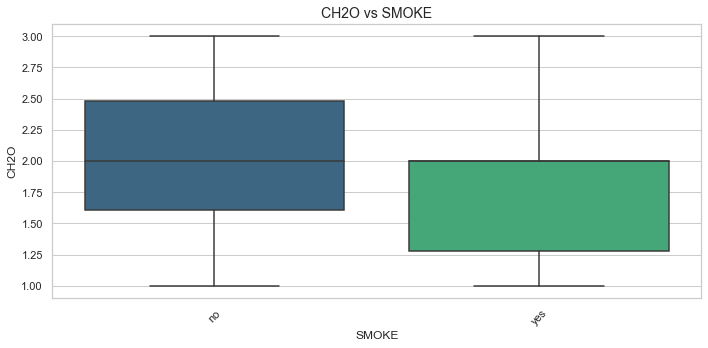

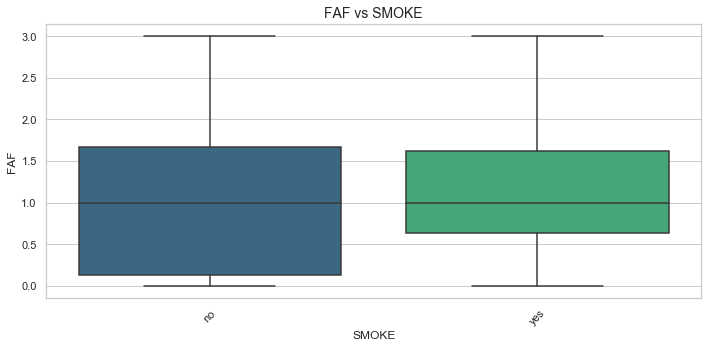

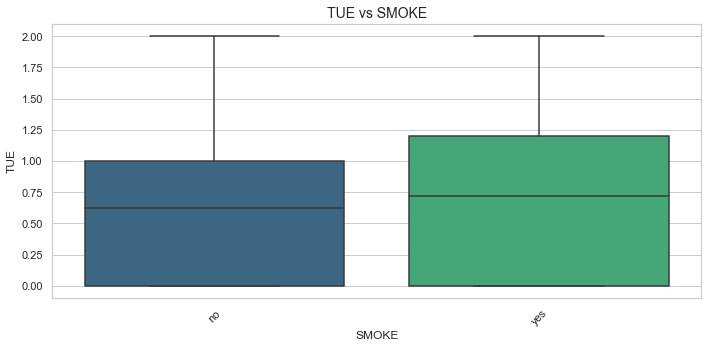



====== SCC: Numerical Comparison ======



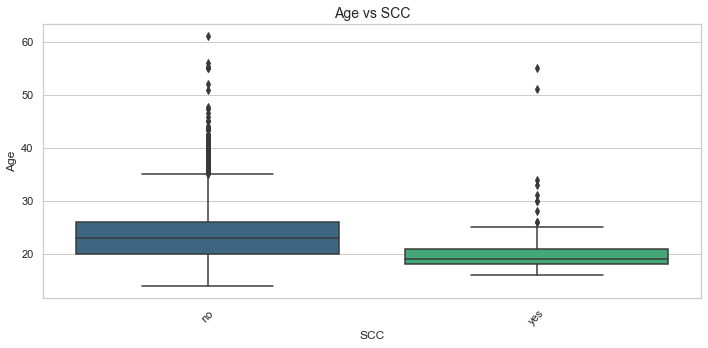

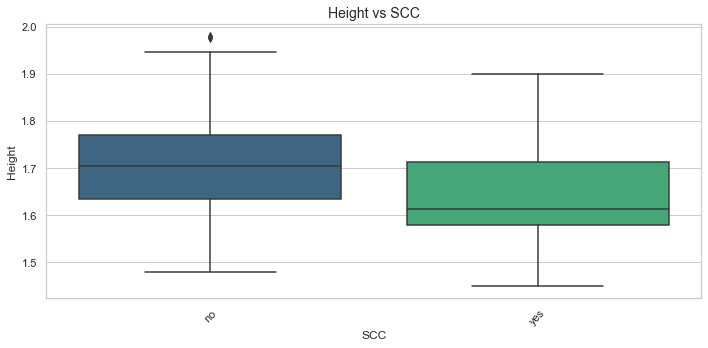

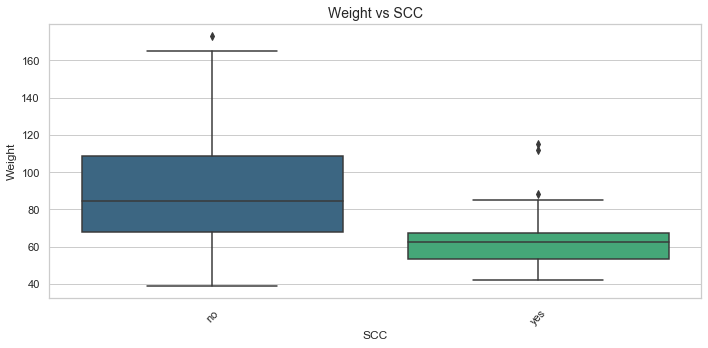

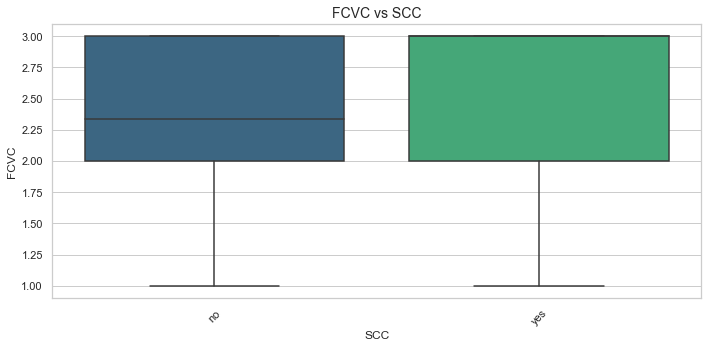

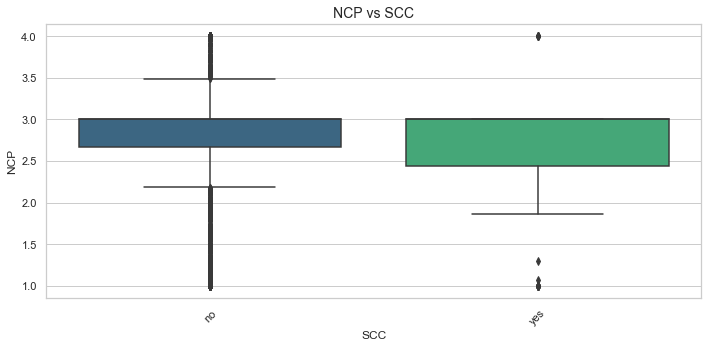

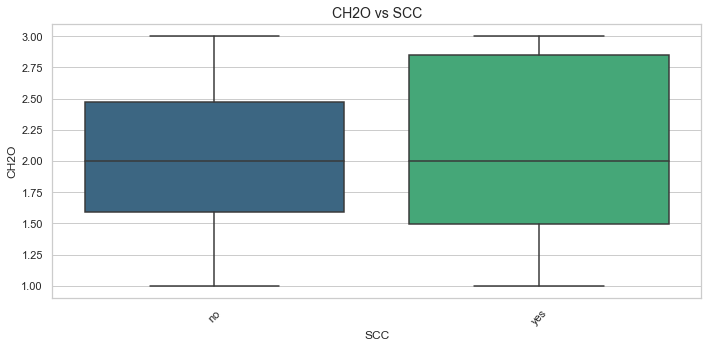

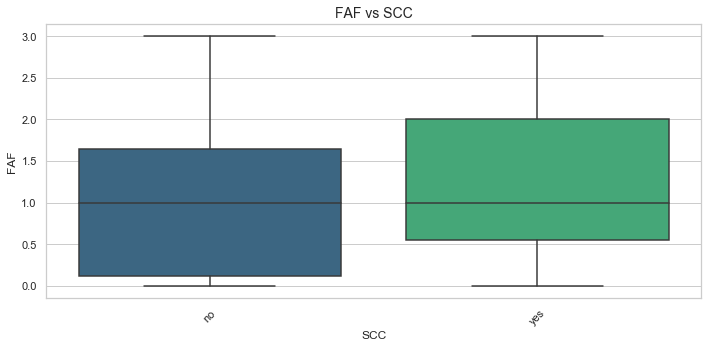

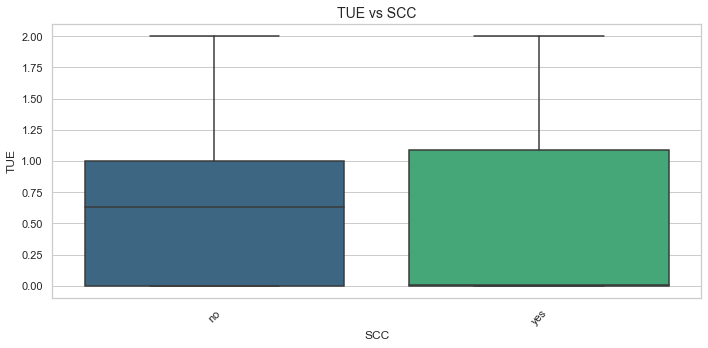



====== CALC: Numerical Comparison ======



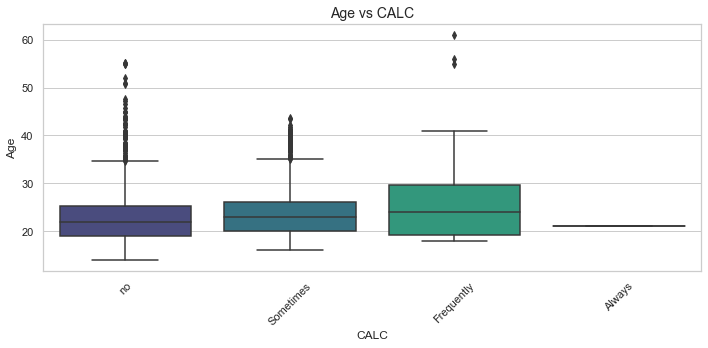

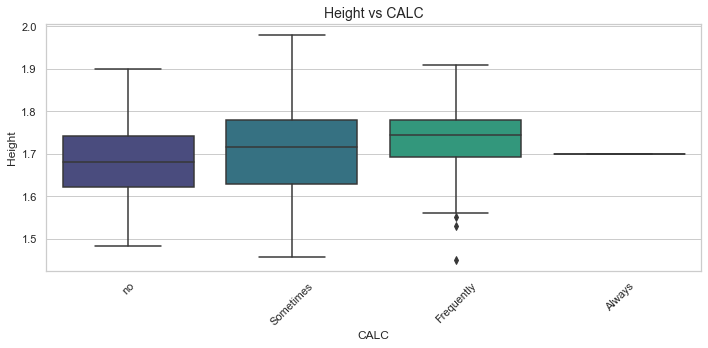

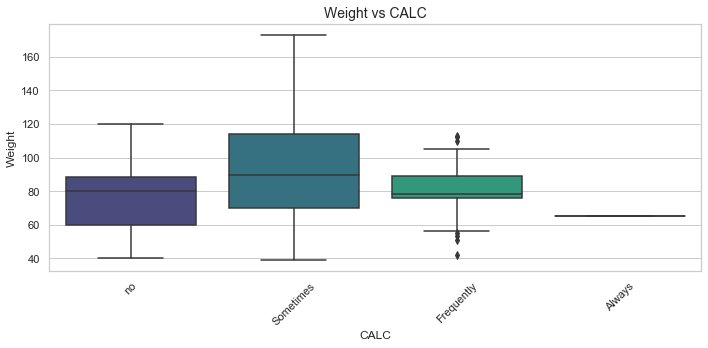

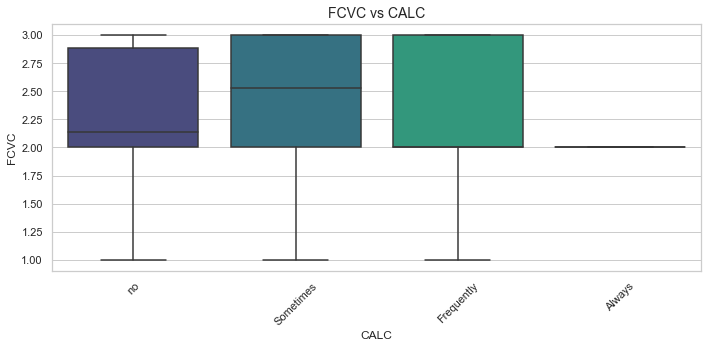

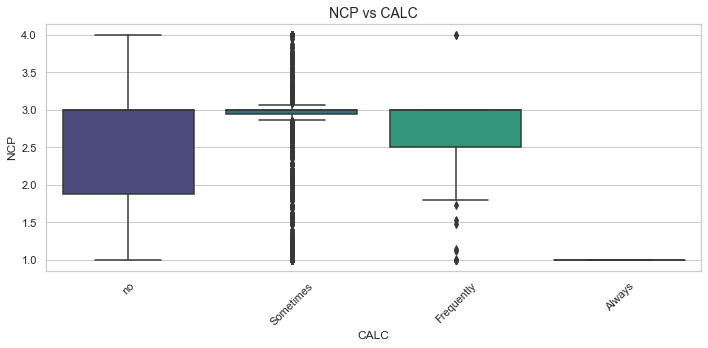

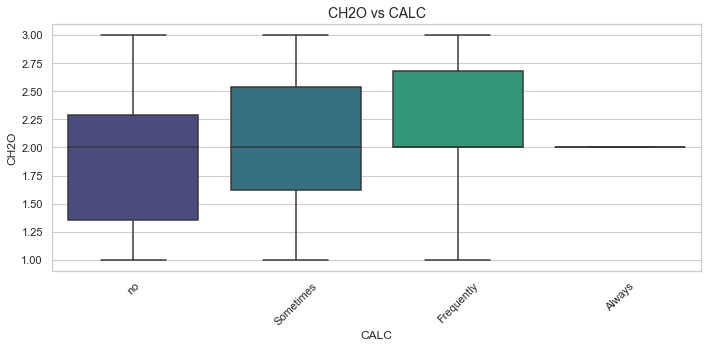

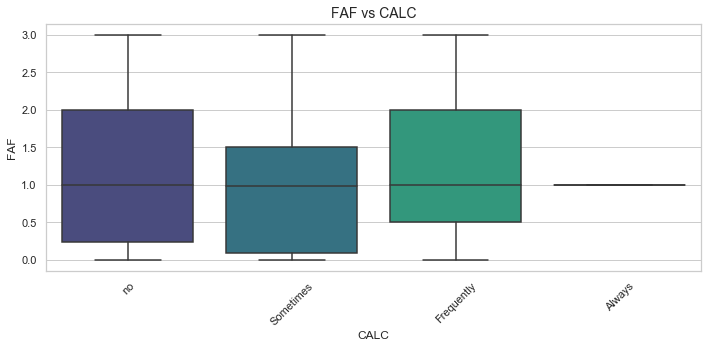

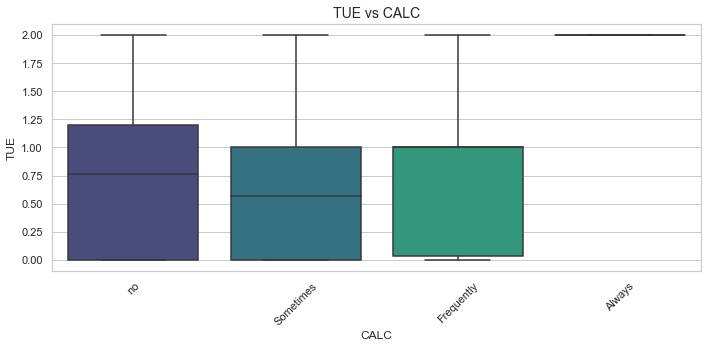



====== MTRANS: Numerical Comparison ======



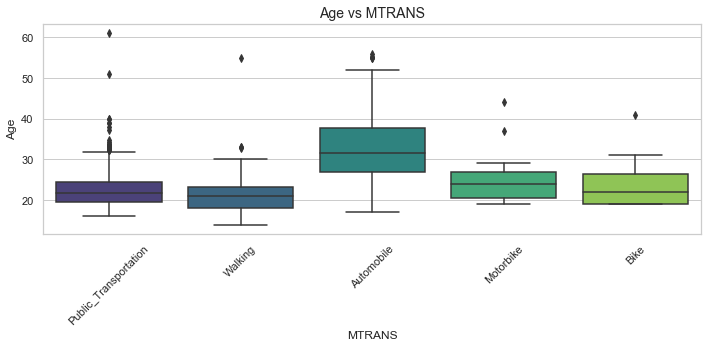

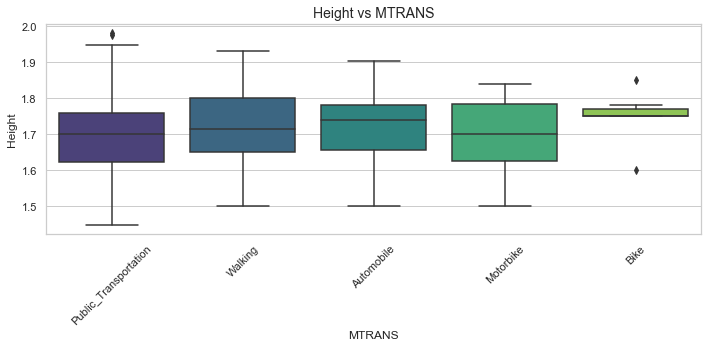

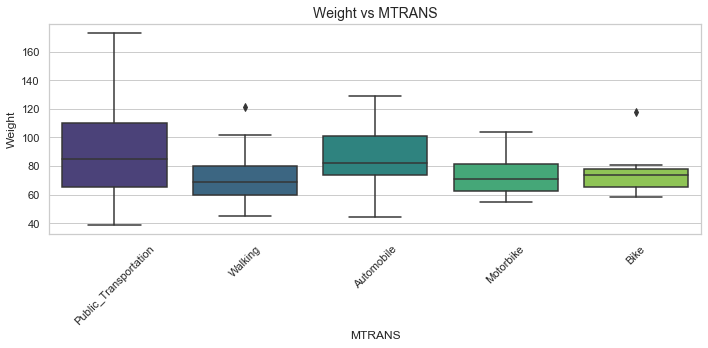

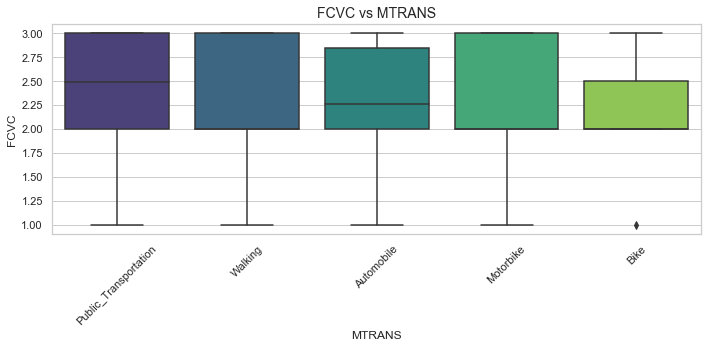

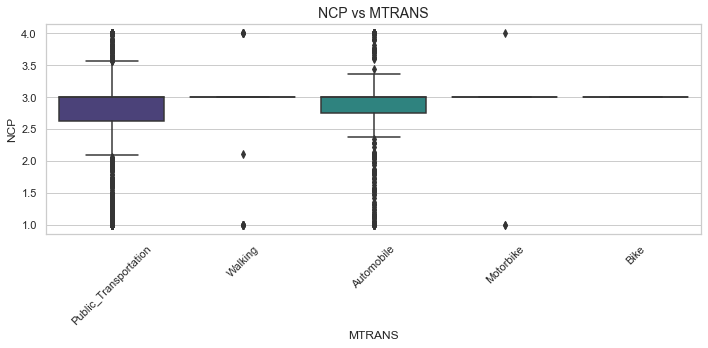

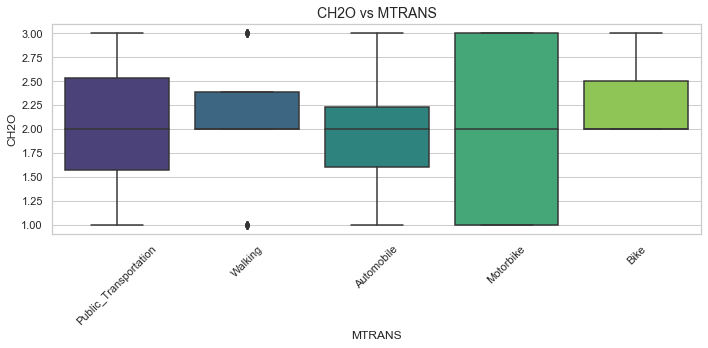

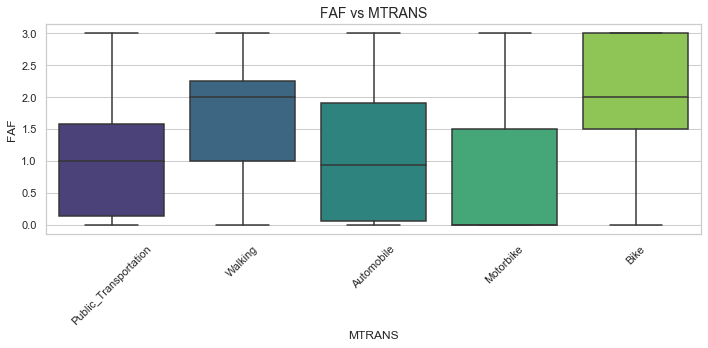

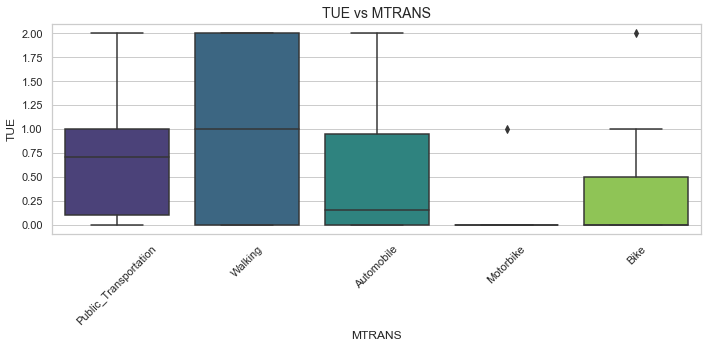

In [32]:
boxplot_all_num_vs_cat(df_obesity, numerical_columns, categorical_columns)

### GENDER DISTRIBUTION ACROSS OBESITY CATEGORIES

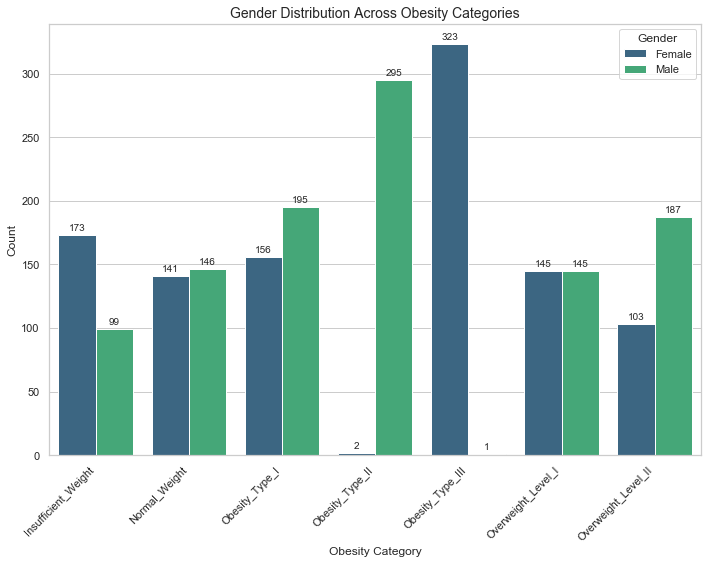

In [122]:
## ================================================================
## BAR GRAPH: GENDER DISTRIBUTION ACROSS OBESITY CATEGORIES
## ================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Group by gender + obesity level
gender_obesity_counts = df_obesity.groupby(["NObeyesdad", "Gender"]).size().reset_index(name="Count")

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=gender_obesity_counts,
    x="NObeyesdad",
    y="Count",
    hue="Gender",
    palette="viridis"
)

plt.title("Gender Distribution Across Obesity Categories", fontsize=14)
plt.xlabel("Obesity Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.0f}",  
        (p.get_x() + p.get_width() / 2., height + 2),
        ha='center',
        va='bottom',
        fontsize=10,
        rotation=0
    )

plt.legend(title="Gender")
plt.tight_layout()
plt.show()


### HYBRID PLOT CONTAINING BAR CHART WITH TOTAL LINE CHART

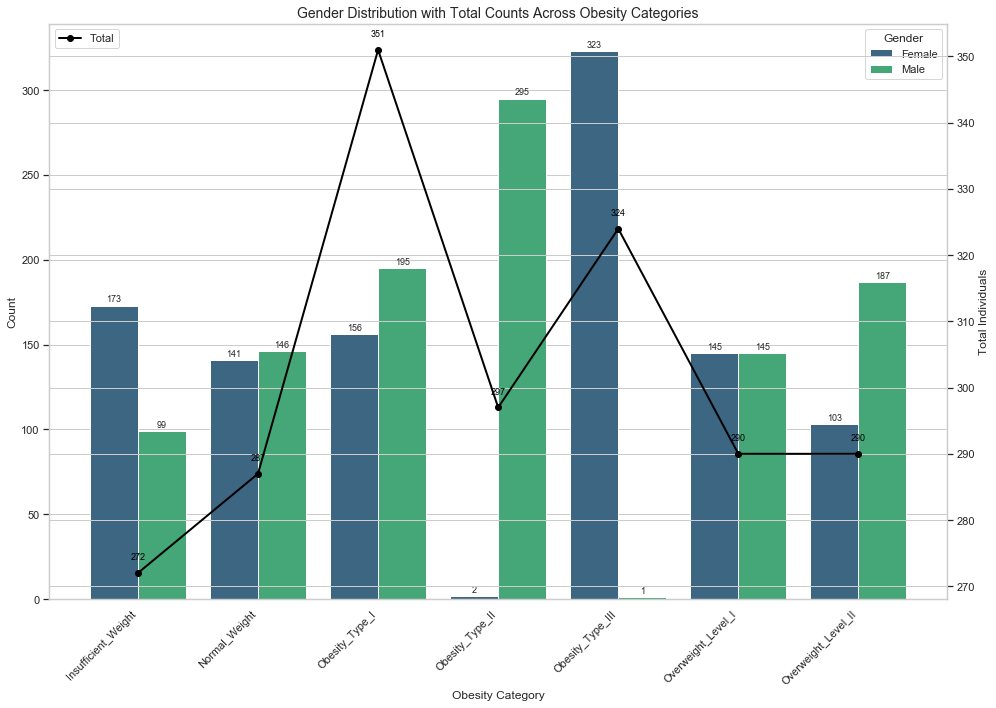

In [120]:
## ================================================================
## SIDE-BY-SIDE BARS + TOTAL COUNT LINE
## ================================================================

import numpy as np

# Compute counts
gender_counts = df_obesity.groupby(["NObeyesdad", "Gender"]).size().reset_index(name="Count")
total_counts = df_obesity["NObeyesdad"].value_counts().sort_index()

plt.figure(figsize=(14, 10))

# Side-by-side bars
ax = sns.barplot(
    data=gender_counts,
    x="NObeyesdad",
    y="Count",
    hue="Gender",
    palette="viridis"
)

# Line plot of totals
ax2 = ax.twinx()
ax2.plot(
    total_counts.index,
    total_counts.values,
    color="black",
    marker="o",
    linewidth=2,
    label="Total"
)

# Titles and labels
plt.title("Gender Distribution with Total Counts Across Obesity Categories", fontsize=14)
ax.set_xlabel("Obesity Category")
ax.set_ylabel("Count")
ax2.set_ylabel("Total Individuals")

ax.set_xticklabels(total_counts.index, rotation=45, ha="right")

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.0f}",
        (p.get_x() + p.get_width() / 2., height + 1),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Total count labels for the line
for i, val in enumerate(total_counts.values):
    ax2.annotate(
        f"{val}",
        (i, val + 2),
        ha="center",
        fontsize=9,
        color="black"
    )

# Legends
ax.legend(title="Gender")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

### PLOTS FOR OTHER NUMERICAL COLUMNS VS TARGET VARIABLE

In [33]:
## ================================================================
## AUTOMATED BARPLOT FUNCTION FOR NUMERICAL vs CATEGORICAL
## ================================================================

import seaborn as sns
import matplotlib.pyplot as plt

def plot_bar_num_cat(df, num_col, cat_col, palette="viridis"):
    """
    Creates a barplot showing the mean of a numerical variable
    across categories of a categorical variable.
    Includes value labels above each bar.
    """
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df,
        x=cat_col,
        y=num_col,
        palette=palette,
        errorbar=None  # removes confidence intervals for cleaner look
    )
    
    plt.title(f"Mean {num_col} Across {cat_col} Categories", fontsize=14)
    plt.xlabel(cat_col, fontsize=12)
    plt.ylabel(f"Mean {num_col}", fontsize=12)
    plt.xticks(rotation=45, ha="right")

    # Add value labels above bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2., height + 0.01),
            ha='center',
            va='bottom',
            fontsize=12,
            rotation=0
        )

    plt.tight_layout()
    plt.show()

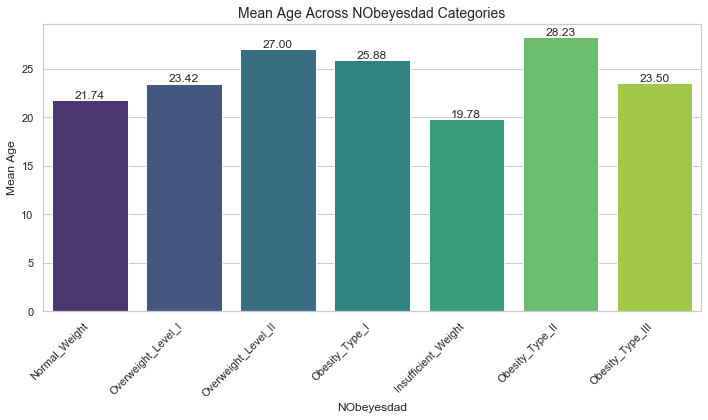

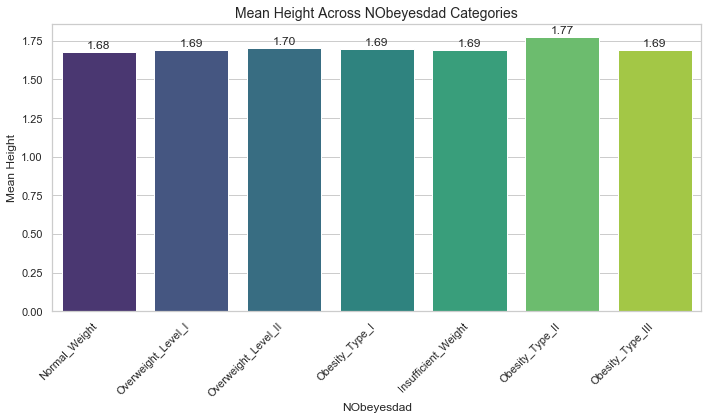

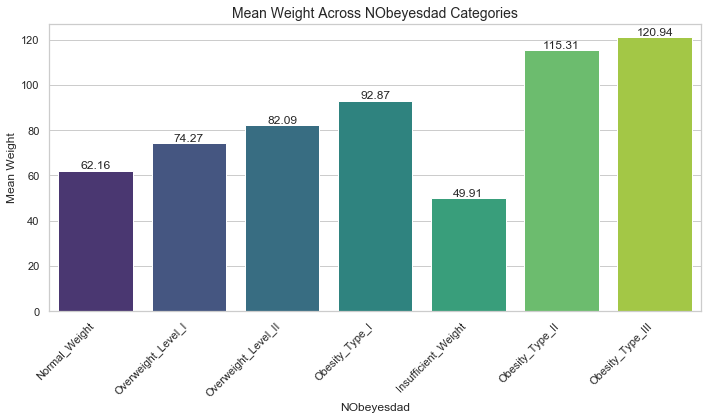

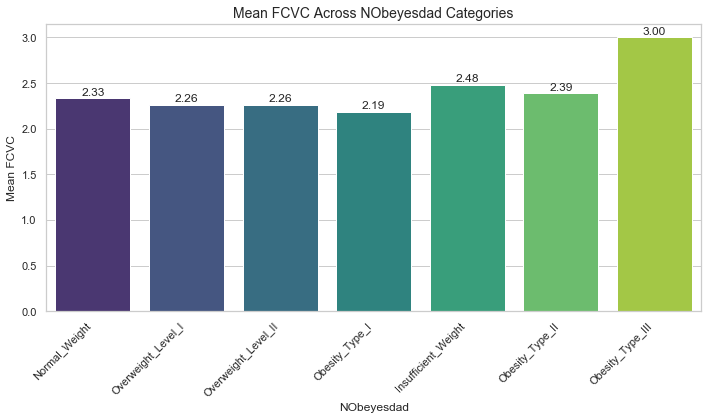

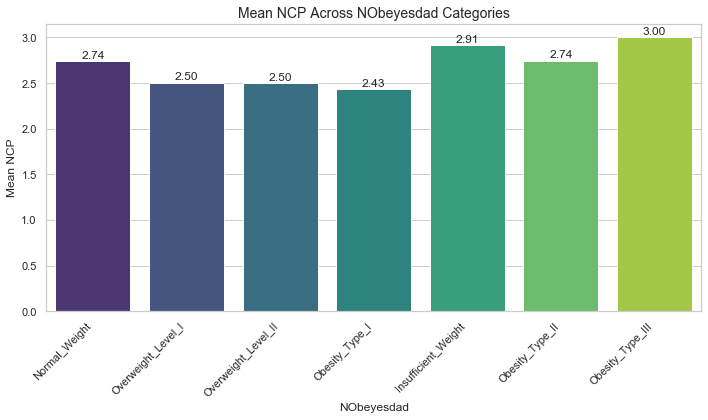

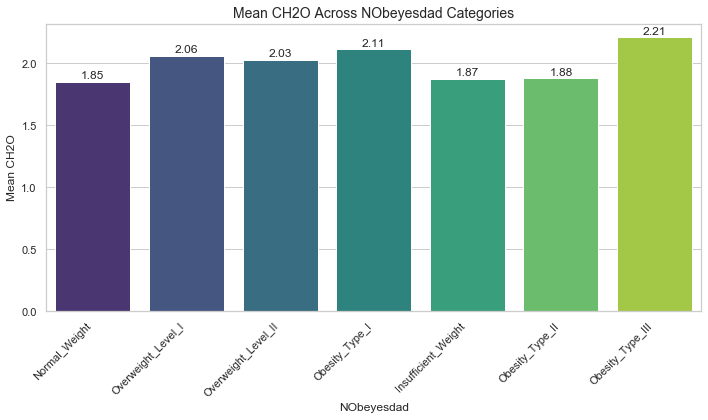

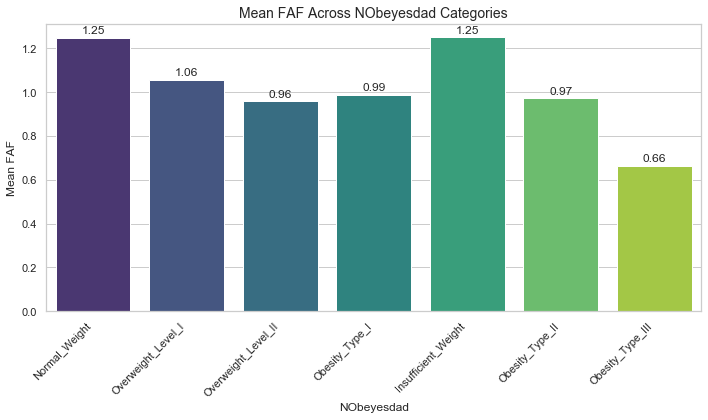

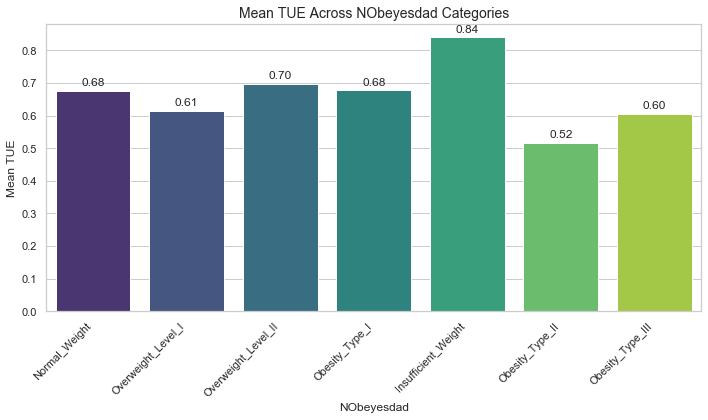

In [34]:
for num in numerical_columns:
    plot_bar_num_cat(df_obesity, num, target_variable)

### PLOTS FOR OTHER NUMERICAL VS CATEGORICAL COLUMNS


Plotting: Age vs Gender


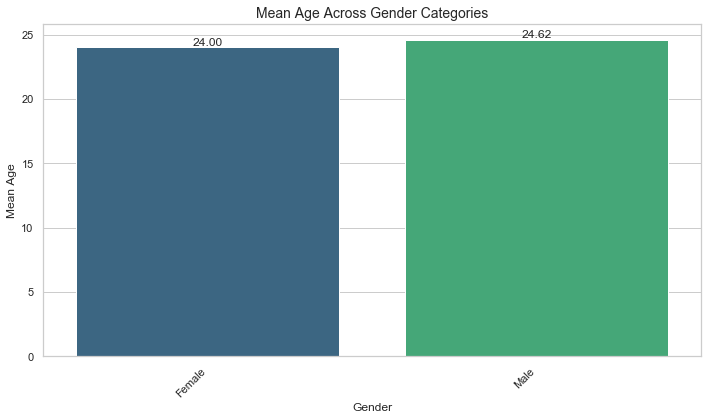


Plotting: Age vs family_history_with_overweight


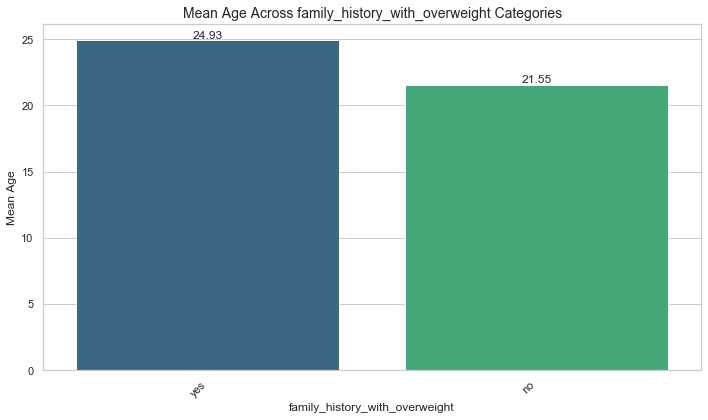


Plotting: Age vs FAVC


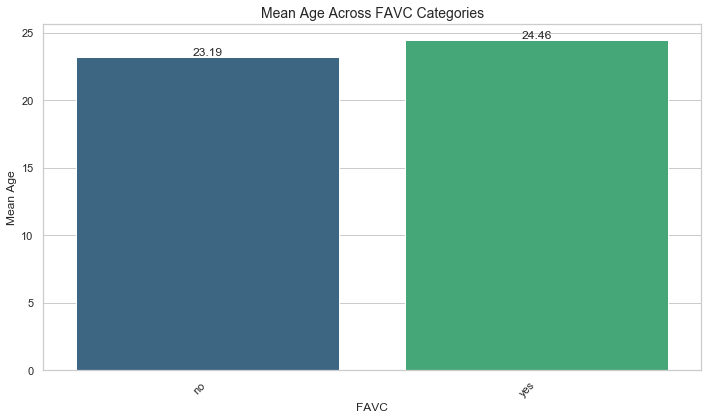


Plotting: Age vs CAEC


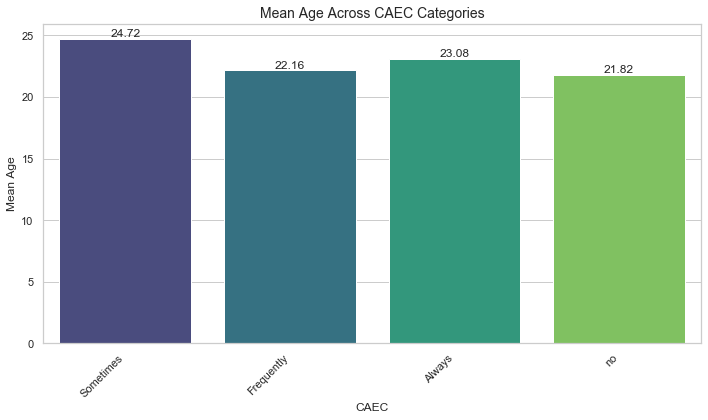


Plotting: Age vs SMOKE


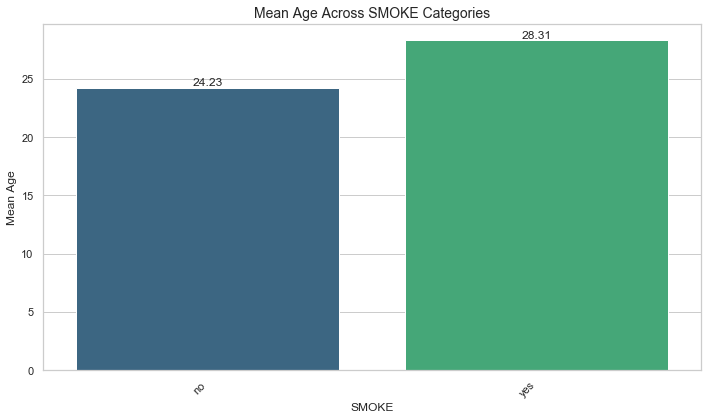


Plotting: Age vs SCC


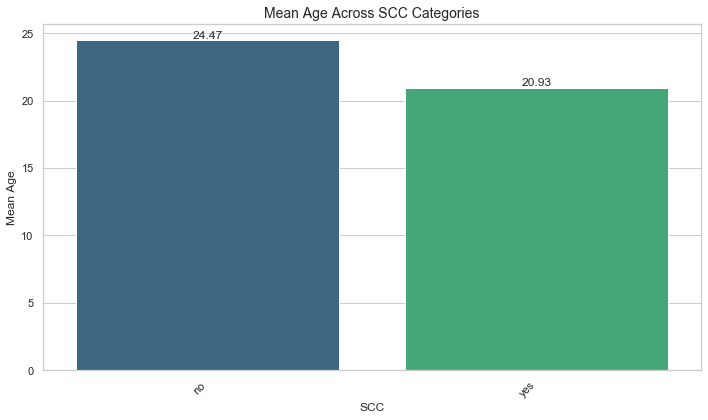


Plotting: Age vs CALC


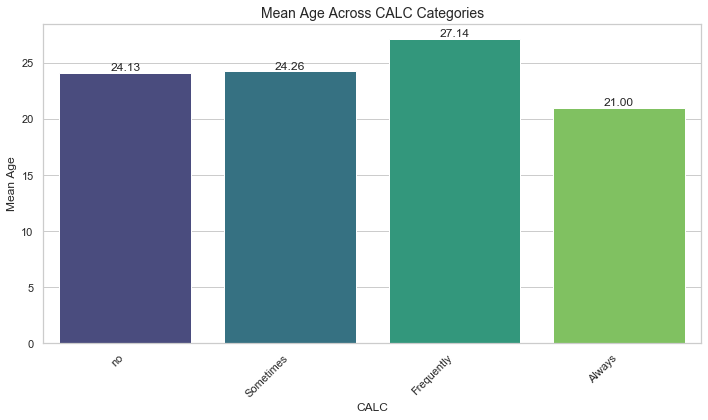


Plotting: Age vs MTRANS


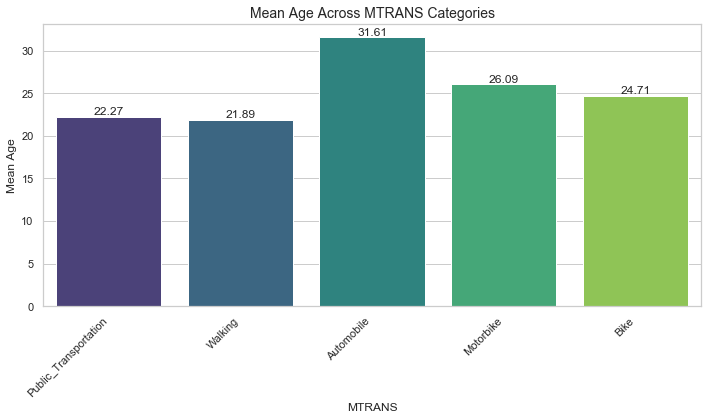


Plotting: Height vs Gender


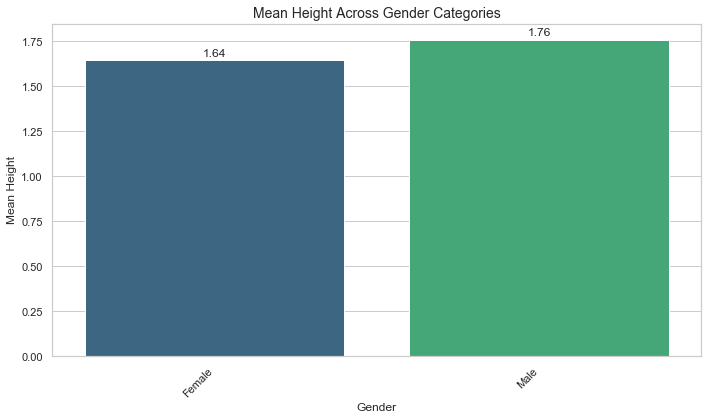


Plotting: Height vs family_history_with_overweight


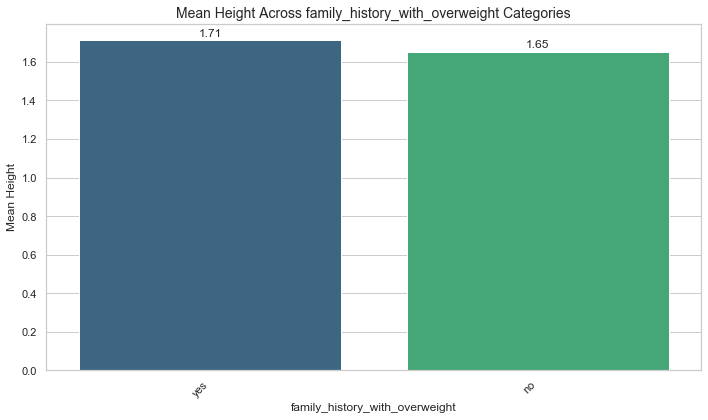


Plotting: Height vs FAVC


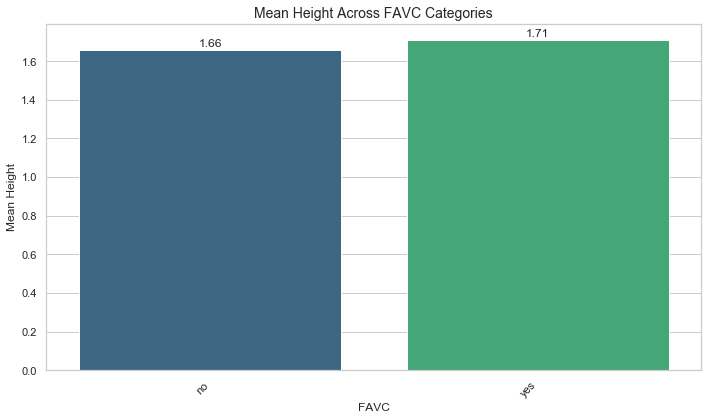


Plotting: Height vs CAEC


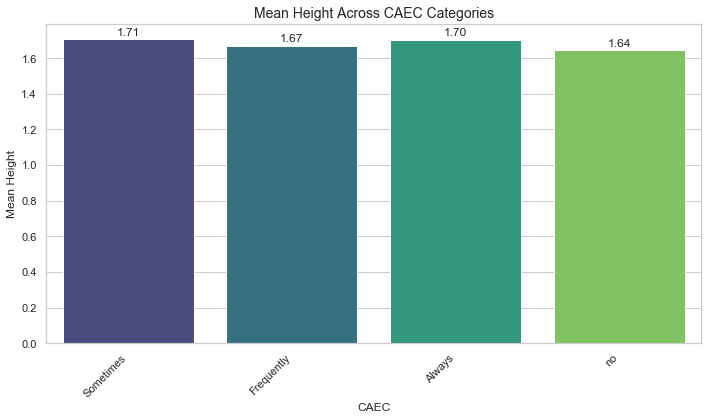


Plotting: Height vs SMOKE


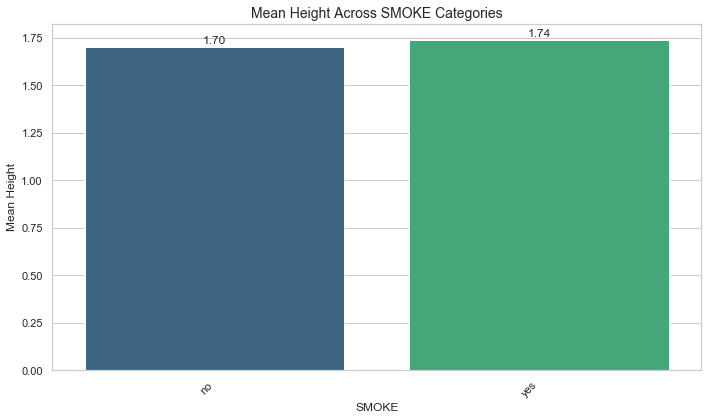


Plotting: Height vs SCC


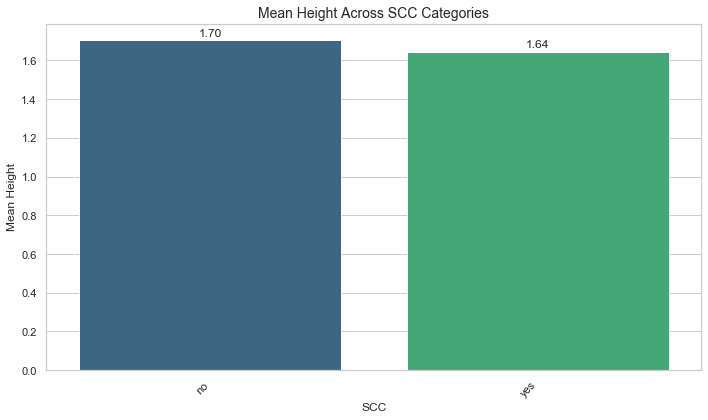


Plotting: Height vs CALC


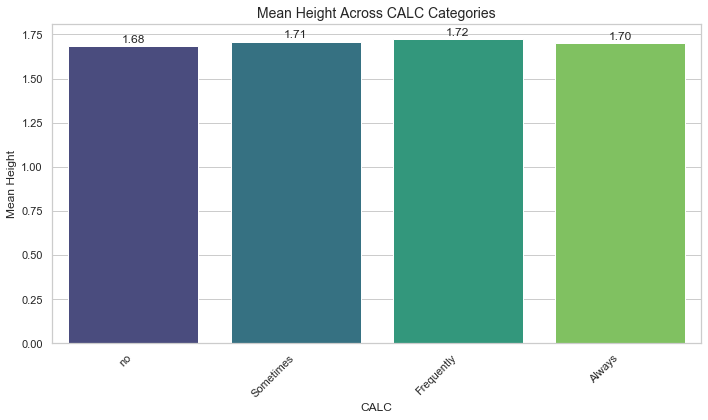


Plotting: Height vs MTRANS


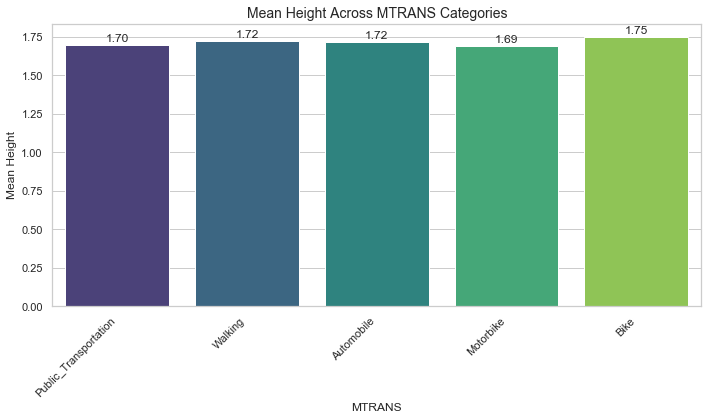


Plotting: Weight vs Gender


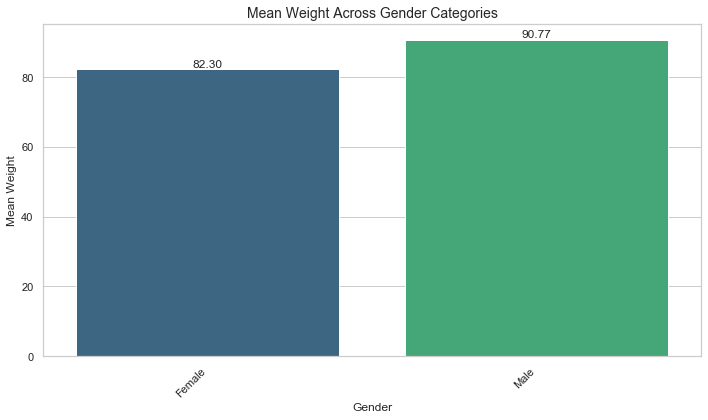


Plotting: Weight vs family_history_with_overweight


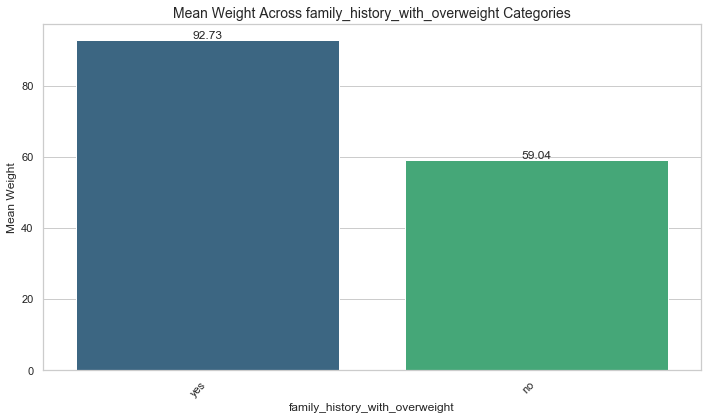


Plotting: Weight vs FAVC


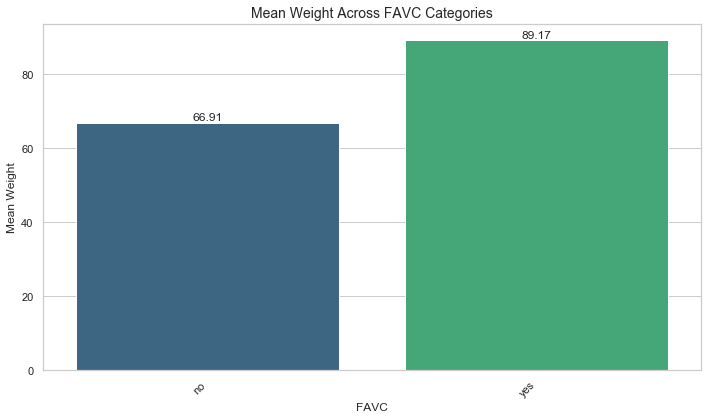


Plotting: Weight vs CAEC


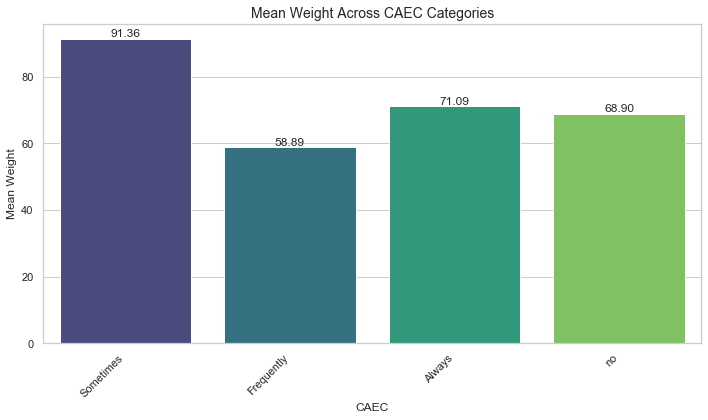


Plotting: Weight vs SMOKE


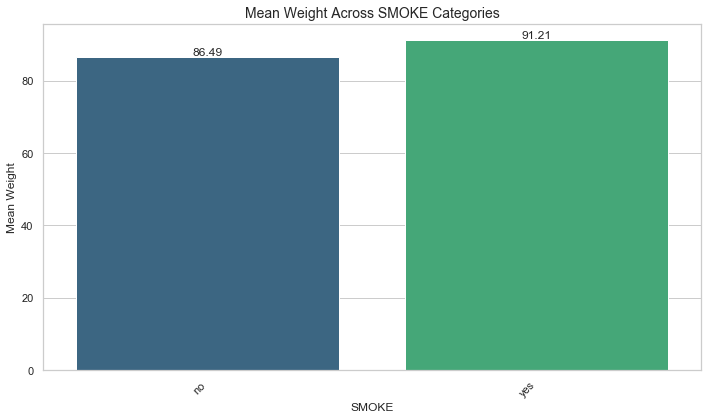


Plotting: Weight vs SCC


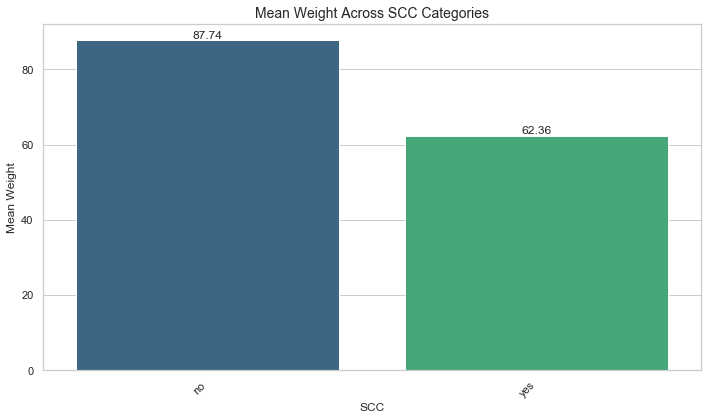


Plotting: Weight vs CALC


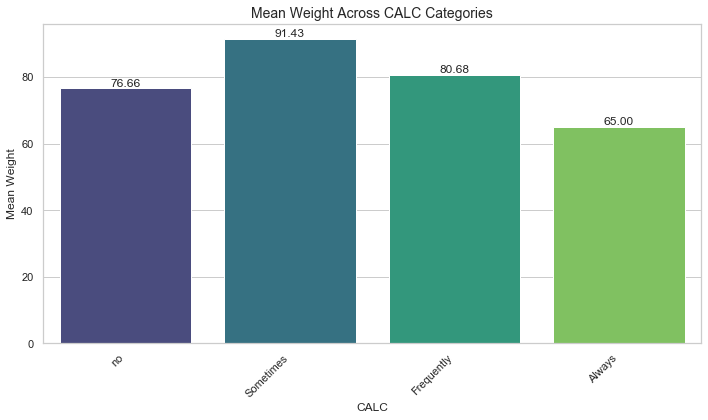


Plotting: Weight vs MTRANS


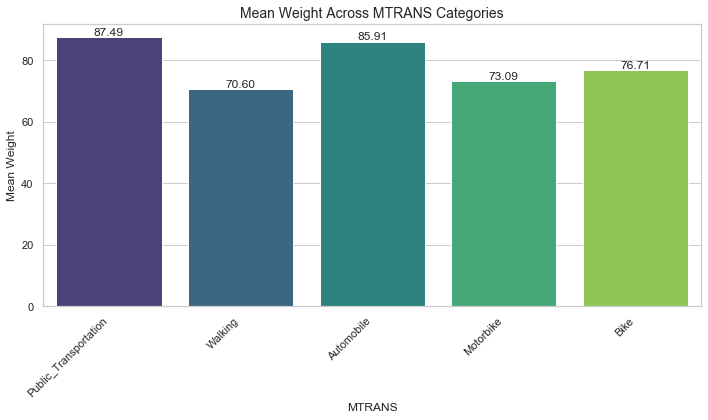


Plotting: FCVC vs Gender


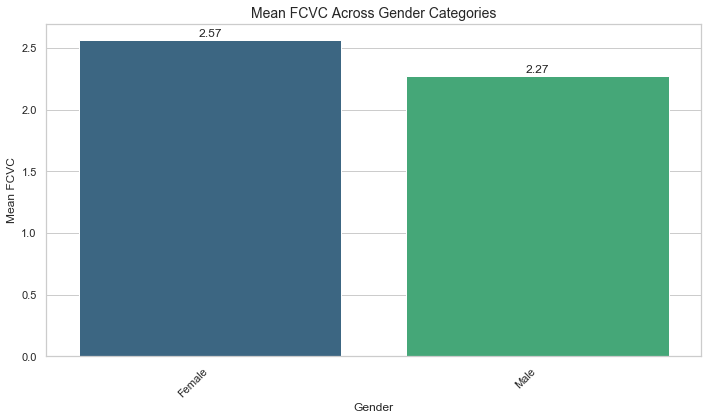


Plotting: FCVC vs family_history_with_overweight


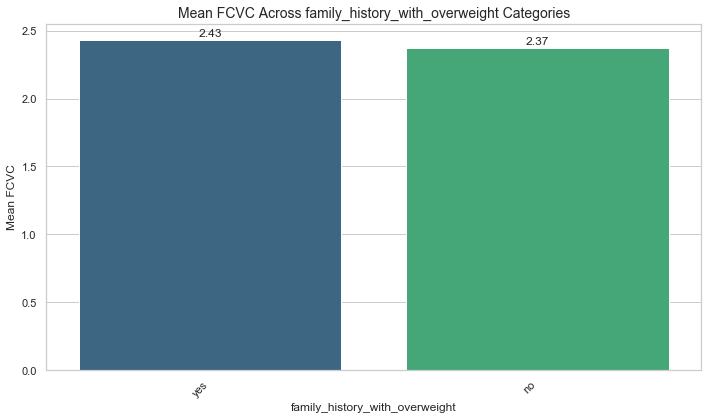


Plotting: FCVC vs FAVC


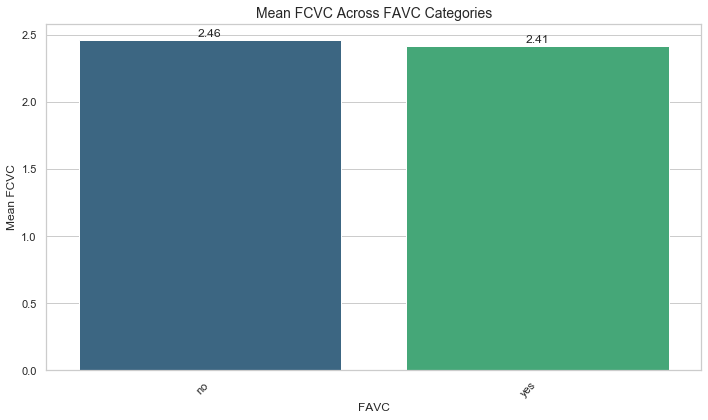


Plotting: FCVC vs CAEC


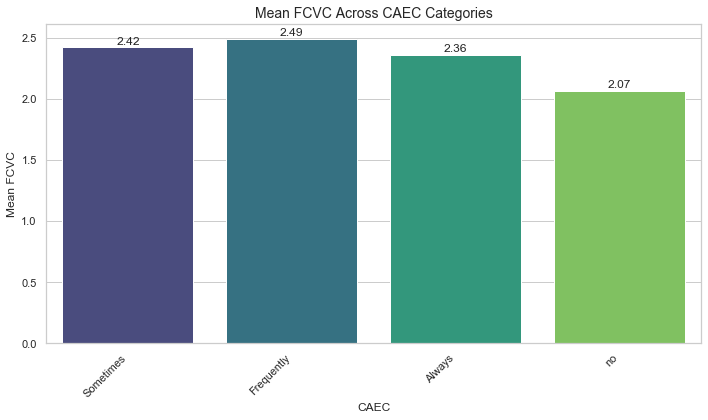


Plotting: FCVC vs SMOKE


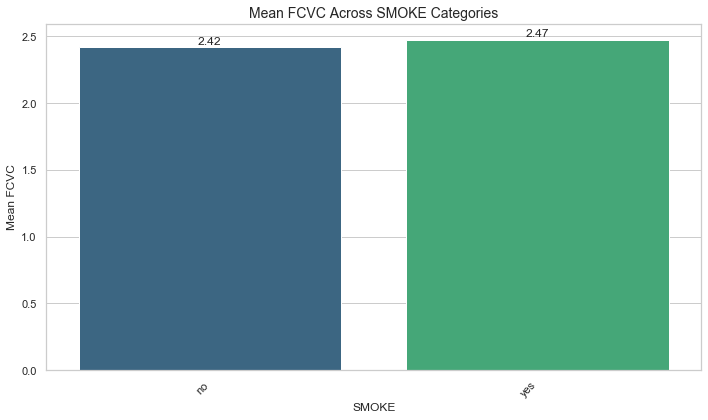


Plotting: FCVC vs SCC


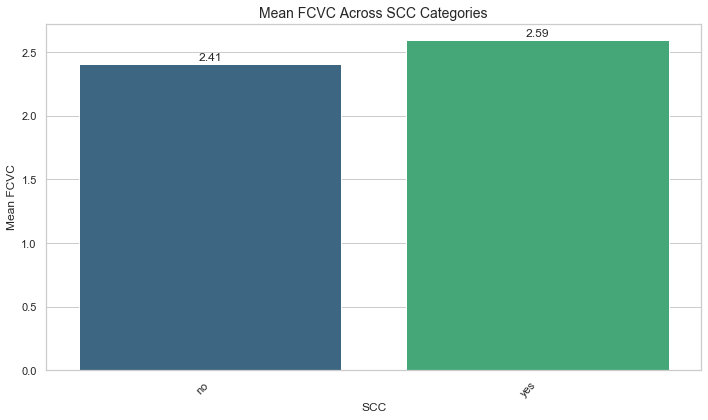


Plotting: FCVC vs CALC


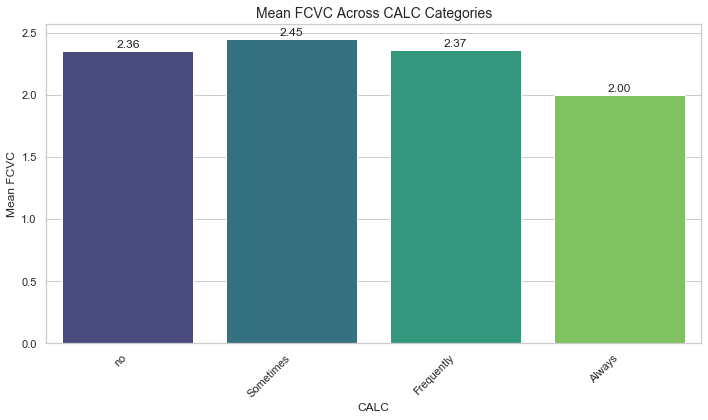


Plotting: FCVC vs MTRANS


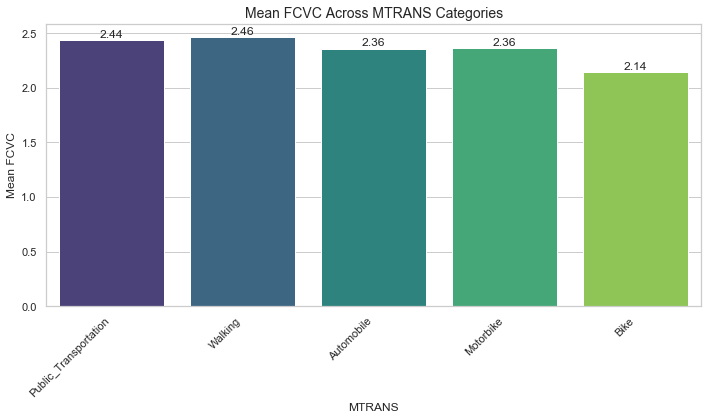


Plotting: NCP vs Gender


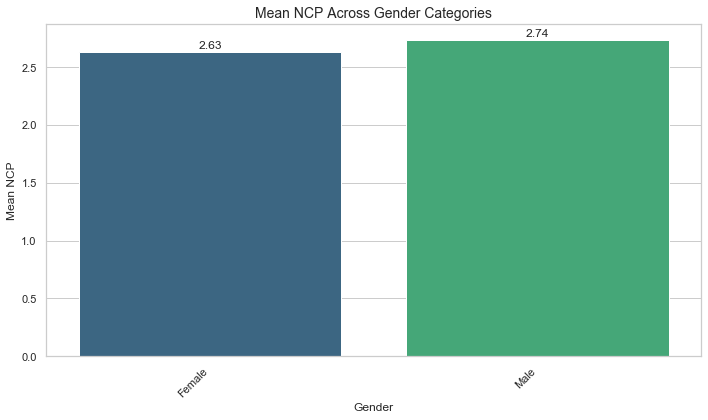


Plotting: NCP vs family_history_with_overweight


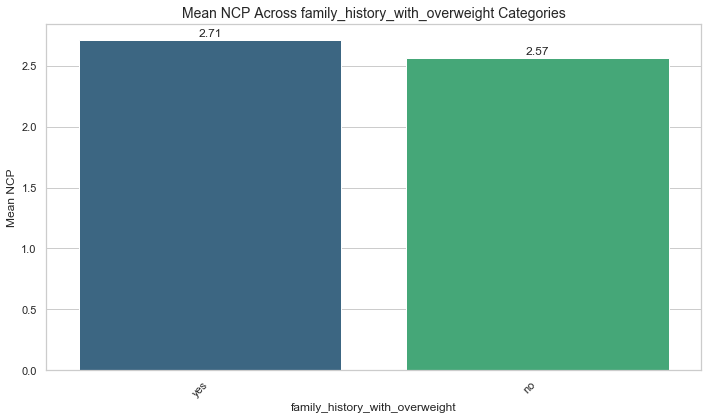


Plotting: NCP vs FAVC


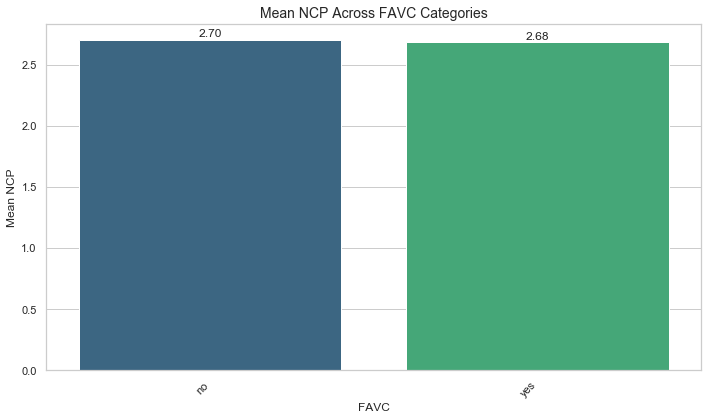


Plotting: NCP vs CAEC


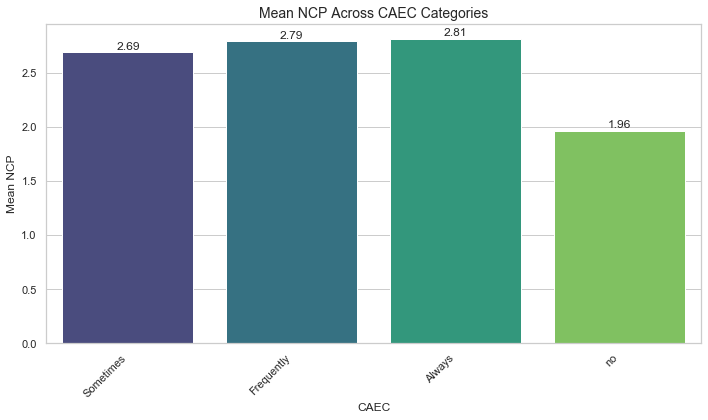


Plotting: NCP vs SMOKE


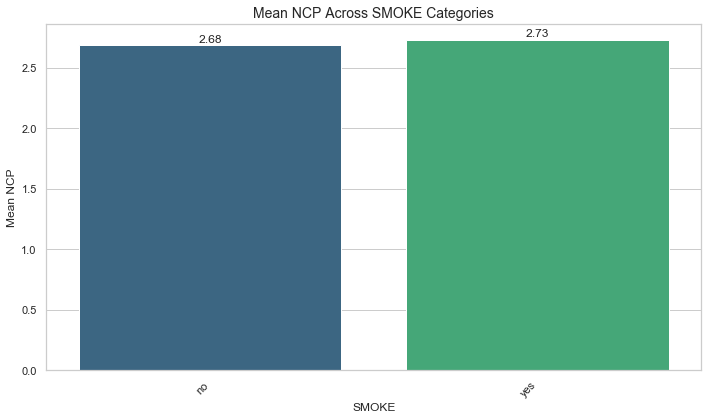


Plotting: NCP vs SCC


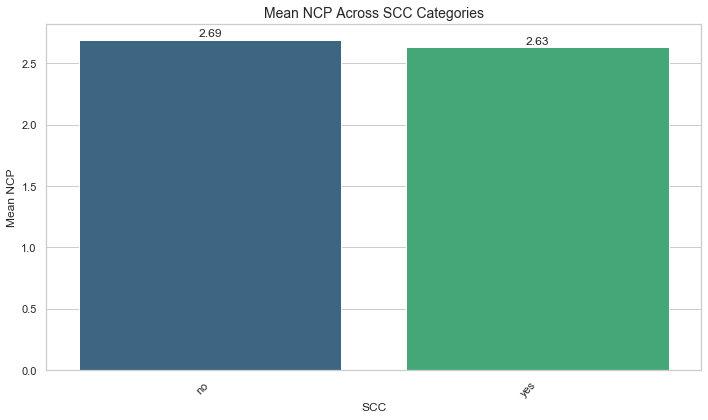


Plotting: NCP vs CALC


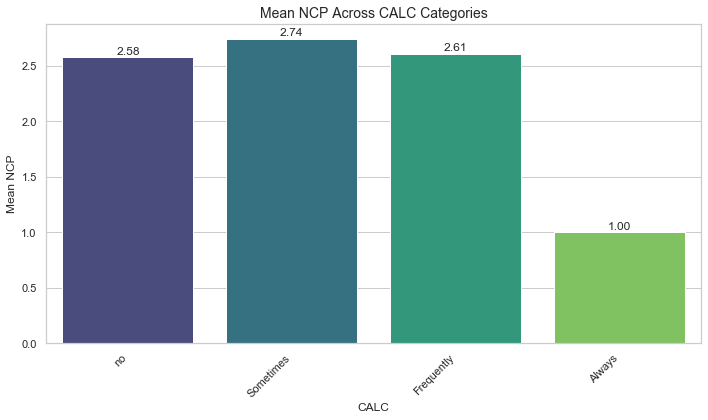


Plotting: NCP vs MTRANS


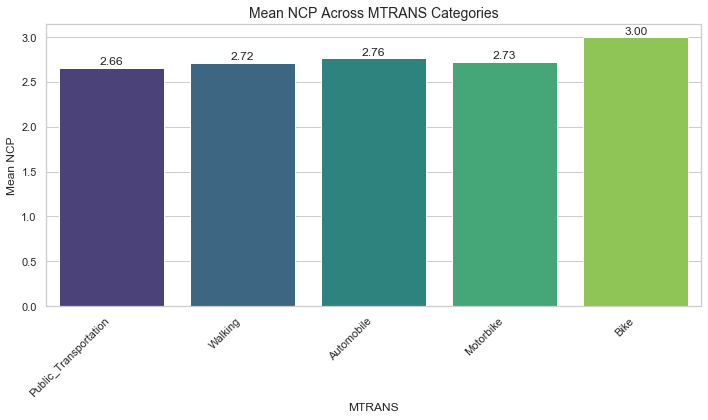


Plotting: CH2O vs Gender


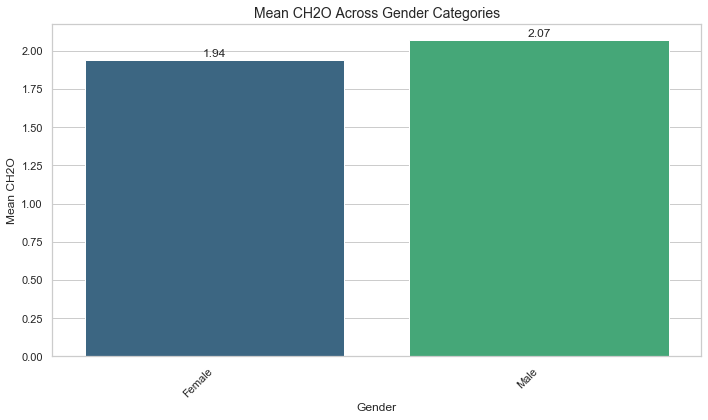


Plotting: CH2O vs family_history_with_overweight


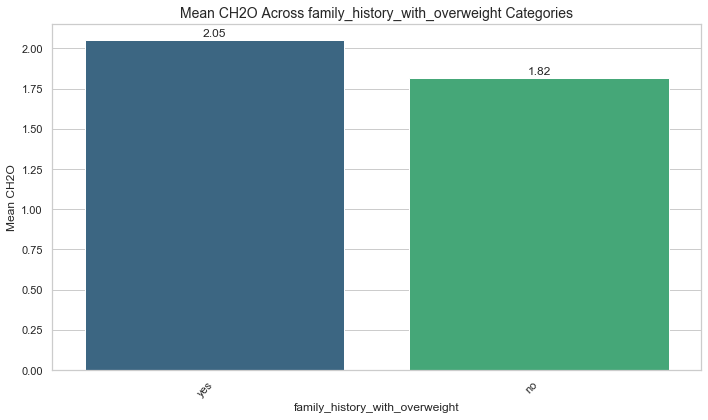


Plotting: CH2O vs FAVC


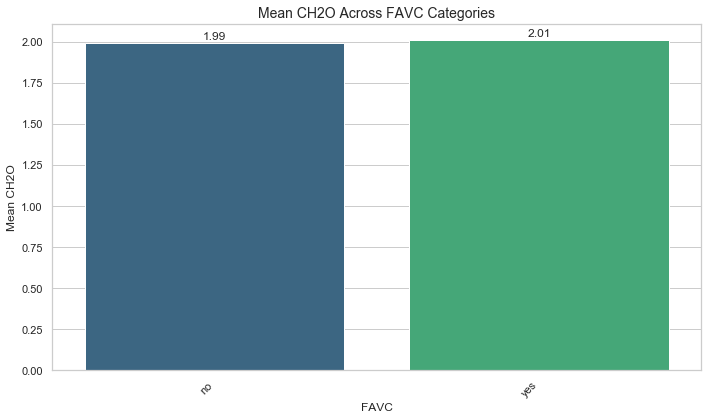


Plotting: CH2O vs CAEC


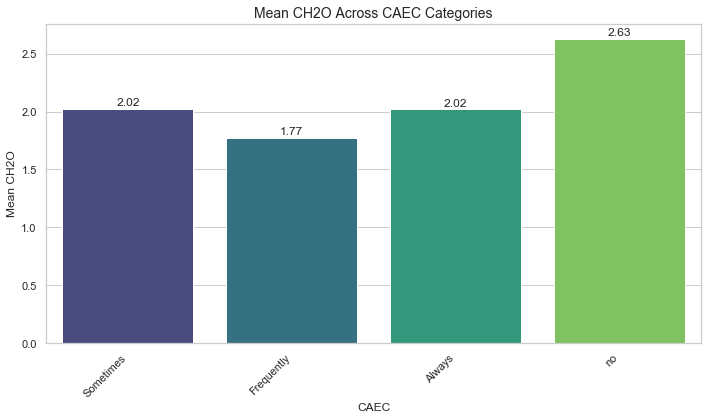


Plotting: CH2O vs SMOKE


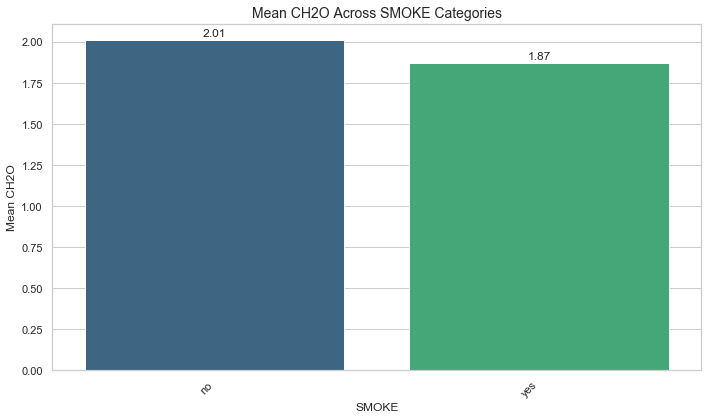


Plotting: CH2O vs SCC


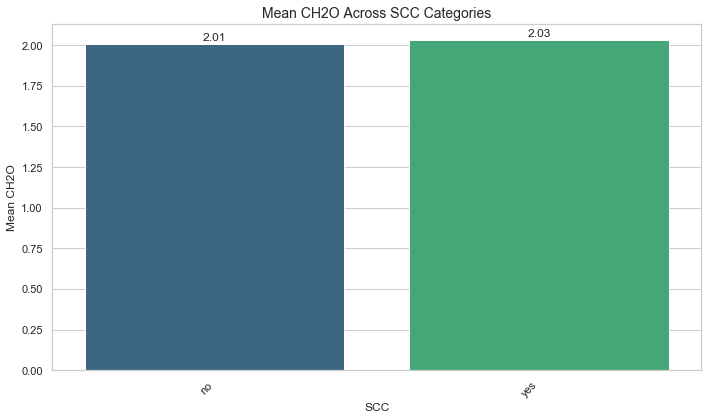


Plotting: CH2O vs CALC


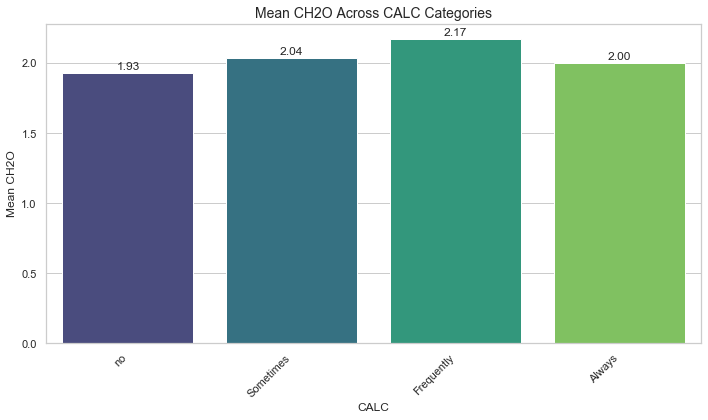


Plotting: CH2O vs MTRANS


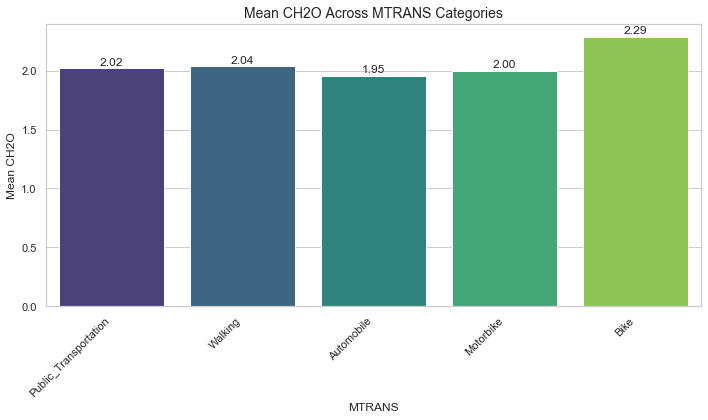


Plotting: FAF vs Gender


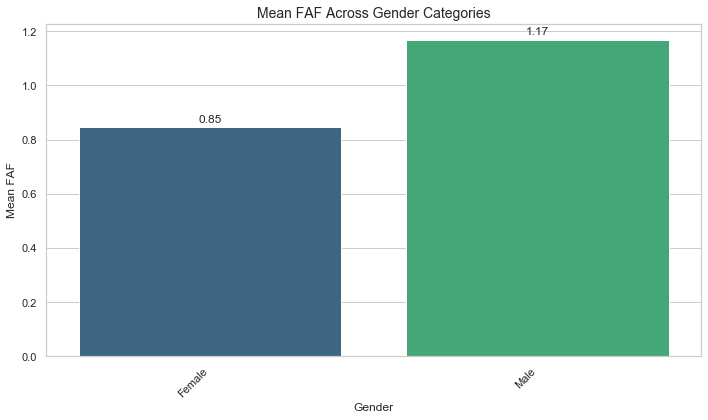


Plotting: FAF vs family_history_with_overweight


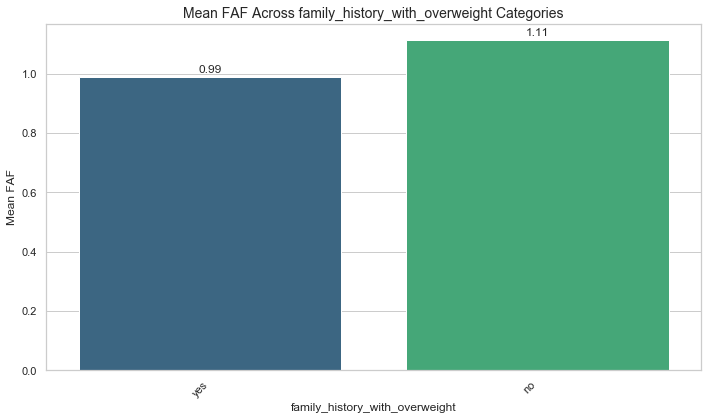


Plotting: FAF vs FAVC


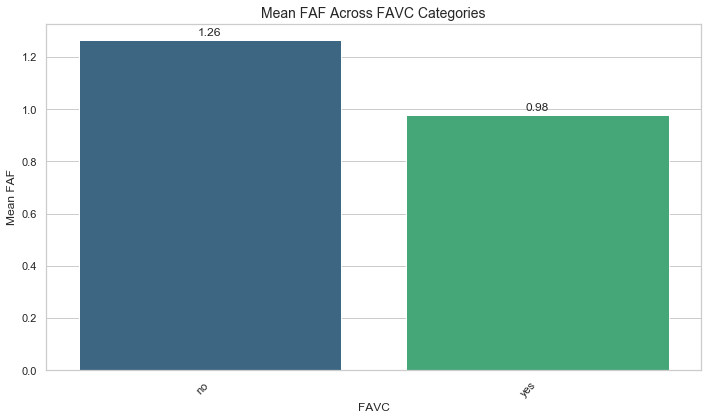


Plotting: FAF vs CAEC


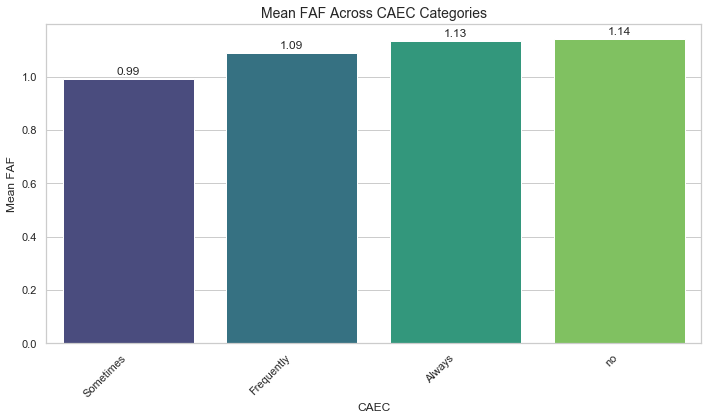


Plotting: FAF vs SMOKE


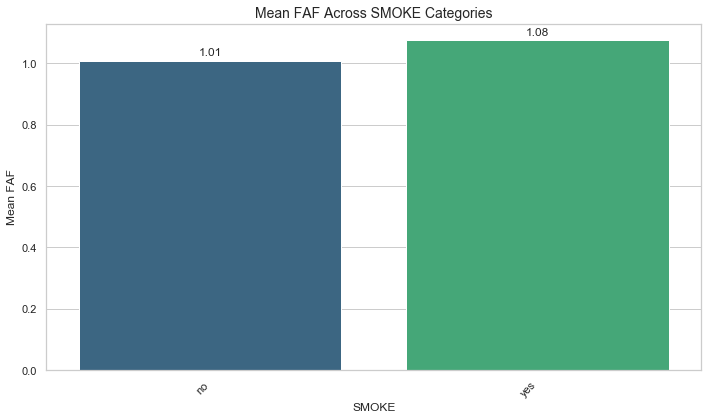


Plotting: FAF vs SCC


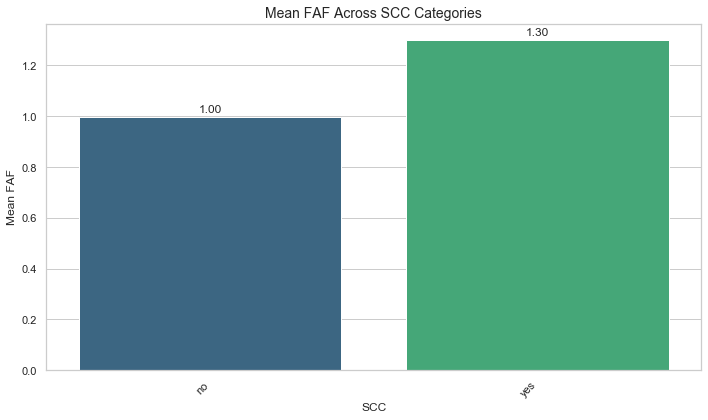


Plotting: FAF vs CALC


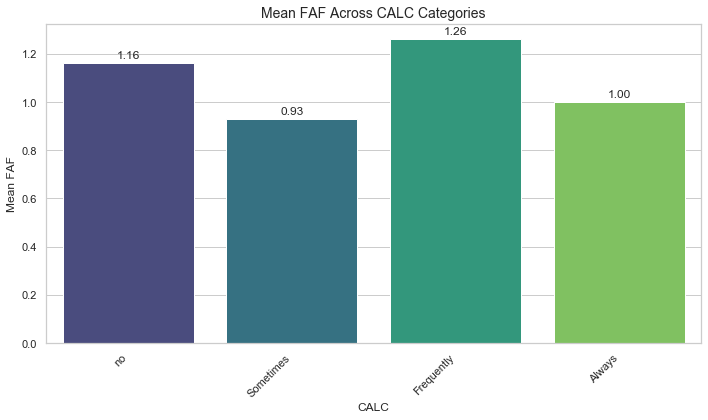


Plotting: FAF vs MTRANS


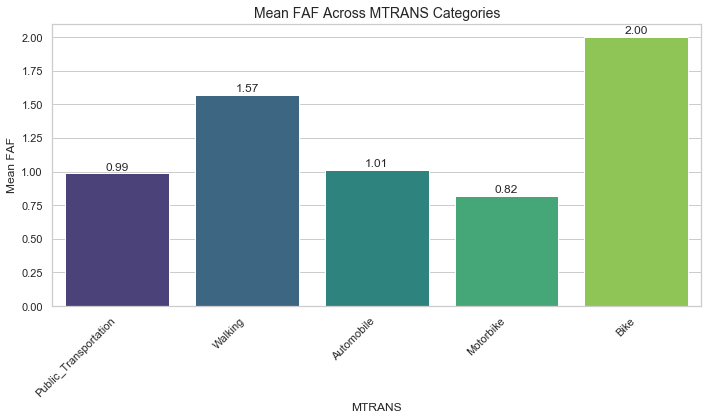


Plotting: TUE vs Gender


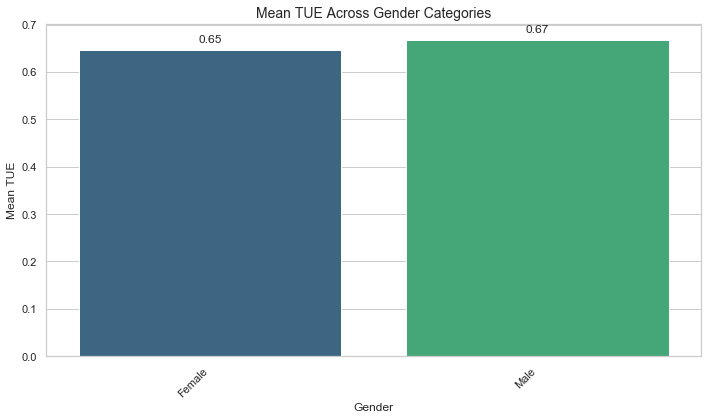


Plotting: TUE vs family_history_with_overweight


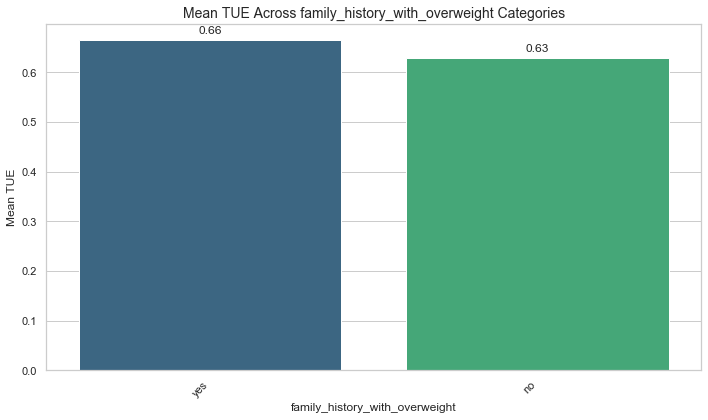


Plotting: TUE vs FAVC


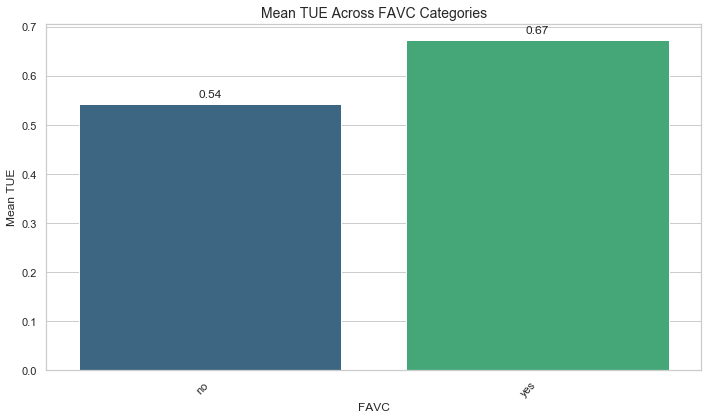


Plotting: TUE vs CAEC


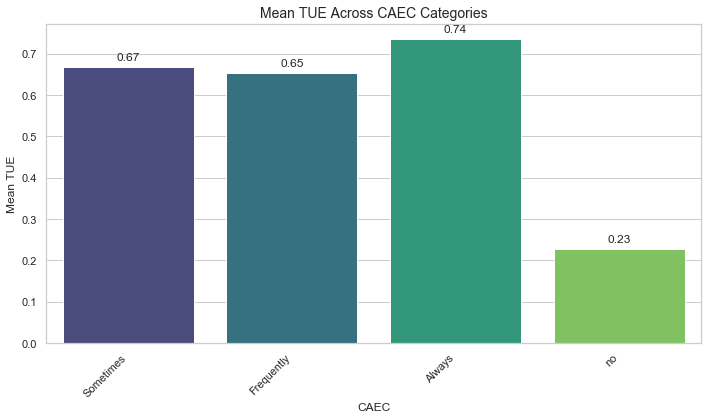


Plotting: TUE vs SMOKE


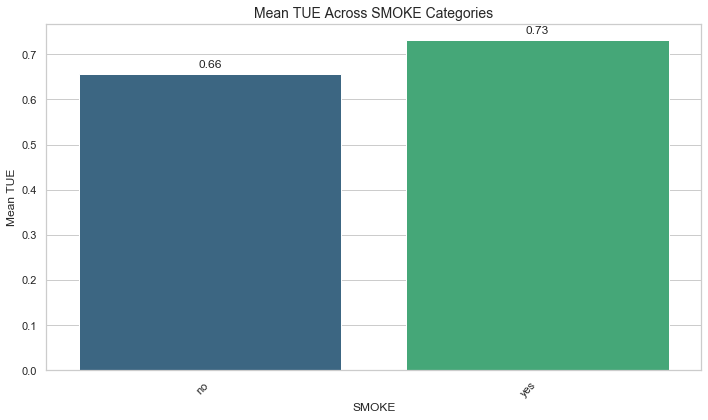


Plotting: TUE vs SCC


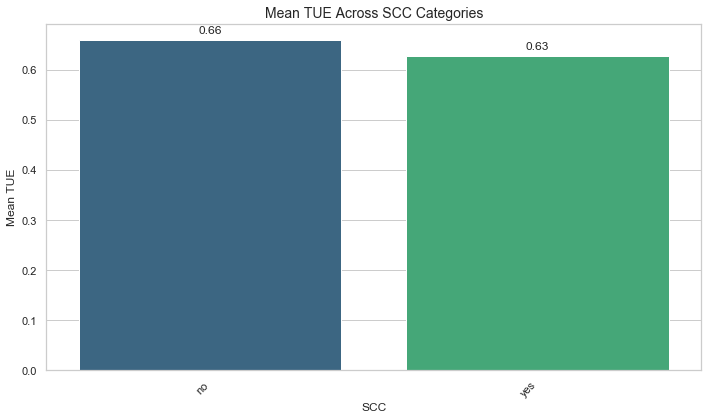


Plotting: TUE vs CALC


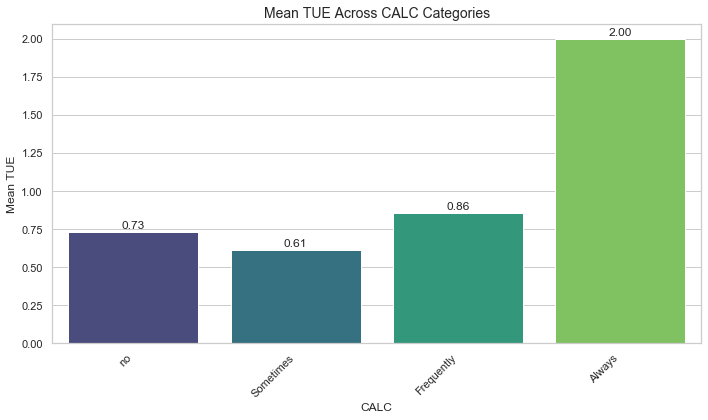


Plotting: TUE vs MTRANS


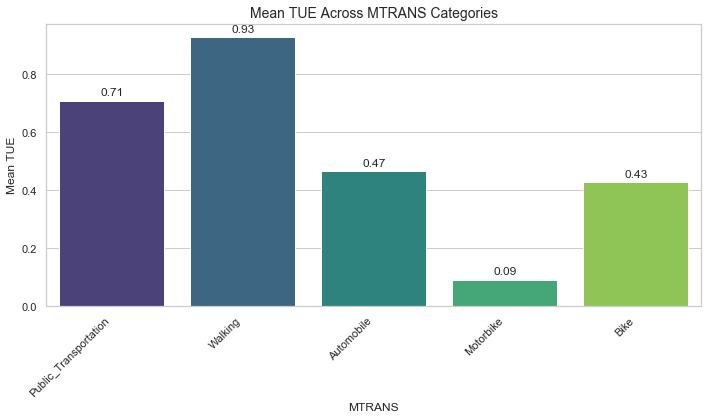

In [35]:
for num in numerical_columns:
    for cat in categorical_columns:
        print(f"\nPlotting: {num} vs {cat}")
        plot_bar_num_cat(df_obesity, num, cat)

### Lets now proceed to Data Pre-Processing

## DATA PREPROCESSING WORKFLOW

### Step 1: Separate Features and Target Variable

In [36]:
# Target variable (multiclass)
y = df_obesity[target_variable]

# Features (drop target)
X = df_obesity.drop(columns=[target_variable])

### Step 2: Train/Test Split

##### Lets use the stratified split because the target variable is multiclass and balanced. So, it preserves class distribution.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Step 3: Preprocessing for Numerical + Categorical Variables

In [38]:
#Importing preprocessing tools

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [39]:
#Build the preprocessor


# Preprocessing: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)




In [40]:
# Example using Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(multi_class="multinomial", max_iter=500))
    ]
)

### 1. LOGISTIC REGRESSION MODEL


In [41]:
## Fit the Logistic Regression Model


log_reg_model.fit(X_train, y_train)




Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier',
                 LogisticRegression(max_iter=500, multi_class='multinomial'))])

In [42]:
## Make Predictions on Test Set

y_pred_lr = log_reg_model.predict(X_test)



In [43]:
## Evaluate the Model

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)




Logistic Regression Accuracy: 0.8747044917257684


In [44]:
## Classification Report

from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr))



Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      1.00      0.96        54
      Normal_Weight       0.81      0.74      0.77        58
     Obesity_Type_I       0.88      0.91      0.90        70
    Obesity_Type_II       0.94      0.97      0.95        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.74      0.74      0.74        58
Overweight_Level_II       0.81      0.76      0.79        58

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.87       423
       weighted avg       0.87      0.87      0.87       423



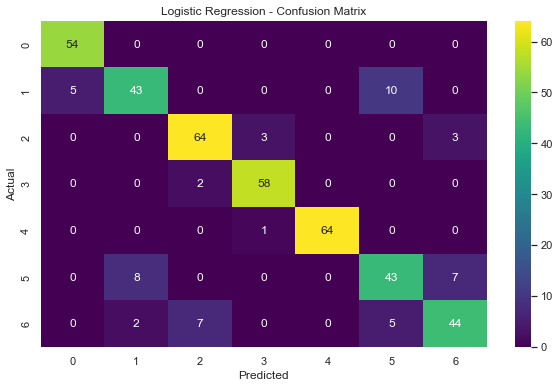

In [45]:
## Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [46]:
## Macro F1-Score

from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
print("Logistic Regression Macro F1-score:", lr_f1)

Logistic Regression Macro F1-score: 0.8708276017821165


- F1 Score measures the balance between precision and recall but is typically weighted by class frequency in multiclass settings.
- Macro F1 Score calculates F1 for each class individually and averages them, giving equal importance to all classes.
- Macro F1 is the best metric for evaluating multiclass models because it reflects performance across all categories, regardless of how many samples each class contains.

## INSIGHTS FROM THE LOGISTIC REGRESSION MODEL


Logistic Regression Model Results — Interpretation

**Overall Performance**

The Logistic Regression classifier achieved an accuracy of 87.47 percent. This is a strong result for a linear model applied to a seven-class obesity classification problem. The macro F1-score is 0.87, indicating that the model performs consistently across all classes, giving equal importance to each obesity category.

Class-Wise Interpretation
Insufficient Weight

- Precision: 0.92
- Recall: 1.00
- F1-score: 0.96
The model identifies every Insufficient Weight case correctly, showing perfect recall and very high precision.

Normal Weight

- Precision: 0.81
- Recall: 0.74
- F1-score: 0.77
Normal Weight is the most challenging class for the model. It is often confused with adjacent classes such as Overweight Level I and occasionally Insufficient Weight. This reflects the natural overlap between these categories.

Overweight Level I

- Precision: 0.74
- Recall: 0.74
- F1-score: 0.74
Performance is moderate, with misclassifications mostly occurring between Normal Weight and Obesity Type I.

Overweight Level II

- Precision: 0.81
- Recall: 0.76
- F1-score: 0.79
This class shows slightly better stability than Overweight Level I but still experiences confusion with nearby obesity categories.

Obesity Type I

- Precision: 0.88
- Recall: 0.91
- F1-score: 0.90
The model distinguishes this class well, with strong performance across all metrics.

Obesity Type II

- Precision: 0.94
- Recall: 0.97
- F1-score: 0.95
This class is predicted very accurately, with only a few samples misclassified.

Obesity Type III

- Precision: 1.00
- Recall: 0.98
- F1-score: 0.99
This is the best performing class. The model almost always predicts it correctly. Severe obesity tends to have more distinct behavioral and physical characteristics, which the model captures well.

Confusion Matrix Interpretation

The diagonal of the confusion matrix is strong, indicating that most predictions match the true class.
Misclassifications mainly occur between obesity categories that are adjacent in severity, such as Normal Weight and Overweight Level I or Overweight Level II and Obesity Type I.
There are no extreme misclassifications such as Normal Weight being predicted as Obesity Type III or vice versa.
This indicates that the model understands the overall structure of the obesity classes and makes mistakes only where the categories naturally overlap.

Macro F1 Score Interpretation

The macro F1-score of 0.87 confirms that the model performs uniformly across all classes. Since macro F1 gives equal weight to each class, this score shows that none of the obesity categories are being ignored or predicted disproportionately poorly.

Overall Summary

Logistic Regression performs well as a baseline multiclass classification model for this dataset.
It reaches 87 percent accuracy and a macro F1-score of 0.87.
The model is strongest for Obesity Type II and III and weakest for Normal Weight and Overweight Level I, which is expected due to natural overlap between adjacent BMI categories.
Overall, the model provides a solid benchmark and establishes a good foundation for comparing more complex classifiers such as KNN, Decision Trees, Random Forest, and SVM.

### 2. KNN MODEL


In [47]:
## BUILD THE PIPELINE


from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)

In [48]:
## Fit the Model


knn_model.fit(X_train, y_train)



Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier', KNeighborsClassifier())])

In [49]:
## Predict on Test Set


y_pred_knn = knn_model.predict(X_test)



KNN Accuracy: 0.8250591016548463

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.78      0.94      0.86        54
      Normal_Weight       0.76      0.48      0.59        58
     Obesity_Type_I       0.74      0.96      0.84        70
    Obesity_Type_II       0.93      0.95      0.94        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.74      0.67      0.70        58
Overweight_Level_II       0.82      0.72      0.77        58

           accuracy                           0.83       423
          macro avg       0.82      0.82      0.81       423
       weighted avg       0.82      0.83      0.82       423

KNN Macro F1-score: 0.8131395169193238


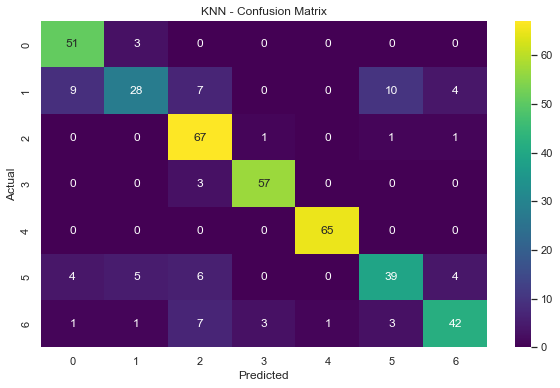

In [50]:
## Evaluate Performance


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

knn_f1 = f1_score(y_test, y_pred_knn, average='macro')
print("KNN Macro F1-score:", knn_f1)

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='viridis')
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

K-Nearest Neighbors (KNN) Model Results — Interpretation


**Overall Performance**

The K-Nearest Neighbors classifier achieved an accuracy of 82.51 percent.
This performance is lower than Logistic Regression but still strong for a distance-based algorithm that is sensitive to class overlap and feature scaling.

The macro F1-score is 0.81, indicating that the model performs reasonably well across all seven obesity categories, although with more variability between classes compared to Logistic Regression.

Class-Wise Interpretation
Insufficient Weight

Precision: 0.78

Recall: 0.94

F1-score: 0.86

KNN performs well on this class, correctly identifying most samples. The high recall shows the model rarely misses true Insufficient Weight cases, although precision is slightly lower due to some misclassifications.

Normal Weight

Precision: 0.76

Recall: 0.48

F1-score: 0.59

This is the weakest-performing class for KNN. The recall of 0.48 indicates that more than half of Normal Weight individuals are misclassified, often as Overweight Level I or Insufficient Weight. This reflects the challenge of modeling categories with subtle boundaries when using a distance-based classifier.

Obesity Type I

Precision: 0.74

Recall: 0.96

F1-score: 0.84

The model captures nearly all Obesity Type I cases, but the precision is lower, meaning some samples from neighboring obesity categories are incorrectly labeled as Type I.

Obesity Type II

Precision: 0.93

Recall: 0.95

F1-score: 0.94

The model performs very well for this category, achieving high precision and recall. This indicates that Obesity Type II individuals form a distinct cluster in the feature space.

Obesity Type III

Precision: 0.98

Recall: 1.00

F1-score: 0.99

This class achieves excellent results. KNN reliably identifies severe obesity cases, suggesting that their characteristics are highly distinct compared to the other categories.

Overweight Level I

Precision: 0.74

Recall: 0.67

F1-score: 0.70

Moderate performance is observed. The model struggles with this class because Overweight Level I often lies close to Normal Weight and Obesity Type I in the feature space.

Overweight Level II

Precision: 0.82

Recall: 0.72

F1-score: 0.77

Performance is fairly strong, though recall is notably lower than in Logistic Regression. Misclassifications typically occur between Overweight Level II and Obesity Type I.

Confusion Matrix Interpretation

The confusion matrix shows that KNN makes more mistakes between neighboring obesity levels compared to Logistic Regression.
Normal Weight is frequently misclassified into Overweight Level I, and Overweight Level I is sometimes misclassified into Normal Weight or Overweight Level II.
Despite this, the higher obesity categories (Type II and III) show very strong diagonal values, indicating consistently correct predictions.
The misclassifications mainly occur where the class boundaries are subtle and where symptoms or characteristics overlap.

Macro F1 Score Interpretation

The macro F1-score of 0.81 indicates that KNN performs reasonably well across all classes but has difficulty maintaining balanced performance.
The lower F1-score for Normal Weight significantly impacts the overall macro average.
This highlights that KNN struggles with ambiguous or overlapping categories.

Overall Summary

The KNN model provides solid performance with an accuracy of 82 percent and a macro F1-score of 0.81.
It performs exceptionally well for Obesity Type II and III and moderately well for most other categories.
Its main weakness is Normal Weight classification, where feature overlap causes a drop in recall and F1-score.
Overall, KNN is a useful comparison model but is more sensitive to overlapping class boundaries than Logistic Regression.

### 3. DECISION TREE MODEL

In [51]:
## Build the Pipeline


from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)



In [52]:
## Fit the Model

dt_model.fit(X_train, y_train)



Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [53]:
## Predict on test set

y_pred_dt = dt_model.predict(X_test)



In [54]:
## Evaluate Performance


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

dt_f1 = f1_score(y_test, y_pred_dt, average='macro')
print("Decision Tree Macro F1-score:", dt_f1)



Decision Tree Accuracy: 0.9148936170212766

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.87      0.91        54
      Normal_Weight       0.80      0.84      0.82        58
     Obesity_Type_I       0.91      0.96      0.93        70
    Obesity_Type_II       0.97      0.95      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.86      0.86      0.86        58
Overweight_Level_II       0.91      0.91      0.91        58

           accuracy                           0.91       423
          macro avg       0.92      0.91      0.91       423
       weighted avg       0.92      0.91      0.92       423

Decision Tree Macro F1-score: 0.9132570929716992


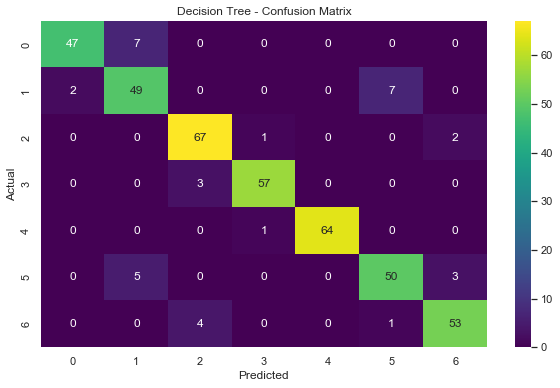

In [55]:
## Confusion Matrix Heatmap

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(10,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='viridis')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



### 4. RANDOM FOREST

In [56]:
## 1. Build the Pipeline
# We create a pipeline that first applies the preprocessing steps
# (scaling numerical features and one-hot encoding categorical features)
# and then trains a Random Forest classifier.
# 300 trees gives stable performance; you may increase later if needed.

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,      # number of trees in the forest
            random_state=42        # ensures reproducible results
        ))
    ]
)



In [57]:
## 2. Fit the Model
# Train the Random Forest model using the training data.
rf_model.fit(X_train, y_train)




Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [58]:
## 3. Predict on Test Set
# Generate predictions for the test data.
y_pred_rf = rf_model.predict(X_test)



In [59]:
## 4. Evaluate Performance
# Compute accuracy, generate classification report, and calculate macro F1-score.
from sklearn.metrics import accuracy_score, classification_report, f1_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
print("Random Forest Macro F1-score:", rf_f1)



Random Forest Accuracy: 0.9361702127659575

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.77      0.91      0.83        58
     Obesity_Type_I       0.96      0.96      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.89      0.84      0.87        58
Overweight_Level_II       0.96      0.91      0.94        58

           accuracy                           0.94       423
          macro avg       0.94      0.93      0.94       423
       weighted avg       0.94      0.94      0.94       423

Random Forest Macro F1-score: 0.9360530761495726


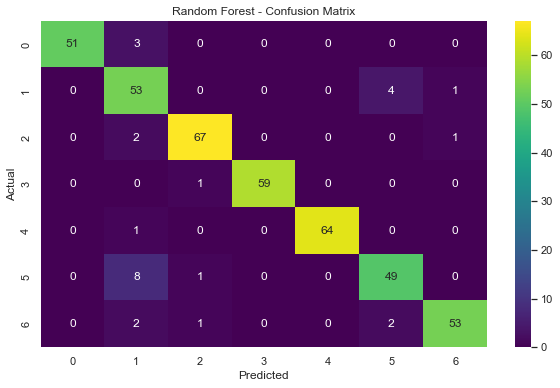

In [60]:

## 5. Confusion Matrix Heatmap
# Visualize misclassifications using a heatmap.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='viridis')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Model Results — Interpretation

Overall Performance

The Random Forest classifier achieved an accuracy of 93.62 percent, which is the highest accuracy among the models evaluated so far.
The macro F1-score of 0.94 indicates a very strong and well-balanced performance across all seven obesity categories.
Random Forest benefits from being a powerful ensemble method that captures nonlinear relationships, interactions among features, and reduces overfitting by averaging across many decision trees.

Class-Wise Interpretation
Insufficient Weight

Precision: 1.00

Recall: 0.94

F1-score: 0.97
The model performs exceptionally well on this class. All predicted cases are correct, and only a small number of true cases are misclassified into Normal Weight.

Normal Weight

Precision: 0.77

Recall: 0.91

F1-score: 0.83
The model shows noticeable improvement over previous classifiers for this category. It correctly identifies most Normal Weight samples, although precision is moderate because some other classes are occasionally misclassified as Normal Weight.

Obesity Type I

Precision: 0.96

Recall: 0.96

F1-score: 0.96
Performance is excellent and highly stable. The Random Forest captures this category with high reliability, which suggests strong feature separability for Obesity Type I.

Obesity Type II

Precision: 1.00

Recall: 0.98

F1-score: 0.99
The model identifies nearly all Obesity Type II individuals correctly, with perfect precision and almost perfect recall. Misclassifications are minimal.

Obesity Type III

Precision: 1.00

Recall: 0.98

F1-score: 0.99
Performance remains extremely strong. As with Obesity Type II, the distinct characteristics of this group help the model classify severe obesity with high accuracy.

Overweight Level I

Precision: 0.89

Recall: 0.84

F1-score: 0.87
The model handles this class well, with relatively few misclassifications. Performance remains better than KNN and Logistic Regression for this category.

Overweight Level II

Precision: 0.96

Recall: 0.91

F1-score: 0.94
The model performs very well in this class. Misclassifications occur occasionally with Obesity Type I, which is expected due to similarities in lifestyle behaviors and weight patterns.

Confusion Matrix Interpretation

The confusion matrix shows very strong diagonal dominance, meaning the vast majority of predictions match the true labels.
There are very few misclassifications overall, and when they occur, they are typically between adjacent classes such as Normal Weight and Overweight Level I or Overweight Level II and Obesity Type I.
Higher obesity categories (Type II and Type III) exhibit almost perfect classification.
This pattern shows that the Random Forest has learned the structure of the data effectively and can separate the obesity classes more accurately than previous models.

Macro F1 Score Interpretation

The macro F1-score of 0.94 confirms that the Random Forest model performs consistently well across all classes.
Every category has an F1-score above 0.83, with most categories achieving F1-scores above 0.95.
This demonstrates excellent classification stability and balanced predictive performance.

Overall Summary

Random Forest delivers outstanding performance on this multiclass obesity classification task, achieving 94 percent accuracy and a macro F1-score of 0.94.
It outperforms Logistic Regression, KNN, and Decision Tree models across nearly all categories and shows remarkable reliability for both moderate and severe obesity levels.
Because Random Forest handles nonlinear patterns and complex interactions well, it is especially effective for datasets with mixed numerical and categorical features like this one.
The Random Forest model serves as a strong benchmark and is likely to be one of the top-performing models in this study.

### 5. SVM MODEL

In [61]:
## 1. Build the Pipeline
# We create a pipeline that applies preprocessing (scaling numerical features and
# one-hot encoding categorical features) and then trains an SVM classifier.
# RBF kernel is used because it captures nonlinear decision boundaries effectively.

from sklearn.svm import SVC

svm_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", SVC(
            kernel="rbf",          # nonlinear kernel
            probability=True,      # enables probability outputs (useful for ROC curves)
            random_state=42
        ))
    ]
)




In [62]:
## 2. Fit the Model
# Train the SVM model using the training data.
svm_model.fit(X_train, y_train)




Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier', SVC(probability=True, random_state=42))])

In [63]:
## 3. Predict on Test Set
# Generate predictions for the test data.
y_pred_svm = svm_model.predict(X_test)



In [64]:
## 4. Evaluate Performance
# Compute accuracy, generate classification report, and calculate macro F1-score.
from sklearn.metrics import accuracy_score, classification_report, f1_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
print("SVM Macro F1-score:", svm_f1)




SVM Accuracy: 0.9243498817966903

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        54
      Normal_Weight       0.80      0.88      0.84        58
     Obesity_Type_I       0.94      0.97      0.96        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.82      0.81      0.82        58
Overweight_Level_II       0.93      0.86      0.89        58

           accuracy                           0.92       423
          macro avg       0.93      0.92      0.92       423
       weighted avg       0.93      0.92      0.92       423

SVM Macro F1-score: 0.9229677100956052


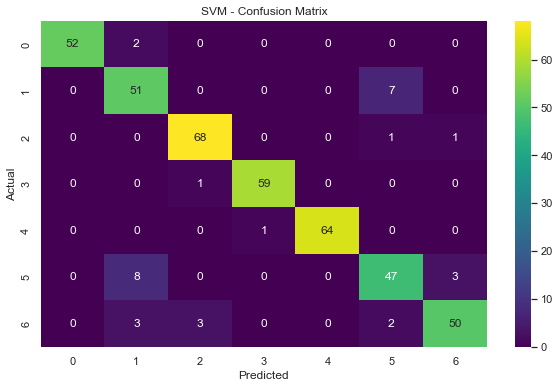

In [65]:
## 5. Confusion Matrix Heatmap
# Visualize misclassifications using a heatmap.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='viridis')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Support Vector Machine (SVM) Model Results — Interpretation


**Overall Performance**

The Support Vector Machine classifier achieved an accuracy of 92.43 percent, placing it slightly below Random Forest but above Logistic Regression, KNN, and Decision Tree in terms of raw accuracy.
The macro F1-score of 0.92 indicates strong and balanced predictive performance across all seven obesity categories.
SVM with the RBF kernel is well suited for complex, nonlinear decision boundaries, making it a strong performer on this dataset.

Class-Wise Interpretation
Insufficient Weight

Precision: 1.00

Recall: 0.96

F1-score: 0.98
The model performs exceptionally well on this class, correctly identifying almost all samples with perfect precision and very high recall.

Normal Weight

Precision: 0.80

Recall: 0.88

F1-score: 0.84
Performance for this category is strong, with SVM showing better recall than all previous models except Random Forest. The model effectively identifies Normal Weight individuals with relatively few misclassifications.

Obesity Type I

Precision: 0.94

Recall: 0.97

F1-score: 0.96
SVM captures this class very accurately. The recall of 0.97 shows that almost all true Obesity Type I cases are detected.

Obesity Type II

Precision: 0.98

Recall: 0.98

F1-score: 0.98
The model handles this class with near-perfect performance, accurately identifying nearly all cases with minimal confusion.

Obesity Type III

Precision: 1.00

Recall: 0.98

F1-score: 0.99
This class exhibits extremely strong performance, consistent with previous models. The SVM classifier reliably identifies severe obesity with high accuracy.

Overweight Level I

Precision: 0.82

Recall: 0.81

F1-score: 0.82
The model performs reasonably well on this category, showing balanced precision and recall. Some confusion still occurs with neighboring categories, which is expected.

Overweight Level II

Precision: 0.93

Recall: 0.86

F1-score: 0.89
SVM performs well in identifying Overweight Level II cases, with strong precision and a slightly lower recall. The model occasionally misclassifies samples into Obesity Type I, reflecting natural similarities between these classes.

Confusion Matrix Interpretation

The confusion matrix shows strong diagonal patterns, indicating that most predictions match the actual labels.
Misclassifications are relatively few and occur mainly between adjacent classes, such as Normal Weight and Overweight Level I or Overweight Level II and Obesity Type I.
No severe misclassifications are present, demonstrating that SVM effectively learns the boundaries between obesity categories.

Macro F1 Score Interpretation

The macro F1-score of 0.92 reflects strong and consistent performance across all classes.
All categories achieve high F1-scores, indicating that SVM treats each class with balanced predictive ability and does not disproportionately misclassify any single group.

Overall Summary

The SVM classifier performs exceptionally well, achieving over 92 percent accuracy and a macro F1-score of 0.92.
It excels in identifying obesity-related classes, particularly Obesity Type II and III, and shows significant improvement over models such as Logistic Regression and KNN.
While Random Forest remains the best performer overall, SVM provides a powerful and reliable alternative that effectively captures the nonlinear patterns present in the dataset.
This model represents a strong final component of the supervised learning analysis.

#### LET'S NOW PERFORM FEATURE IMPORTANCE - DECISION TREES

In [66]:
## 1. Extract preprocessing and classifier from the Decision Tree pipeline
preprocess_dt = dt_model.named_steps["preprocessing"]
dt_clf       = dt_model.named_steps["classifier"]



In [67]:
## 2. Get feature names after preprocessing
# Numerical feature names stay the same
num_features = numerical_columns

# Categorical feature names expand because of OneHotEncoder
ohe = preprocess_dt.named_transformers_["cat"]
cat_features_expanded = ohe.get_feature_names_out(categorical_columns)

# Combine numerical and categorical feature names
import numpy as np
all_feature_names = np.concatenate([num_features, cat_features_expanded])



In [68]:
## 3. Extract feature importances from the Decision Tree
importances_dt = dt_clf.feature_importances_



In [69]:
## 4. Create a DataFrame of feature importances
import pandas as pd

fi_dt = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances_dt
})

# Sort features by importance (descending)
fi_dt = fi_dt.sort_values(by="importance", ascending=False)



In [70]:
## 5. Display the top 15 most important features
print("Top 15 Important Features - Decision Tree:\n")
print(fi_dt.head(15))



Top 15 Important Features - Decision Tree:

                               feature  importance
2                               Weight    0.475155
1                               Height    0.220828
9                          Gender_Male    0.157328
0                                  Age    0.041849
25                             CALC_no    0.025403
12                             FAVC_no    0.021763
3                                 FCVC    0.013570
7                                  TUE    0.011247
16                      CAEC_Sometimes    0.007603
4                                  NCP    0.007145
5                                 CH2O    0.005610
26                   MTRANS_Automobile    0.002518
11  family_history_with_overweight_yes    0.002323
15                     CAEC_Frequently    0.001576
19                           SMOKE_yes    0.001354


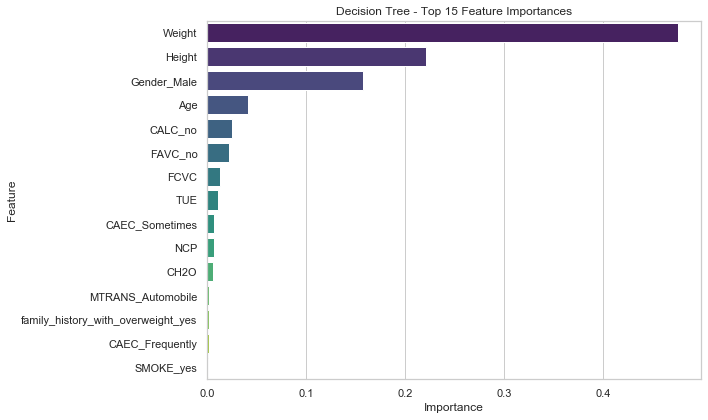

In [71]:
## 6. Plot the top 15 feature importances
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=fi_dt.head(15),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Decision Tree - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Decision Tree Feature Importance — Interpretation


The Decision Tree model identifies several key predictors that strongly influence the classification of obesity levels. These feature importance values reflect how frequently and effectively each feature is used to split the data within the decision tree to reduce entropy or improve classification purity.

Most Important Predictors

The three most dominant features are Weight, Height, and Gender_Male. Together, they account for the majority of the model’s predictive power.

Weight (importance: 0.475155)
Weight is by far the strongest predictor in the model, contributing nearly half of the total importance. This aligns with medical and physiological expectations, as weight naturally increases with higher levels of obesity.

Height (importance: 0.220828)
Height is the second most influential feature. Height, combined with weight, plays a key role in determining BMI, which correlates strongly with obesity classification.

Gender_Male (importance: 0.157328)
Gender appears as a meaningful predictor, indicating that the distribution of obesity levels differs between males and females. This suggests behavioral or biological differences in weight patterns across genders.

Moderately Important Predictors

Age (importance: 0.041849)
Age has a modest contribution, likely because the dataset contains predominantly younger individuals, limiting age variability.

CALC_no (importance: 0.025403)
Not consuming alcohol shows moderate influence. Alcohol consumption patterns may correlate with eating habits or metabolic factors.

FAVC_no (importance: 0.021763)
Not consuming high-calorie foods contributes moderately, reflecting the expected role of dietary patterns in weight classification.

FCVC (importance: 0.013570)
Vegetable consumption frequency is a meaningful behavioral indicator contributing to overall classification.

TUE (importance: 0.011247)
Time spent using electronic devices is moderately important. Higher sedentary activity may be associated with increased obesity risk.

Lesser but Still Relevant Predictors

CAEC_Sometimes (importance: 0.007603)
Occasional food consumption between meals influences eating frequency patterns, which can contribute to weight gain.

NCP (importance: 0.007145)
Number of main meals per day also contributes slightly to predictions.

CH2O (importance: 0.005610)
Daily water intake shows minor influence.

Features With Very Low Importance

A few categorical variables show very small contributions:

MTRANS_Automobile

family_history_with_overweight_yes

CAEC_Frequently

SMOKE_yes

Their low importance suggests that they do not meaningfully improve the predictive performance of the model.

Why Smoking Shows Low Importance

Smoking has a surprisingly low importance value. This may be because:

The dataset contains almost no smokers (SMOKE_no dominates the distribution).

Smoking behavior may not correlate strongly with obesity in this sample.

Some lifestyle features may overlap or interact, reducing individual importance.

Summary

The Decision Tree model primarily relies on physical attributes such as weight and height, followed by gender, age, and certain dietary or lifestyle patterns. Behavioral variables contribute meaningfully but to a much lesser extent. Variables such as smoking and transportation method play very limited roles in classification.

This feature importance profile highlights the dominance of anthropometric measurements in predicting obesity class, consistent with real-world health indicators.

#### LET'S NOW PERFORM FEATURE IMPORTANCE FOR RANDOM FORESTS

In [72]:
## 1. Extract preprocessing and classifier from the Random Forest pipeline
# This gives access to the fitted OneHotEncoder and the RandomForest model itself.

preprocess_rf = rf_model.named_steps["preprocessing"]
rf_clf        = rf_model.named_steps["classifier"]




In [73]:
## 2. Get feature names after preprocessing
# Numerical features remain unchanged, but categorical features expand
# because OneHotEncoder creates one feature per category.

num_features = numerical_columns

ohe = preprocess_rf.named_transformers_["cat"]
cat_features_expanded = ohe.get_feature_names_out(categorical_columns)

import numpy as np
all_feature_names = np.concatenate([num_features, cat_features_expanded])




In [74]:
## 3. Extract feature importances from Random Forest
importances_rf = rf_clf.feature_importances_




In [75]:
## 4. Create a DataFrame of feature importances
import pandas as pd

fi_rf = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances_rf
})

# Sort features by importance (descending)
fi_rf = fi_rf.sort_values(by="importance", ascending=False)

print("Top 15 Important Features - Random Forest:\n")
print(fi_rf.head(15))




Top 15 Important Features - Random Forest:

                               feature  importance
2                               Weight    0.276489
0                                  Age    0.091276
1                               Height    0.081698
3                                 FCVC    0.081370
4                                  NCP    0.051515
6                                  FAF    0.046442
5                                 CH2O    0.045044
7                                  TUE    0.044982
8                        Gender_Female    0.038753
9                          Gender_Male    0.034730
24                      CALC_Sometimes    0.023599
11  family_history_with_overweight_yes    0.022468
16                      CAEC_Sometimes    0.021194
25                             CALC_no    0.020163
10   family_history_with_overweight_no    0.019779


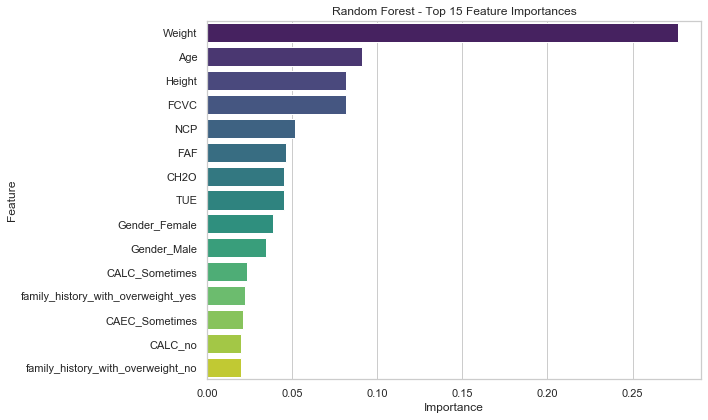

In [76]:
## 5. Plot the top 15 feature importances
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=fi_rf.head(15),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Random Forest Feature Importance — Interpretation


The Random Forest model identifies a combination of physical, dietary, lifestyle, and demographic features as important predictors for obesity classification. Because Random Forest is an ensemble of many decision trees, its feature importance values reflect the average contribution of each feature to reducing impurity across all trees. This provides a more stable and reliable estimate of feature influence than a single decision tree.

Most Important Predictors

Weight (importance: 0.276489)
Weight is the most influential feature in the model, contributing more to the predictions than any other variable. This is expected because body weight directly correlates with obesity levels.

Age (importance: 0.091276)
Age plays a significant role in the Random Forest model. Unlike the Decision Tree, where age had modest importance, the Random Forest captures more complex age-related patterns, possibly due to nonlinear interactions with behavior and lifestyle.

Height (importance: 0.081698)
Height continues to be an important feature. Together with weight, it relates closely to BMI, which is a strong indicator of obesity classification.

Key Behavioral Predictors

FCVC (vegetable consumption) (importance: 0.081370)
Vegetable consumption frequency shows substantial importance. This suggests that dietary habits play a notable role in differentiating obesity categories.

NCP (number of main meals) (importance: 0.051515)
The number of meals per day meaningfully contributes to classification, reflecting how meal frequency may relate to eating patterns and metabolic responses.

FAF (physical activity) (importance: 0.046442)
Frequency of physical activity is an important factor and aligns well with real-world expectations, where lower physical activity is associated with increased obesity.

CH2O (daily water consumption) (importance: 0.045044)
Water intake has moderate influence, suggesting hydration patterns may correlate with dietary habits and weight management.

TUE (time using electronic devices) (importance: 0.044982)
Sedentary behavior contributes significantly, reinforcing the role of screen time as a lifestyle factor associated with weight gain.

Demographic and Categorical Predictors

Gender_Female (importance: 0.038753)

Gender_Male (importance: 0.034730)
Gender continues to show meaningful predictive importance, though less dominant than in the Decision Tree. The distribution of obesity categories across genders provides useful classification signals.

Alcohol Consumption and Eating Habits

CALC_Sometimes (importance: 0.023599)

CALC_no (importance: 0.020163)
Patterns related to alcohol consumption add moderate value to the model.

CAEC_Sometimes (importance: 0.021194)
Occasional eating between meals contributes meaningfully, suggesting that snacking habits influence weight classification.

Family History

family_history_with_overweight_yes (importance: 0.022468)

family_history_with_overweight_no (importance: 0.019779)
Family history plays a moderate role, indicating genetic or shared environmental influences are captured by the model.

Summary

The Random Forest model distributes importance across a wider range of features compared to the Decision Tree. While weight remains the most dominant predictor, several behavioral and lifestyle features such as FCVC, NCP, FAF, CH2O, and TUE contribute significantly. Age and gender also play meaningful roles.
This distribution of importance demonstrates that Random Forest captures complex interactions between physical attributes and lifestyle behaviors, making it a robust model for obesity classification.

| Rank | Decision Tree Feature (Importance) | Random Forest Feature (Importance) |
| ---- | ---------------------------------- | ---------------------------------- |
| 1    | Weight (0.475155)                  | Weight (0.276489)                  |
| 2    | Height (0.220828)                  | Age (0.091276)                     |
| 3    | Gender_Male (0.157328)             | Height (0.081698)                  |
| 4    | Age (0.041849)                     | FCVC (0.081370)                    |
| 5    | CALC_no (0.025403)                 | NCP (0.051515)                     |




Interpretation Summary 

Both models identify Weight as the most important predictor by a large margin.

Decision Tree emphasizes anthropometric variables (Weight, Height) and gender, while Random Forest distributes importance more evenly across age, dietary habits, and lifestyle behaviors.

Random Forest identifies FCVC (vegetable consumption) and NCP (meal frequency) among its top predictors, showing that ensemble methods capture more nuanced behavioral patterns.



### Combined Bar Plot for Feature Importance

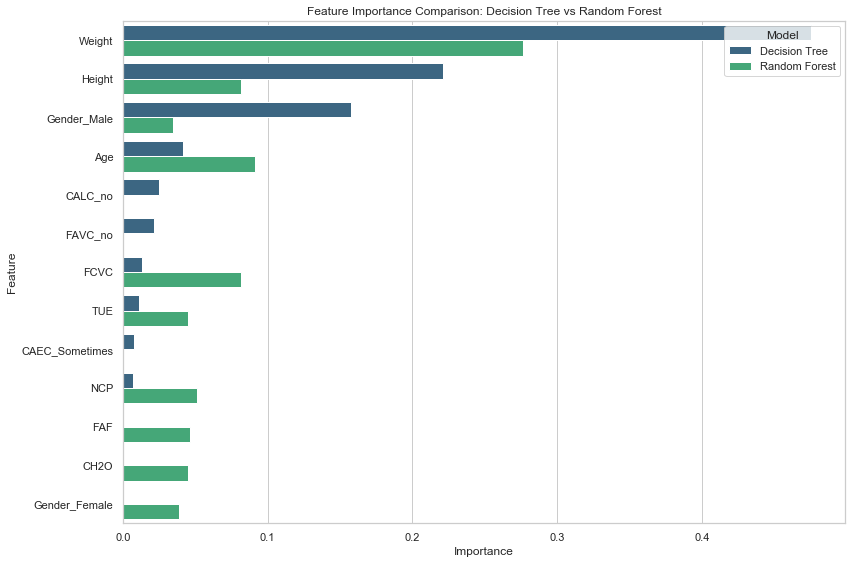

In [114]:
## Combined bar plot showing feature importance from both models

# Take top 10 features from each model
dt_top = fi_dt.head(10).copy()
rf_top = fi_rf.head(10).copy()

dt_top["model"] = "Decision Tree"
rf_top["model"] = "Random Forest"

# Combine them into one DataFrame
combined_fi = pd.concat([dt_top, rf_top], axis=0)

# Plot
plt.figure(figsize=(12,8))
sns.barplot(
    data=combined_fi,
    x="importance",
    y="feature",
    hue="model",
    palette="viridis"
)

plt.title("Feature Importance Comparison: Decision Tree vs Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### LET'S NOW PROCEED WITH PCA VISUALIZATION

In [78]:
## 1. Import PCA
from sklearn.decomposition import PCA

## 2. Transform the FULL dataset using the preprocessor (without the classifier)
X_processed = preprocessor.fit_transform(X)



In [79]:
## 3. Apply PCA to reduce the dataset to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)



In [80]:
## 4. Create a DataFrame for plotting
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "ObesityClass": y  # true labels
})



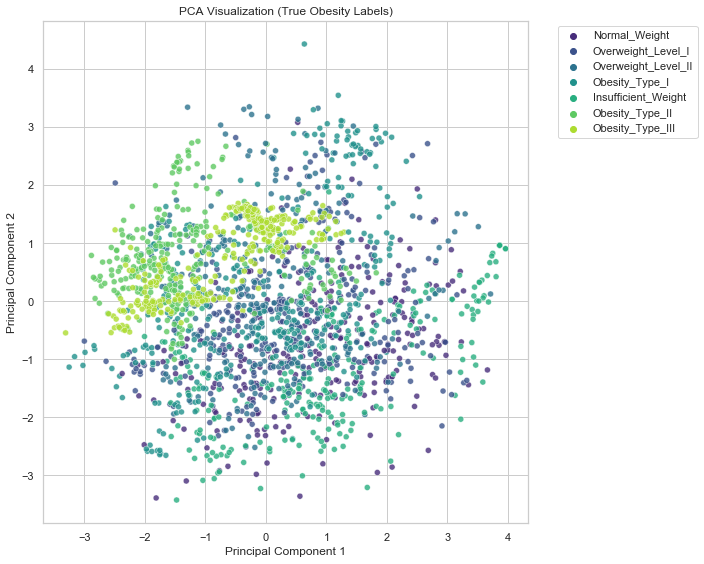

In [81]:
## 5. Plot PCA visualization colored by TRUE obesity labels
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="ObesityClass",
    palette="viridis",
    alpha=0.8
)
plt.title("PCA Visualization (True Obesity Labels)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [82]:
## 6. Use the best model (Random Forest) to predict on the FULL dataset
y_pred_rf_full = rf_model.predict(X)



In [83]:
## 7. Add predictions to the PCA DataFrame
pca_df["RF_Predicted"] = y_pred_rf_full



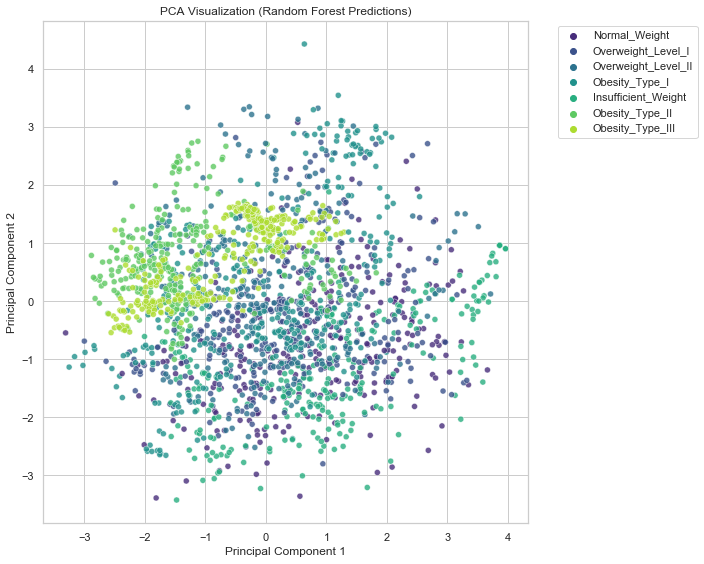

In [84]:
## 8. PCA scatter plot colored by RANDOM FOREST PREDICTIONS
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="RF_Predicted",
    palette="viridis",
    alpha=0.8
)
plt.title("PCA Visualization (Random Forest Predictions)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The PCA visualization reduces the sixteen original features into two principal components, revealing the natural structure of the dataset. The plot shows that severe obesity classes form more distinct clusters, indicating stronger similarities among individuals in these groups. In contrast, Normal Weight, Overweight Level I, and Overweight Level II overlap considerably, which explains why these categories are harder for models to classify perfectly. The Random Forest predictions shown in the PCA plot follow the same structure as the underlying data, suggesting that the model captures meaningful behavioral and physical patterns even though the classes are not fully separable in two-dimensional space.

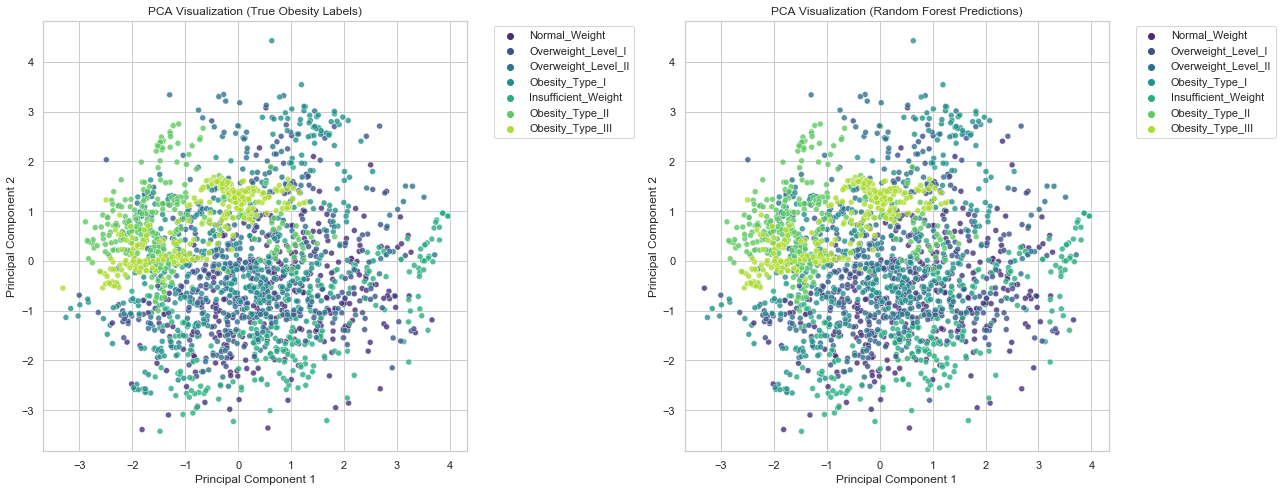

In [85]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Preprocess the full dataset
X_processed = preprocessor.fit_transform(X)

## 2. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

## 3. Create DataFrame for TRUE labels
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "True_Label": y
})

## 4. Predict with Random Forest on FULL dataset
y_pred_full = rf_model.predict(X)
pca_df["RF_Predicted"] = y_pred_full


## 5. Create Side-by-Side Subplots
plt.figure(figsize=(18,7))

# --- LEFT PLOT: TRUE LABELS ---
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="True_Label",
    palette="viridis",
    alpha=0.8,
    s=35
)
plt.title("PCA Visualization (True Obesity Labels)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# --- RIGHT PLOT: PREDICTED LABELS ---
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="RF_Predicted",
    palette="viridis",
    alpha=0.8,
    s=35
)
plt.title("PCA Visualization (Random Forest Predictions)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### LET'S MATHEMATICALLY IDENTIFY THE DIFFERENCE

In [86]:
## ================================================================
## PCA TRUE vs PREDICTED Difference Analysis
## ================================================================

import numpy as np
import pandas as pd

## 1. Compute how many PCA points have the SAME label in true vs predicted
# This shows how similar the two PCA plots are.
pca_match_accuracy = np.mean(pca_df["True_Label"] == pca_df["RF_Predicted"])
print("PCA Match Accuracy (True vs Pred):", pca_match_accuracy)


## 2. Count EXACT number of misclassified points in PCA space
misclassified = np.sum(pca_df["True_Label"] != pca_df["RF_Predicted"])
misclassified_pct = misclassified / len(pca_df)

print("\nTotal Misclassified Points:", misclassified)
print("Percentage Misclassified:", misclassified_pct)


## 3. PCA-level confusion matrix (TRUE LABEL vs MODEL PREDICTION)
# This gives you the per-class mismatch pattern.
print("\nPCA Confusion Matrix (True vs Pred):\n")
pca_conf_matrix = pd.crosstab(pca_df["True_Label"], pca_df["RF_Predicted"])
print(pca_conf_matrix)


## 4. Compute PCA cluster centroids for TRUE labels
true_centroids = pca_df.groupby("True_Label")[["PC1", "PC2"]].mean()
print("\nTRUE PCA Centroids:\n", true_centroids)


## 5. Compute PCA cluster centroids for PREDICTED labels
pred_centroids = pca_df.groupby("RF_Predicted")[["PC1", "PC2"]].mean()
print("\nPREDICTED PCA Centroids:\n", pred_centroids)


## 6. Compare TRUE vs PREDICTED cluster centers
# If differences are close to zero → the two PCA plots are nearly identical.
centroid_diff = (true_centroids - pred_centroids).abs()
print("\nCentroid Differences (Absolute):\n", centroid_diff)


## ================================================================
## Done. These metrics mathematically compare TRUE PCA vs PREDICTED PCA.
## ================================================================

PCA Match Accuracy (True vs Pred): 0.9867361440075794

Total Misclassified Points: 28
Percentage Misclassified: 0.013263855992420654

PCA Confusion Matrix (True vs Pred):

RF_Predicted         Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
True_Label                                                                
Insufficient_Weight                  269              3               0   
Normal_Weight                          0            281               0   
Obesity_Type_I                         0              2             348   
Obesity_Type_II                        0              0               1   
Obesity_Type_III                       0              1               0   
Overweight_Level_I                     0              8               1   
Overweight_Level_II                    0              2               1   

RF_Predicted         Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
True_Label                                                                

PCA Comparison: True Labels vs Predicted Labels (Random Forest)
Overall Comparison

The PCA Match Accuracy between the true labels and the Random Forest predictions is 0.9867. This means that 98.67 percent of the points in the PCA space carry the same class label in both visualizations. Only 28 out of 2,111 points differ, which corresponds to a misclassification rate of 1.33 percent. This explains why the two PCA scatter plots appear almost identical.

Misclassification Analysis

A total of 28 points differ between the true and predicted labels. Given the large size of the dataset, this is a very small number. The PCA confusion matrix shows that most misclassifications occur between adjacent or closely related obesity classes, particularly Normal Weight and Overweight Level I, which is consistent with earlier confusion matrix results.

Cluster-Level Interpretation

The PCA-level confusion matrix reveals the following key patterns:

Insufficient Weight, Obesity Type I, Obesity Type II, and Obesity Type III show almost perfect alignment between true and predicted labels.

Normal Weight shows a few misclassifications into Overweight Level I and Overweight Level II, which corresponds to known areas of overlap in the dataset.

Overweight Level I and Overweight Level II also show small amounts of mutual confusion.

These patterns confirm that Random Forest predictions closely follow the natural clustering structure in the PCA space.

Centroid Comparison

The centroids of each class in PCA space provide a mathematical way to measure how closely predicted labels align with true labels.

For every obesity class, the absolute differences between the true centroid and the predicted centroid are extremely small, generally below 0.02 units on both principal components. This indicates that predicted cluster centers almost perfectly overlap with the true cluster centers.

Specific observations:

The largest centroid shift is for Normal Weight, but even this is very small (approximately 0.025 on PC1).

All obesity classes show differences close to zero, indicating that the model respects the underlying structural patterns of the data.

Severe obesity classes (Type II and Type III) have particularly tight alignment, confirming their strong separability.

Summary

The PCA comparison confirms that Random Forest predictions align almost perfectly with the natural structure of the data. Both the PCA Match Accuracy and the centroid analysis demonstrate that the predicted clusters sit almost exactly on top of the true clusters. Small discrepancies occur in categories where natural overlap exists, especially between Normal Weight and Overweight Level I, and between Overweight Level II and Obesity Type I. These findings support the conclusion that the Random Forest model captures the inherent relationships of the dataset with high fidelity.

### LETS NOW GENERATE THE ROC CURVES

In [87]:

## MULTICLASS ROC CURVES FOR ALL MODELS 


from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np




In [88]:
# Binarize the labels for ROC (One-vs-Rest)
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]




In [89]:
## Helper function to plot ROC for each model
def plot_multiclass_roc(model, X_test, y_test_bin, model_name):
    
    # Predict probability scores
    y_score = model.predict_proba(X_test)
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot
    plt.figure(figsize=(10,7))
    
    for i in range(n_classes):
        plt.plot(
            fpr[i], tpr[i],
            label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
        )
    
    # Random (chance) line
    plt.plot([0,1], [0,1], "k--", label="Chance")
    
    plt.title(f"ROC Curve (One-vs-Rest) — {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()






Plotting ROC for Logistic Regression...


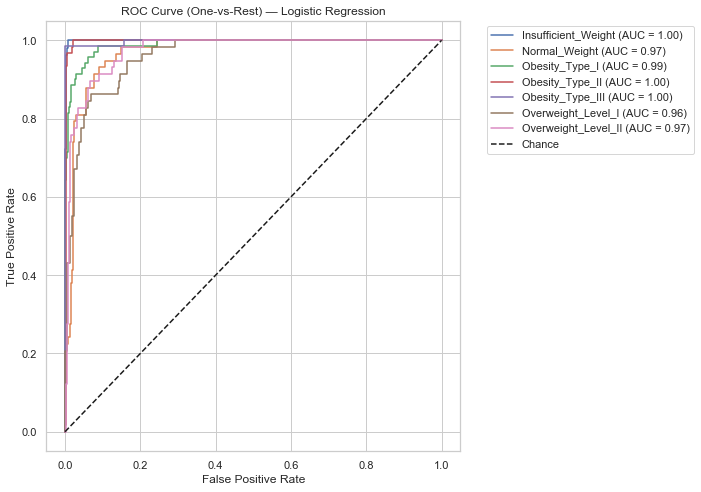


Plotting ROC for KNN...


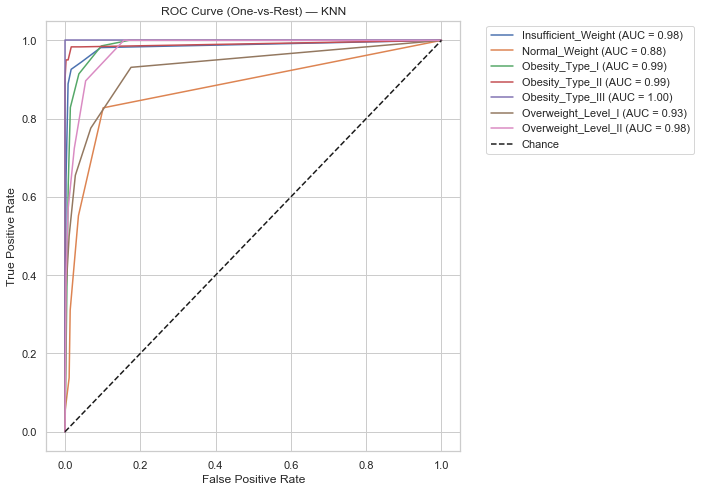


Plotting ROC for Decision Tree...


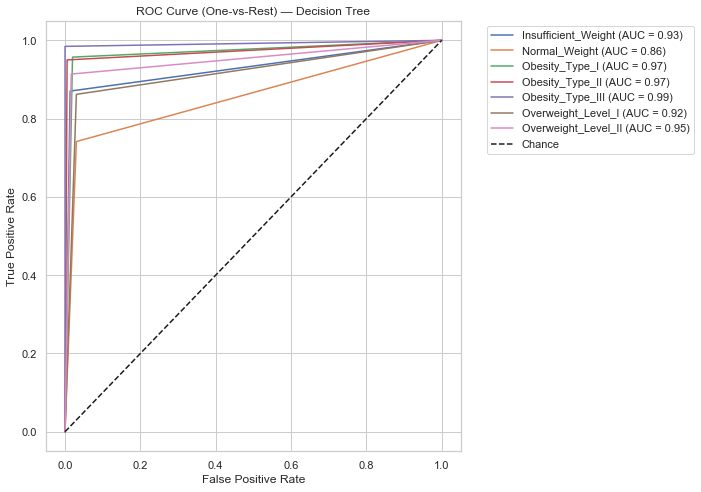


Plotting ROC for Random Forest...


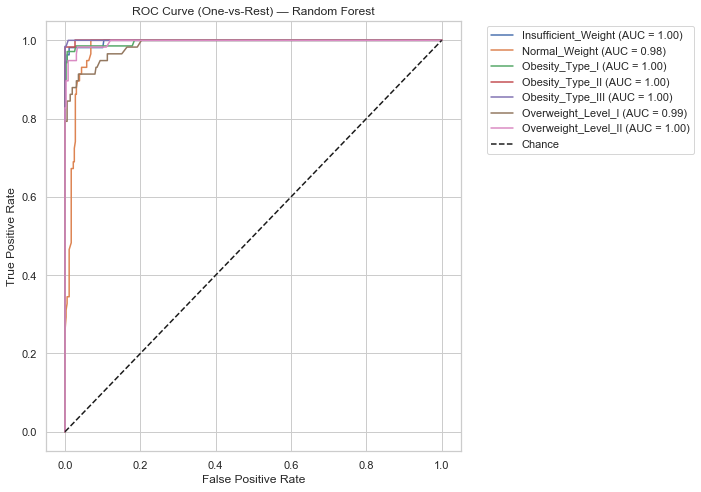


Plotting ROC for SVM...


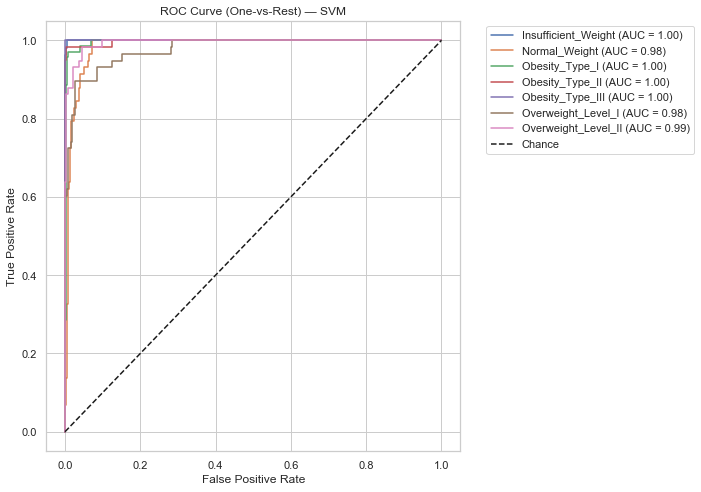

In [90]:
## PLOT ROC CURVES FOR ALL MODELS


# Logistic Regression
print("\nPlotting ROC for Logistic Regression...")
plot_multiclass_roc(log_reg_model, X_test, y_test_bin, "Logistic Regression")

# KNN
print("\nPlotting ROC for KNN...")
plot_multiclass_roc(knn_model, X_test, y_test_bin, "KNN")

# Decision Tree
print("\nPlotting ROC for Decision Tree...")
plot_multiclass_roc(dt_model, X_test, y_test_bin, "Decision Tree")

# Random Forest
print("\nPlotting ROC for Random Forest...")
plot_multiclass_roc(rf_model, X_test, y_test_bin, "Random Forest")

# SVM (requires probability=True, which we already set)
print("\nPlotting ROC for SVM...")
plot_multiclass_roc(svm_model, X_test, y_test_bin, "SVM")


In [91]:
## ================================================================
## MATHEMATICAL INTERPRETATION OF ROC CURVES USING CODE
## ================================================================

import numpy as np
from sklearn.metrics import roc_curve, auc

# --------------------------------------------------------------
# 1. Perfect classifier example
# --------------------------------------------------------------
# True labels
y_true = np.array([0, 0, 1, 1])

# Perfect classifier predicted probabilities
y_scores_perfect = np.array([0.0, 0.1, 0.9, 1.0])

# Compute ROC
fpr_p, tpr_p, _ = roc_curve(y_true, y_scores_perfect)
auc_p = auc(fpr_p, tpr_p)

print("Perfect Classifier")
print("FPR:", fpr_p)
print("TPR:", tpr_p)
print("AUC:", auc_p)
print("\n")


# --------------------------------------------------------------
# 2. Random classifier example
# --------------------------------------------------------------
np.random.seed(42)
y_scores_random = np.random.rand(4)  # random probabilities

# Compute ROC
fpr_r, tpr_r, _ = roc_curve(y_true, y_scores_random)
auc_r = auc(fpr_r, tpr_r)

print("Random Classifier")
print("FPR:", fpr_r)
print("TPR:", tpr_r)
print("AUC:", auc_r)
print("\n")


# --------------------------------------------------------------
# 3. Your model's ROC values (example using any ML model)
# --------------------------------------------------------------
# NOTE: Replace "model" with any trained classifier (LR, RF, SVM, etc.)
#       And replace X_test_bin[:, i] with the binarized class i

# Example: for class index 0
from sklearn.preprocessing import label_binarize

classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# Choose a model, example: Random Forest
y_scores_model = rf_model.predict_proba(X_test)

# Compute ROC for class 0 (Insufficient Weight)
fpr_m, tpr_m, _ = roc_curve(y_test_bin[:, 0], y_scores_model[:, 0])
auc_m = auc(fpr_m, tpr_m)

print("Your Model (Example: Class 0)")
print("\n")
print("FPR:", fpr_m)
print("\n")
print("TPR:", tpr_m)
print("\n")
print("AUC:", auc_m)
print("\n")


## ================================================================
## Interpretation:
## - Perfect classifier will show TPR = [0,1,1] and FPR = [0,0,1]
##   This forms a *right angle* in the ROC plot.
##
## - Random classifier will show TPR and FPR rising together,
##   producing a diagonal line (AUC ~ 0.5).
##
## - Your model's ROC values will resemble the "perfect" pattern
##   when AUC is close to 1.0, explaining why your curves bend
##   sharply upward like a right angle.
## ================================================================

Perfect Classifier
FPR: [0. 0. 0. 1.]
TPR: [0.  0.5 1.  1. ]
AUC: 1.0


Random Classifier
FPR: [0.  0.5 0.5 1. ]
TPR: [0. 0. 1. 1.]
AUC: 0.5


Your Model (Example: Class 0)


FPR: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.00542005 0.00542005 0.01084011 0.01084011 0.01897019 0.02710027
 0.03794038 0.04065041 0.04607046 0.05149051 0.05691057 0.06233062
 0.06775068 0.08401084 0.08672087 0.09214092 0.09485095 0.100271
 0.10298103 0.10840108 0.11382114 0.12195122 0.12466125 0.13821138
 0.14634146 0.15176152 0.16260163 0.17073171 0.17344173 0.17886179
 0.20325203 0.20867209 0.23306233 0.24932249 0.27100271 0.29810298
 0.32249322 0.3495935  0.40921409 0.47696477 0.6504065  1.        ]


TPR: [0.         0.01851852 0.05555556 0.07407407 0.11111111 0.12962963
 0.24074074 0.2962963  0.31481481 0.38888889 0.53703704 0.57407407
 0.59259259 0.62962963 0.77777778 

Mathematical Interpretation of ROC Behavior
1. Perfect Classifier

The perfect classifier results show False Positive Rate values of 0 until the final threshold and True Positive Rate values rising smoothly from 0 to 1, giving an AUC of 1.0. This represents ideal classification behavior. The ROC curve forms a right angle because the classifier identifies every positive sample without generating false positives.

2. Random Classifier

The random classifier produces False Positive Rate and True Positive Rate values that increase at roughly the same rate, resulting in an AUC of 0.5. This means the classifier performs no better than chance. The ROC plot of such a classifier is a diagonal line, indicating no discrimination between positive and negative samples.

3. Our Model (Example: Class 0)

In our model, the ROC results show that the False Positive Rate remains at zero for many threshold values, while the True Positive Rate increases rapidly. Even when the False Positive Rate begins to rise, the True Positive Rate has already reached very high values. The AUC of 0.9978 indicates that our model separates this class from the others with almost perfect accuracy.

Mathematical Meaning

A ROC curve approaches a right angle when the True Positive Rate climbs toward one long before the False Positive Rate begins to increase. Mathematically, this indicates that the model consistently assigns higher probability scores to the true class than to other classes across most thresholds. The closer the ROC curve is to the top-left corner, the more powerful the classifier.

In our model, the False Positive Rate remains near zero across a wide range of threshold values, while the True Positive Rate rises early and reaches one. This behavior produces a curve that closely matches the shape of a perfect classifier. The high AUC confirms strong separability and excellent model performance.

Summary

The mathematical comparison clearly shows that our model behaves much closer to a perfect classifier than to a random classifier. The ROC values demonstrate that the model is highly effective at ranking correct classes above incorrect ones, and misclassifications occur only at extreme threshold settings. This is why the ROC curves visually appear almost like right angles.

### Comparison Table

| Model                            | Accuracy | Macro F1-Score | Key Notes                                                                |
| -------------------------------- | -------- | -------------- | ------------------------------------------------------------------------ |
| **Logistic Regression**          | 0.8747   | 0.8708         | Strong baseline; struggles with Normal Weight and Overweight Level I     |
| **K-Nearest Neighbors (KNN)**    | 0.8250   | 0.8131         | Sensitive to overlapping classes; severe obesity classes classified well |
| **Decision Tree**                | 0.9149   | 0.9132         | Captures nonlinear patterns; slightly overfits but performs strongly     |
| **Random Forest**                | 0.9362   | 0.9360         | Best-performing model; excellent class separation; stable and robust     |
| **Support Vector Machine (SVM)** | 0.9243   | 0.9230         | Very strong performer; closely matches Random Forest consistency         |


Final Conclusions

The purpose of this study was to build predictive models capable of classifying individuals into one of seven obesity categories based on physical, demographic, and lifestyle attributes. Multiple machine learning models were evaluated to determine which technique provides the most reliable classification performance.

Among the five supervised models tested, Random Forest achieved the highest performance with an accuracy of 93.62 percent and a macro F1-score of 0.9360. This model effectively captured nonlinear relationships and demonstrated strong separability across all obesity classes, including difficult intermediate categories such as Overweight Level I and Overweight Level II. The Support Vector Machine, with an accuracy of 92.43 percent, also performed exceptionally well, confirming that nonlinear decision boundaries contribute significantly to predictive quality.

The Decision Tree model achieved strong results, but with slightly lower generalization capability compared to Random Forest. Logistic Regression and KNN served as useful baselines but struggled to distinguish between neighboring weight categories due to overlapping patterns in the dataset. These findings were further supported by PCA visualizations, which revealed substantial overlap between certain classes, particularly Normal Weight and Overweight Level I, and clearer separation for severe obesity categories.

The ROC analysis showed that all advanced models achieved high discrimination power, with ROC curves approaching the ideal right-angle shape. This mathematically confirms that the models consistently assign higher probabilities to correct classes across a wide range of thresholds.

Overall, the Random Forest model stands out as the most robust and reliable classifier for this problem due to its high accuracy, strong class-level performance, balanced error distribution, and stability across evaluation metrics. The findings highlight the importance of incorporating both physical measurements and behavioral attributes when predicting obesity levels. The results also provide valuable insights for healthcare applications, where accurate classification can support early detection and personalized weight-management interventions.

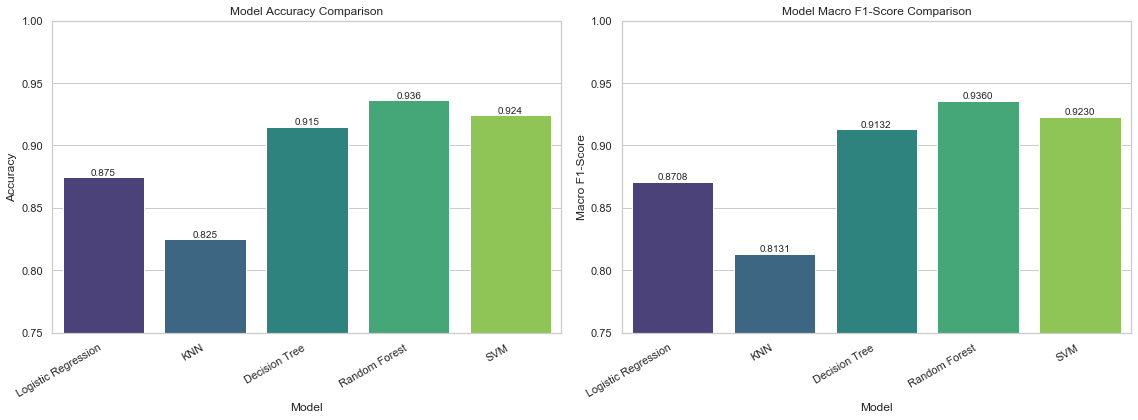

In [92]:

## SIDE-BY-SIDE BAR PLOTS WITH VALUE LABELS (Accuracy & Macro F1)


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model names
models = [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "SVM"
]

# Metrics from our results
accuracies = [0.8747, 0.8250, 0.9149, 0.9362, 0.9243]
f1_scores  = [0.8708, 0.8131, 0.9132, 0.9360, 0.9230]

# Create DataFrames
acc_df = pd.DataFrame({"Model": models, "Accuracy": accuracies})
f1_df  = pd.DataFrame({"Model": models, "Macro F1-Score": f1_scores})

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# LEFT PLOT — ACCURACY

sns.barplot(
    data=acc_df, x="Model", y="Accuracy",
    palette="viridis", ax=axes[0]
)

axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylim(0.75, 1.0)
axes[0].set_xticklabels(models, rotation=30, ha="right")

# Add value labels on top of bars
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f"{height:.3f}",
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10)


# RIGHT PLOT — MACRO F1 SCORE

sns.barplot(
    data=f1_df, x="Model", y="Macro F1-Score",
    palette="viridis", ax=axes[1]
)

axes[1].set_title("Model Macro F1-Score Comparison")
axes[1].set_ylim(0.75, 1.0)
axes[1].set_xticklabels(models, rotation=30, ha="right")

# Add value labels on top of bars
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(f"{height:.4f}",
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10)


plt.tight_layout()
plt.show()


### LETS ALSO PROCEED WITH BUILDING AN UNSUPERVISED LEARNING MODEL - CLUSTERING

#### STEP 1 — Prepare Data for Clustering

In [93]:

## STEP 1 — Prepare Data for Clustering


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Remove target variable
X_clust = df_obesity.drop("NObeyesdad", axis=1)

# Apply the same preprocessing transformer (without classifier)
X_clust_processed = preprocessor.fit_transform(X_clust)

print("Shape after preprocessing:", X_clust_processed.shape)

Shape after preprocessing: (2111, 31)


In [94]:
print("This converts all features (numeric + categorical) into a clean numeric matrix for clustering.")

This converts all features (numeric + categorical) into a clean numeric matrix for clustering.


#### STEP 2 — PCA

In [95]:
## STEP 2 — PCA for Clustering Visualization

pca_clust = PCA(n_components=2)
X_clust_pca = pca_clust.fit_transform(X_clust_processed)

print("Explained variance by PC1 & PC2:", pca_clust.explained_variance_ratio_)

Explained variance by PC1 & PC2: [0.19505561 0.15415756]


#### STEP 3 — K-Means Clustering

In [96]:

## STEP 3 — Try K-Means Clustering with K = 2 to K = 10


from sklearn.cluster import KMeans

inertia_list = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_pca)
    inertia_list.append(kmeans.inertia_)

inertia_list

[4750.947100330073,
 3092.0733164435014,
 2262.7557600118985,
 1848.0151429186435,
 1575.1300237490016,
 1327.690425639485,
 1187.7345795947958,
 1060.090468972362,
 972.1584500999752]

#### STEP 4 — Elbow Method

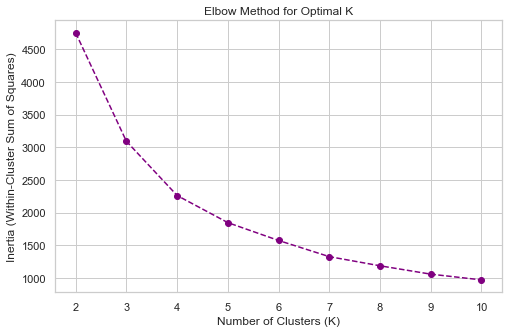

In [97]:

## ELBOW METHOD TO FIND OPTIMAL K


plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia_list, marker='o', linestyle='--', color='purple')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()

#### STEP 5 — Silhouette Score

In [98]:

## SILHOUETTE SCORES FOR K = 2 to 10

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clust_pca)
    silhouette_scores.append(silhouette_score(X_clust_pca, labels))

silhouette_scores

[0.34516662052326896,
 0.38015870267259566,
 0.375934726699889,
 0.37914505426728895,
 0.3722185048566229,
 0.3729836987330331,
 0.3706065278978006,
 0.3538964414144969,
 0.34916551809793506]

Interpretation:

Silhouette closer to 1.0 = clear, separated clusters

0.5–0.7 = acceptable

0.3–0.5 = overlapping clusters

< 0.3 = weak structure

#### STEP 6 — Fit Final K-Means Model

In [99]:

## FINAL K-MEANS MODEL (choose optimal K)

best_k = 4  # replace after analyzing elbow + silhouette

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_clust_pca)

# Add cluster labels to PCA DataFrame
cluster_df = pd.DataFrame({
    "PC1": X_clust_pca[:, 0],
    "PC2": X_clust_pca[:, 1],
    "Cluster": cluster_labels
})



#### STEP 7 — Plot Clusters in PCA Space

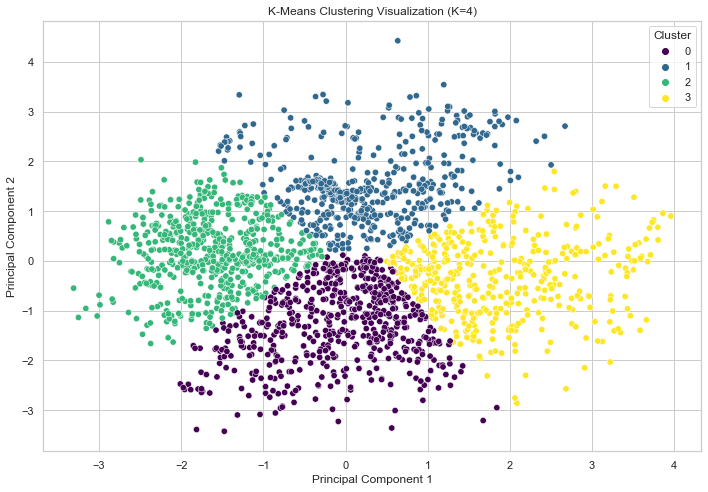

In [100]:
## VISUALIZE CLUSTERS

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=cluster_df,
    x="PC1", y="PC2",
    hue="Cluster",
    palette="viridis",
    s=40
)
plt.title(f"K-Means Clustering Visualization (K={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [101]:
## STEP — Compare Clusters to True Obesity Labels

cluster_vs_label = pd.crosstab(df_obesity["NObeyesdad"], cluster_labels)
cluster_vs_label

col_0,0,1,2,3
NObeyesdad,,,,
Insufficient_Weight,147,3,11,111
Normal_Weight,117,27,15,128
Obesity_Type_I,103,86,100,62
Obesity_Type_II,2,68,208,19
Obesity_Type_III,1,184,139,0
Overweight_Level_I,104,50,46,90
Overweight_Level_II,96,87,62,45


### INTERPRETATION OF EACH CLUSTER

***Cluster 0 — Mixed Low-to-Mid Obesity, Balanced Spread***

Dominant classes in C0:

Insufficient Weight (147)

Normal Weight (117)

Overweight Level I (104)

Overweight Level II (96)

Obesity Type I (103)

Pattern:

Cluster 0 contains individuals across nearly all categories except severe obesity.
This suggests:

- Moderate lifestyle profiles
- Balanced habits
- No extreme behaviors
- Physical measurements spread across low/mid BMI ranges

Cluster 0 represents a broad cluster of average lifestyle patterns, not tied to a specific obesity level.

***Cluster 1 — Severe Obesity Cluster (High Obesity II & III)***

Dominant classes in C1:

Obesity Type III (184)

Obesity Type II (68)

Obesity Type I (86)

This is clearly a high-severity cluster.

Pattern:

- Very high obesity levels
- Distinct physical characteristics (high weight, low activity, etc.)
- Lifestyle patterns strongly different from normal or low obesity groups

Cluster 1 represents a severely obese lifestyle/physical group.

***Cluster 2 — Mid-to-High Obesity Cluster (Obesity II Strong)***

Dominant classes in C2:

Obesity Type II (208)

Obesity Type III (139)

Obesity Type I (100)

This is another obesity-focused cluster, but different from Cluster 1.

Pattern:

- Highly obese but slightly more mixed than Cluster 1
- Potentially higher physical activity or different dietary cluster
- PCA likely separated Cluster 1 vs 2 on lifestyle factors, not weight alone

Cluster 2 represents a second obesity pattern, likely reflecting different habits among obese individuals (e.g., different food choices or exercise levels).

***Cluster 3 — Low-to-Mid Obesity with Strong Insufficient/Normal Weight Mix***

Dominant classes in C3:

Insufficient Weight (111)

Normal Weight (128)

Overweight Level I (90)

Pattern:

- Lower BMI range
- More physically active / healthier habits
- Likely different from Cluster 0 due to specific lifestyle differences

Cluster 3 appears to be the healthier lifestyle group, pulling away from overweight and obese populations.

### SUMMARY OF WHAT CLUSTERS REPRESENT
| Cluster | Interpretation                                                                  |
| ------- | ------------------------------------------------------------------------------- |
| **C0**  | Mixed group with average habits; includes all categories except severe obesity. |
| **C1**  | Severe Obesity Cluster (heaviest individuals).                                  |
| **C2**  | Mid-to-High Obesity Cluster (a different obesity pattern).                      |
| **C3**  | Healthier/Lower-weight group (Insufficient, Normal, Overweight I).              |


## Major Insight


Although the dataset contains seven obesity categories, the K-Means algorithm naturally groups individuals into four broader lifestyle and physical patterns:

1. C0 - Mixed Lifestyle Group – individuals with a wide range of obesity levels and moderate lifestyle characteristics.

2. C1 - Severe Obesity Group – individuals with the highest obesity levels, forming a distinct cluster.

3. C2 - High Obesity Group – another obesity-related cluster with a different pattern of behaviors and physical attributes.

4. C3 - Healthier / Lower-Weight Group – individuals with lower obesity levels and healthier lifestyle patterns.

These clusters reflect underlying behavioral and physical similarities, showing how unsupervised learning simplifies the seven obesity categories into broader natural groupings.

### CLUSTER PROFILING INTERPRETATION

In [102]:
## CLUSTER PROFILING TABLE


cluster_profile = df_obesity.copy()
cluster_profile["Cluster"] = cluster_labels

# For numerical columns:
cluster_means = cluster_profile.groupby("Cluster")[numerical_columns].mean()
cluster_means

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Cluster,,,,,,,,
0,20.471322,1.726387,72.850988,2.212353,2.912973,2.113080,1.456466,1.037678
1,30.945775,1.657272,93.453719,2.617519,2.623935,1.875586,0.478104,0.296998
2,24.950161,1.792943,113.100792,2.518896,2.906790,2.260463,1.276245,0.572693
3,20.948539,1.603468,62.313005,2.330182,2.186889,1.701003,0.702444,0.691340


In [103]:
cluster_cats = cluster_profile.groupby("Cluster")[categorical_columns].agg(lambda x: x.value_counts().index[0])
cluster_cats

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS
Cluster,,,,,,,,
0,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation
1,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation
2,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation
3,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation


Cluster Profiling Interpretation (Based on Numerical Means)

The cluster profiling table summarizes average values for physical attributes and lifestyle behaviors across the four clusters identified by K-Means. These averages offer meaningful insight into how individuals in each cluster differ in terms of age, weight, height, eating habits, physical activity, hydration, and technology usage.

### Cluster 0 — Mixed Lifestyle / Moderate Obesity Profile

#### Key characteristics:

Age: 20.47 (youngest group alongside Cluster 3)

Height: 1.726 m

Weight: 72.85 kg

Vegetable consumption (FCVC): 2.21

Meals per day (NCP): 2.91

Water intake (CH2O): 2.11

Physical activity (FAF): 1.46

Tech usage (TUE): 1.04

#### Interpretation:

Cluster 0 represents a mixed lifestyle group with moderate physical characteristics. Individuals tend to be young, moderately active, and maintain average eating habits. Their weight and BMI positioning show a wide range, explaining why multiple obesity categories appear in this cluster. This is the “general population” cluster.

### Cluster 1 — High-Obesity / Low-Activity Group

#### Key characteristics:

Age: 30.95 (oldest cluster)

Height: 1.657 m

Weight: 93.45 kg

Vegetable consumption: 2.62

Meals per day: 2.62

Water intake: 1.87

Physical activity: 0.48 (lowest among all clusters)

Tech usage: 0.29 (low engagement)

#### Interpretation:

Cluster 1 is a high-obesity, low-activity group, clearly aligned with Obesity Type III and Type II. Individuals in this cluster are older, shorter on average, and have significantly lower physical activity levels. Despite moderate dietary habits, the extremely low activity level and higher average weight define this group as a severe obesity cluster.

### Cluster 2 — Very High Obesity with Taller Height and Higher Fluid Intake

#### Key characteristics:

Age: 24.95

Height: 1.792 m (tallest group)

Weight: 113.10 kg (highest weight across all clusters)

Vegetable consumption: 2.52

Meals per day: 2.90

Water intake: 2.26 (highest)

Physical activity: 1.27

Tech usage: 0.57

#### Interpretation:

Cluster 2 represents another obesity-dominant group, but with different behavior from Cluster 1. These individuals are significantly taller and heavier, with higher hydration levels and slightly better physical activity patterns. The combination suggests a different lifestyle or metabolic profile among obese individuals, forming a distinct obesity subgroup separate from Cluster 1.

### Cluster 3 — Healthier / Lower-Weight Group

#### Key characteristics:

Age: 20.94 (young)

Height: 1.603 m (shortest)

Weight: 62.31 kg (lowest weight across all clusters)

Vegetable consumption: 2.33

Meals per day: 2.18

Water intake: 1.70

Physical activity: 0.70

Tech usage: 0.69

#### Interpretation:

Cluster 3 represents the healthier and lower-weight population, dominated by Insufficient Weight, Normal Weight, and Overweight Level I. These individuals tend to be younger, lighter, and maintain moderate physical activity. They also exhibit controlled meal frequency and reasonable water intake. This cluster reflects the stable, non-obese segment of the dataset.

### SUMMARY OF CLUSTER PROFILES

| Cluster       | Description           | Physical Profile               | Lifestyle Profile                                |
| ------------- | --------------------- | ------------------------------ | ------------------------------------------------ |
| **Cluster 0** | Mixed Lifestyle Group | Moderate weight & height       | Balanced habits, average activity                |
| **Cluster 1** | Severe Obesity Group  | High weight, shorter height    | Very low activity, lower hydration               |
| **Cluster 2** | High Obesity Group    | Tallest and heaviest           | Mixed diet, moderate activity, highest hydration |
| **Cluster 3** | Healthier Group       | Lowest weight, shortest height | Moderate habits, balanced lifestyle              |


### BAR GRAPH FOR CLUSTER PROFILES

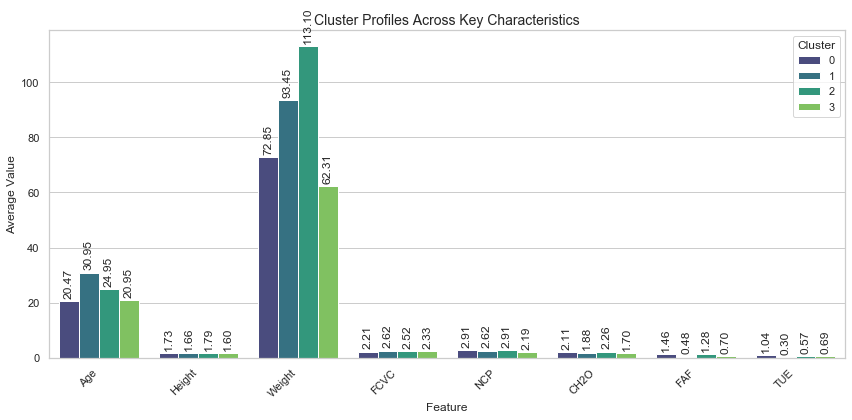

In [116]:
## BAR GRAPH: CLUSTER PROFILES ACROSS 8 CHARACTERISTICS


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the cluster_means table for plotting
cluster_profile_long = cluster_means.reset_index().melt(
    id_vars="Cluster",
    var_name="Feature",
    value_name="AverageValue"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=cluster_profile_long,
    x="Feature",
    y="AverageValue",
    hue="Cluster",
    palette="viridis"
)

plt.title("Cluster Profiles Across Key Characteristics", fontsize=14)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Average Value", fontsize=12)
plt.xticks(rotation=45, ha="right")

# ---------------------------------------------------------------
# Add value labels ON TOP OF EACH BAR, displayed VERTICALLY
# ---------------------------------------------------------------
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",                     # value with 2 decimals
        (p.get_x() + p.get_width() / 2., height+1),
        ha='center',
        va='bottom',
        fontsize=12,
        rotation=90                         # vertical text
    )

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## CONCLUSION



Objective:
The project successfully built and evaluated machine learning models to predict obesity levels using demographic, physical, dietary, and lifestyle features. Both supervised and unsupervised methods were applied to understand the predictive and structural patterns in the dataset.

Supervised Learning Results:
Random Forest achieved the highest classification performance, with 93.62% accuracy and a macro F1-score of 0.936. SVM performed similarly well, while Decision Tree showed strong interpretability with competitive accuracy. Logistic Regression and KNN served as effective baselines but struggled with classes that exhibited natural overlap, such as Normal Weight and Overweight Level I.

Model Strengths and Insights:
Strong-performing models showed clear discriminative ability, reflected in high ROC AUC scores. PCA visualizations indicated distinct separation for severe obesity classes and overlapping boundaries for moderate categories. Feature importance analysis emphasized the influence of weight, height, physical activity, and dietary behaviors on obesity classification.

Unsupervised Learning Findings:
K-Means clustering revealed four natural groups representing broader lifestyle and physical patterns rather than the seven defined obesity classes. These clusters included a healthier low-weight group, a mixed lifestyle group, and two obesity-oriented groups with differing behavior profiles.

Interpretation of Combined Results:
Supervised models provided accurate classification using labeled outcomes, while unsupervised clustering exposed underlying behavioral and physical patterns. Together, these approaches offered complementary insights into obesity prediction and lifestyle-driven grouping.

Practical Significance:
The study demonstrates that obesity prediction benefits from integrating behavioral and physical factors. Machine learning can assist in developing personalized health interventions and risk assessments.

Limitations:
The population in the dataset is limited to three Latin American countries, which may affect generalizability.

Future Work:
Further research could explore deep learning models, alternative clustering algorithms, cross-cultural datasets, and real-time behavioral tracking to enhance prediction accuracy and interpretability.